In [1]:
from __future__ import annotations

import os
import re
import json
import pickle
import hashlib
import datetime as dt
from pathlib import Path
from dataclasses import dataclass
from typing import Any, Optional, Callable

import numpy as np
import pandas as pd

from IPython.display import display

In [2]:
# ================================================================
# Clean analysis notebook: configuration
# ================================================================

RANDOM_SEED = 20260523
rng = np.random.default_rng(RANDOM_SEED)

# Set DIVERGE_PROJECT_ROOT if running from a different working directory.
PROJECT_ROOT = Path(os.environ.get("DIVERGE_PROJECT_ROOT", ".")).resolve()

# Input data are read from the same staged input location used by the old notebook.
INPUT_ROOT = Path(
    os.environ.get(
        "DIVERGE_INPUT_ROOT",
        PROJECT_ROOT / "final_analysis" / "input_data",
    )
).resolve()

# Fresh outputs go to a clean folder so we do not overwrite older exploratory files.
OUTPUT_ROOT = Path(
    os.environ.get(
        "DIVERGE_OUTPUT_ROOT",
        PROJECT_ROOT / "final_analysis_clean",
    )
).resolve()

CACHE_DIR = OUTPUT_ROOT / "cache"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIGURE_DIR = OUTPUT_ROOT / "figures"
MANIFEST_DIR = OUTPUT_ROOT / "manifests"

for d in [CACHE_DIR, TABLE_DIR, FIGURE_DIR, MANIFEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Core input paths.
EXPERIMENT_DATA_PATH = INPUT_ROOT / "experiment_data.pkl"

ORIGINAL_QUALITY_LONG_PATH = INPUT_ROOT / "original_quality_exports" / "quality_metrics_long.parquet"
if not ORIGINAL_QUALITY_LONG_PATH.exists():
    ORIGINAL_QUALITY_LONG_PATH = INPUT_ROOT / "quality_metrics_long.parquet"

FOLLOWUP_ROOT = INPUT_ROOT / "followup_new_baselines"

FOLLOWUP_OUTPUTS_PATH = (
    FOLLOWUP_ROOT / "r2_outputs" / "new_baseline_outputs_all_providers.parquet"
)

FOLLOWUP_AUT_QUALITY_PATH = (
    FOLLOWUP_ROOT / "quality" / "aut_claus_quality_rows_analysis_ready.pkl"
)

FOLLOWUP_STORY_QUALITY_PATH = (
    FOLLOWUP_ROOT / "quality" / "story_maoss_quality_rows_analysis_ready.pkl"
)

FOLLOWUP_SLOGAN_QUALITY_PATH = (
    FOLLOWUP_ROOT / "quality" / "slogan_lexical_quality_rows_analysis_ready.pkl"
)

SLOGAN_LLM_JUDGE_QUALITY_PATH = INPUT_ROOT / "slogan_llm_judge_quality_rows_analysis_ready.pkl"

REQUIRED_INPUTS = {
    "EXPERIMENT_DATA_PATH": EXPERIMENT_DATA_PATH,
    "ORIGINAL_QUALITY_LONG_PATH": ORIGINAL_QUALITY_LONG_PATH,
    "FOLLOWUP_OUTPUTS_PATH": FOLLOWUP_OUTPUTS_PATH,
    "FOLLOWUP_AUT_QUALITY_PATH": FOLLOWUP_AUT_QUALITY_PATH,
    "FOLLOWUP_STORY_QUALITY_PATH": FOLLOWUP_STORY_QUALITY_PATH,
    "FOLLOWUP_SLOGAN_QUALITY_PATH": FOLLOWUP_SLOGAN_QUALITY_PATH,
}

missing = {name: path for name, path in REQUIRED_INPUTS.items() if not path.exists()}
if missing:
    for name, path in missing.items():
        print(f"Missing {name}: {path}")
    raise FileNotFoundError("One or more required input files are missing.")

print("Input root:", INPUT_ROOT)
print("Output root:", OUTPUT_ROOT)
print("\nInput files found:")
for name, path in REQUIRED_INPUTS.items():
    print(f"  {name}: {path}")

Input root: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis/input_data
Output root: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean

Input files found:
  EXPERIMENT_DATA_PATH: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis/input_data/experiment_data.pkl
  ORIGINAL_QUALITY_LONG_PATH: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis/input_data/original_quality_exports/quality_metrics_long.parquet
  FOLLOWUP_OUTPUTS_PATH: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis/input_data/followup_new_baselines/r2_outputs/new_baseline_outputs_all_providers.parquet
  FOLLOWUP_AUT_QUALITY_PATH: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis/inpu

In [3]:
# ================================================================
# Experimental design
# ================================================================

PROVIDER_ORDER = ["openai", "anthropic", "gemini"]

PROVIDER_LABEL = {
    "openai": "GPT-5.4",
    "anthropic": "Claude Sonnet 4.6",
    "gemini": "Gemini 2.5 Pro",
}

TASK_FAMILY_ORDER = ["slogan", "aut", "story"]

TASK_FAMILY_LABEL = {
    "slogan": "Slogans",
    "aut": "Alternative uses",
    "story": "Stories",
}

TASK_FAMILY = {
    "slogan_smartphone": "slogan",
    "slogan_soda": "slogan",
    "slogan_blood_donation": "slogan",
    "aut_shoe": "aut",
    "aut_button": "aut",
    "aut_key": "aut",
    "aut_wooden_pencil": "aut",
    "aut_automobile_tire": "aut",
    "story_jungle": "story",
    "story_parachute": "story",
    "story_horror": "story",
    "story_life_last_seconds": "story",
}

TASK_LABEL = {
    "slogan_smartphone": "Smartphone slogan",
    "slogan_soda": "Soda slogan",
    "slogan_blood_donation": "Blood donation slogan",
    "aut_shoe": "AUT: shoe",
    "aut_button": "AUT: button",
    "aut_key": "AUT: key",
    "aut_wooden_pencil": "AUT: wooden pencil",
    "aut_automobile_tire": "AUT: automobile tire",
    "story_jungle": "Story: jungle",
    "story_parachute": "Story: parachute",
    "story_horror": "Story: horror",
    "story_life_last_seconds": "Story: life / last seconds",
}

TASK_ORDER = list(TASK_FAMILY.keys())

# Internal method identifiers retained from the old data.
METHOD_ORDER = [
    "one_shot",
    "self_rewrite_e0",
    "self_plus_1_peer",
    "self_plus_2_peers",
    "simplestrat5",
    "g2_css_static3",
]

# Paper-facing method identifiers.
METHOD_PAPER = {
    "one_shot": "indep",
    "self_rewrite_e0": "self",
    "self_plus_1_peer": "peer1",
    "self_plus_2_peers": "peer2",
    "simplestrat5": "strat",
    "g2_css_static3": "repr",
}

METHOD_LABEL = {
    "one_shot": "Independent generation",
    "self_rewrite_e0": "Self-anchored rewrite",
    "self_plus_1_peer": "Self + 1 peer anchor",
    "self_plus_2_peers": "Self + 2 peer anchors",
    "simplestrat5": "SimpleStrat-lite",
    "g2_css_static3": "Representative anti-anchor",
}

STRATEGY_ORDER = ["vanilla", "diverge"]

STRATEGY_PAPER = {
    "vanilla": "neutral",
    "diverge": "diverge",
}

STRATEGY_LABEL = {
    "vanilla": "Neutral",
    "diverge": "Diverge",
}

FOLLOWUP_EXPERIMENT_ID_BY_PROVIDER = {
    "openai": "openai_followup_simplestrat5_g2css3",
    "anthropic": "anthropic_followup_simplestrat5_g2css3",
    "gemini": "gemini_followup_simplestrat5_g2css3",
}

CELL_KEYS = ["provider", "task_family", "task_id", "method", "strategy"]

In [4]:
# Cell 4 — Small utilities

# ================================================================
# General helpers
# ================================================================

def now_iso() -> str:
    return dt.datetime.now(dt.timezone.utc).isoformat()


def stable_hash(text: Any, n: int = 24) -> str:
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()[:n]


def clean_text(text: Any) -> str:
    if pd.isna(text):
        return ""

    text = str(text).strip()

    # Remove accidental markdown fences.
    text = re.sub(r"^\s*```[a-zA-Z0-9_-]*\s*", "", text)
    text = re.sub(r"\s*```\s*$", "", text).strip()

    # Remove one layer of wrapping quotation marks.
    if len(text) >= 2 and (
        (text[0] == text[-1] == '"')
        or (text[0] == text[-1] == "'")
        or (text[0] == "“" and text[-1] == "”")
        or (text[0] == "‘" and text[-1] == "’")
    ):
        text = text[1:-1].strip()

    return re.sub(r"\s+", " ", text)


def nonempty_string_mask(series: pd.Series) -> np.ndarray:
    """
    True when a Series value is usable as a string value.

    This avoids pandas categorical fillna/where issues by operating on
    StringDtype and returning a plain NumPy boolean array.
    """
    s = series.astype("string")
    stripped = s.str.strip()

    mask = (
        s.notna()
        & stripped.ne("")
        & stripped.str.lower().ne("nan")
        & stripped.str.lower().ne("none")
        & stripped.str.lower().ne("<na>")
    )

    return mask.to_numpy(dtype=bool, na_value=False)


def coalesce_string(primary: pd.Series, fallback: pd.Series) -> pd.Series:
    """
    Return primary when it is a nonempty string; otherwise return fallback.

    Used instead of fillna(series), which can fail when primary is categorical.
    """
    p = primary.astype("string")
    f = fallback.astype("string")

    out = p.where(nonempty_string_mask(p), f)
    return out.astype("string").fillna("").astype(str)


def map_with_fallback(series: pd.Series, mapping: dict) -> pd.Series:
    """
    Safely map labels even when the input Series is categorical.

    Pandas can raise TypeError when fillna() combines categorical Series
    with non-identical categories. This helper converts to StringDtype first,
    maps labels, and falls back to the original value without categorical fillna.
    """
    s = series.astype("string")
    mapped = s.map(mapping).astype("string")

    out = mapped.where(nonempty_string_mask(mapped), s)
    return out.astype("string").fillna("").astype(str)


def normalize_strategy(x: Any) -> str:
    s = str(x).strip().lower()

    if s in {"neutral", "vanilla", "base", "control"}:
        return "vanilla"

    if s in {"diverge", "divergent", "diversity", "diverse"}:
        return "diverge"

    if "diverg" in s or "divers" in s:
        return "diverge"

    return s


def first_existing_col(df: pd.DataFrame, candidates: list[str]) -> Optional[str]:
    for c in candidates:
        if c in df.columns:
            return c
    return None


def read_table(path: Path) -> pd.DataFrame:
    if path.suffix == ".pkl":
        return pd.read_pickle(path)
    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    if path.suffix == ".csv":
        return pd.read_csv(path)
    raise ValueError(f"Unsupported file type: {path}")


def zscore_within_group(
    df: pd.DataFrame,
    value_col: str,
    group_col: str,
) -> pd.Series:
    out = pd.Series(np.nan, index=df.index, dtype=float)

    for _, g in df.groupby(group_col, observed=True):
        vals = pd.to_numeric(g[value_col], errors="coerce")
        mu = vals.mean()
        sd = vals.std(ddof=0)

        if not np.isfinite(sd) or sd <= 0:
            out.loc[g.index] = 0.0
        else:
            out.loc[g.index] = (vals - mu) / sd

    return out


def counts_table(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    return (
        df.groupby(group_cols, observed=True)
        .size()
        .reset_index(name="n")
        .sort_values(group_cols)
        .reset_index(drop=True)
    )


def save_json(path: Path, obj: dict) -> None:
    def safe(x):
        if isinstance(x, Path):
            return str(x)
        if isinstance(x, (np.integer,)):
            return int(x)
        if isinstance(x, (np.floating,)):
            v = float(x)
            return None if not np.isfinite(v) else v
        if isinstance(x, dict):
            return {str(k): safe(v) for k, v in x.items()}
        if isinstance(x, list):
            return [safe(v) for v in x]
        try:
            if pd.isna(x):
                return None
        except Exception:
            pass
        return x

    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(safe(obj), f, indent=2, ensure_ascii=False)


def original_method_from_round_condition(row: pd.Series) -> Optional[str]:
    """
    Map the original experiment's round/condition encoding to the six method IDs.

    Original experiment contains:
      round 1, base  -> one_shot
      round 2, base  -> self_rewrite_e0
      round 2, dyad  -> self_plus_1_peer
      round 2, triad -> self_plus_2_peers

    Follow-up files directly provide:
      simplestrat5
      g2_css_static3
    """
    try:
        r = int(float(row["round"]))
    except Exception:
        return None

    c = str(row.get("condition", "")).strip().lower()

    if r == 1 and c == "base":
        return "one_shot"
    if r == 2 and c == "base":
        return "self_rewrite_e0"
    if r == 2 and c == "dyad":
        return "self_plus_1_peer"
    if r == 2 and c == "triad":
        return "self_plus_2_peers"

    return None

In [5]:
# ================================================================
# Load original experiment object
# ================================================================

@dataclass
class ExperimentData:
    long_df: Optional[pd.DataFrame] = None
    embeddings: Optional[np.ndarray] = None


@dataclass
class ProviderExperimentData:
    long_df: Optional[pd.DataFrame] = None
    embeddings: Optional[np.ndarray] = None
    provider: Optional[str] = None
    provider_label: Optional[str] = None
    model: Optional[str] = None


class GenericPicklePlaceholder:
    def __init__(self, *args, **kwargs):
        self.__dict__.update(kwargs)

    def __setstate__(self, state):
        if isinstance(state, dict):
            self.__dict__.update(state)
        else:
            self.__dict__["state"] = state


class CompatibleUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "__main__":
            if name == "ExperimentData":
                return ExperimentData
            if name == "ProviderExperimentData":
                return ProviderExperimentData
            return GenericPicklePlaceholder
        return super().find_class(module, name)


def load_experiment_data(path: Path) -> ExperimentData:
    with open(path, "rb") as f:
        obj = CompatibleUnpickler(f).load()

    # Case 1: object directly contains long_df.
    if hasattr(obj, "long_df") and obj.long_df is not None:
        return obj

    # Case 2: object contains provider-specific objects.
    attrs = getattr(obj, "__dict__", {})
    provider_objects = []

    for val in attrs.values():
        if isinstance(val, dict):
            provider_objects.extend(
                v for v in val.values()
                if hasattr(v, "long_df") and v.long_df is not None
            )
        elif isinstance(val, (list, tuple)):
            provider_objects.extend(
                v for v in val
                if hasattr(v, "long_df") and v.long_df is not None
            )

    if provider_objects:
        long_df = pd.concat(
            [p.long_df for p in provider_objects],
            ignore_index=True,
            sort=False,
        )

        embeddings = None
        if all(hasattr(p, "embeddings") and p.embeddings is not None for p in provider_objects):
            embeddings = np.vstack([np.asarray(p.embeddings) for p in provider_objects])

        return ExperimentData(long_df=long_df, embeddings=embeddings)

    raise RuntimeError("Could not find usable long_df in experiment_data pickle.")


experiment_data = load_experiment_data(EXPERIMENT_DATA_PATH)

old_raw = experiment_data.long_df.copy()
old_raw["_old_row_pos"] = np.arange(len(old_raw))

TEXT_COL_OLD = first_existing_col(
    old_raw,
    ["text", "response_text", "output_text", "model_output", "clean_text", "idea", "response"],
)

if TEXT_COL_OLD is None:
    raise RuntimeError("Could not find text column in original experiment data.")

print("Original experiment rows:", old_raw.shape)
print("Original text column:", TEXT_COL_OLD)

display(old_raw.head())
display(counts_table(old_raw, ["provider", "round", "strategy", "condition"]))

Original experiment rows: (64800, 53)
Original text column: text


,provider,model,round,task_id,task_family,strategy,condition,group_id,agent_id,agent_index,...,usage_thoughts_token_count,usage_cached_content_token_count,usage_total_token_count,batch_name,word_count,rough_sentence_count,slogan_word_violation,story_sentence_flag,idea_region,_old_row_pos
0,openai,gpt-5.4,1,slogan_smartphone,slogan,vanilla,base,base_001,base_001__a1,1,...,NaN,NaN,NaN,NaN,5,1,False,False,4,0
1,openai,gpt-5.4,2,slogan_smartphone,slogan,vanilla,base,base_001,base_001__a1,1,...,NaN,NaN,NaN,NaN,4,1,False,False,16,1
2,openai,gpt-5.4,1,slogan_smartphone,slogan,vanilla,base,base_002,base_002__a1,1,...,NaN,NaN,NaN,NaN,5,1,False,False,4,2
3,openai,gpt-5.4,2,slogan_smartphone,slogan,vanilla,base,base_002,base_002__a1,1,...,NaN,NaN,NaN,NaN,3,1,False,False,8,3
4,openai,gpt-5.4,1,slogan_smartphone,slogan,vanilla,base,base_003,base_003__a1,1,...,NaN,NaN,NaN,NaN,4,1,False,False,10,4


,provider,round,strategy,condition,n
0,openai,1,vanilla,base,1800
1,openai,1,vanilla,dyad,1800
2,openai,1,vanilla,triad,1800
3,openai,1,diverge,base,1800
4,openai,1,diverge,dyad,1800
5,openai,1,diverge,triad,1800
6,openai,2,vanilla,base,1800
7,openai,2,vanilla,dyad,1800
8,openai,2,vanilla,triad,1800
9,openai,2,diverge,base,1800


In [6]:
# Cell 6 — Prepare original output rows

# ================================================================
# Prepare original output rows
# ================================================================

old = old_raw.copy()

required_original_cols = ["provider", "task_id", "strategy", "condition", "round"]
missing = [c for c in required_original_cols if c not in old.columns]
if missing:
    raise RuntimeError(f"Original data missing required columns: {missing}")

if "model" not in old.columns:
    old["model"] = old["provider"]

old["provider"] = old["provider"].astype("string").astype(str)
old["model"] = old["model"].astype("string").astype(str)
old["task_id"] = old["task_id"].astype("string").astype(str)

task_family_fallback = old["task_id"].map(TASK_FAMILY).astype("string")
if "task_family" in old.columns:
    old["task_family"] = coalesce_string(old["task_family"], task_family_fallback)
else:
    old["task_family"] = task_family_fallback.astype("string").fillna("").astype(str)

task_label_fallback = old["task_id"].map(TASK_LABEL).astype("string")
if "task_label" in old.columns:
    old["task_label"] = coalesce_string(old["task_label"], task_label_fallback)
else:
    old["task_label"] = task_label_fallback.astype("string").fillna("").astype(str)

old["strategy"] = old["strategy"].astype("string").map(normalize_strategy).astype(str)
old["condition"] = old["condition"].astype("string").astype(str)
old["method"] = old.apply(original_method_from_round_condition, axis=1)

# Ensure stable local identifiers exist.
for c in ["group_id", "agent_id", "agent_index"]:
    if c not in old.columns:
        old[c] = (
            old.groupby(
                ["provider", "task_id", "round", "strategy", "condition"],
                observed=True,
            )
            .cumcount()
            .astype(int)
        )

old = old[
    old["provider"].isin(PROVIDER_ORDER)
    & old["task_id"].isin(TASK_ORDER)
    & old["method"].isin(METHOD_ORDER)
    & old["strategy"].isin(STRATEGY_ORDER)
].copy()

old["source_stage"] = "original"
old["experiment_id"] = "original_experiment"

old["provider_label"] = map_with_fallback(old["provider"], PROVIDER_LABEL)
old["task_family_label"] = map_with_fallback(old["task_family"], TASK_FAMILY_LABEL)
old["task_label"] = map_with_fallback(old["task_id"], TASK_LABEL)
old["method_label"] = map_with_fallback(old["method"], METHOD_LABEL)
old["method_paper"] = map_with_fallback(old["method"], METHOD_PAPER)
old["strategy_label"] = map_with_fallback(old["strategy"], STRATEGY_LABEL)
old["strategy_paper"] = map_with_fallback(old["strategy"], STRATEGY_PAPER)

old["text_clean"] = old[TEXT_COL_OLD].map(clean_text)

if "request_key" not in old.columns:
    old["request_key"] = ""

generated_request_key = (
    old[
        [
            "source_stage",
            "provider",
            "model",
            "round",
            "task_id",
            "strategy",
            "condition",
            "group_id",
            "agent_id",
            "agent_index",
        ]
    ]
    .astype(str)
    .agg("|".join, axis=1)
    .map(lambda x: "original__" + stable_hash(x, 24))
    .astype("string")
)

old["request_key"] = (
    old["request_key"]
    .astype("string")
    .where(nonempty_string_mask(old["request_key"]), generated_request_key)
    .astype("string")
    .fillna("")
    .astype(str)
)

old["slot_num"] = (
    old.groupby(["provider", "task_id", "method", "strategy"], observed=True)
    .cumcount()
    .add(1)
    .astype(int)
)

old["slot_id"] = old["slot_num"].map(lambda x: f"slot_{x:03d}")

old["row_uid"] = old[
    [
        "source_stage",
        "provider",
        "model",
        "round",
        "task_id",
        "strategy",
        "condition",
        "group_id",
        "agent_id",
        "agent_index",
    ]
].astype(str).agg("|".join, axis=1).map(lambda x: stable_hash(x, 32))

print("Prepared original output rows:", old.shape)
display(counts_table(old, ["provider", "task_family", "method", "strategy"]))

Prepared original output rows: (43200, 63)


,provider,task_family,method,strategy,n
0,anthropic,aut,one_shot,diverge,750
1,anthropic,aut,one_shot,vanilla,750
2,anthropic,aut,self_plus_1_peer,diverge,750
3,anthropic,aut,self_plus_1_peer,vanilla,750
4,anthropic,aut,self_plus_2_peers,diverge,750
...,...,...,...,...,...
67,openai,story,self_plus_1_peer,vanilla,600
68,openai,story,self_plus_2_peers,diverge,600
69,openai,story,self_plus_2_peers,vanilla,600
70,openai,story,self_rewrite_e0,diverge,600


In [7]:
# Cell 7 — Prepare follow-up output rows

# ================================================================
# Prepare follow-up output rows: strat and repr
# ================================================================

followup_raw = read_table(FOLLOWUP_OUTPUTS_PATH).copy()
followup = followup_raw.copy()

TEXT_COL_FOLLOWUP = first_existing_col(
    followup,
    ["text", "response", "output_text", "model_output", "clean_text", "idea"],
)

if TEXT_COL_FOLLOWUP is None:
    raise RuntimeError("Could not find text column in follow-up outputs.")

required_followup_cols = ["provider", "task_id", "strategy"]
missing = [c for c in required_followup_cols if c not in followup.columns]
if missing:
    raise RuntimeError(f"Follow-up outputs missing required columns: {missing}")

if "model" not in followup.columns:
    followup["model"] = followup["provider"]

followup["provider"] = followup["provider"].astype("string").astype(str)
followup["model"] = followup["model"].astype("string").astype(str)
followup["task_id"] = followup["task_id"].astype("string").astype(str)

task_family_fallback = followup["task_id"].map(TASK_FAMILY).astype("string")
if "task_family" in followup.columns:
    followup["task_family"] = coalesce_string(followup["task_family"], task_family_fallback)
else:
    followup["task_family"] = task_family_fallback.astype("string").fillna("").astype(str)

task_label_fallback = followup["task_id"].map(TASK_LABEL).astype("string")
if "task_label" in followup.columns:
    followup["task_label"] = coalesce_string(followup["task_label"], task_label_fallback)
else:
    followup["task_label"] = task_label_fallback.astype("string").fillna("").astype(str)

if "method" not in followup.columns:
    if "condition" in followup.columns:
        followup["method"] = followup["condition"]
    else:
        raise RuntimeError("Follow-up outputs missing both method and condition columns.")

followup["method"] = followup["method"].astype("string").astype(str)
followup["strategy"] = followup["strategy"].astype("string").map(normalize_strategy).astype(str)

if "round" in followup.columns:
    followup["round"] = pd.to_numeric(followup["round"], errors="coerce").fillna(2).astype(int)
else:
    followup["round"] = 2

if "condition" in followup.columns:
    followup["condition"] = coalesce_string(followup["condition"], followup["method"])
else:
    followup["condition"] = followup["method"].astype("string").astype(str)

followup["source_stage"] = "followup"

if "experiment_id" not in followup.columns:
    followup["experiment_id"] = ""

experiment_id_fallback = followup["provider"].map(FOLLOWUP_EXPERIMENT_ID_BY_PROVIDER).astype("string")
followup["experiment_id"] = coalesce_string(followup["experiment_id"], experiment_id_fallback)

followup["provider_label"] = map_with_fallback(followup["provider"], PROVIDER_LABEL)
followup["task_family_label"] = map_with_fallback(followup["task_family"], TASK_FAMILY_LABEL)
followup["task_label"] = map_with_fallback(followup["task_id"], TASK_LABEL)
followup["method_label"] = map_with_fallback(followup["method"], METHOD_LABEL)
followup["method_paper"] = map_with_fallback(followup["method"], METHOD_PAPER)
followup["strategy_label"] = map_with_fallback(followup["strategy"], STRATEGY_LABEL)
followup["strategy_paper"] = map_with_fallback(followup["strategy"], STRATEGY_PAPER)

followup["text_clean"] = followup[TEXT_COL_FOLLOWUP].map(clean_text)

if "slot_id" not in followup.columns:
    followup["slot_num"] = (
        followup.groupby(["provider", "task_id", "method", "strategy"], observed=True)
        .cumcount()
        .add(1)
        .astype(int)
    )
    followup["slot_id"] = followup["slot_num"].map(lambda x: f"slot_{x:03d}")
else:
    followup["slot_id"] = followup["slot_id"].astype("string").astype(str)
    extracted_slot_num = pd.to_numeric(
        followup["slot_id"].str.extract(r"(\d+)")[0],
        errors="coerce",
    )
    fallback_slot_num = (
        followup.groupby(["provider", "task_id", "method", "strategy"], observed=True)
        .cumcount()
        .add(1)
    )
    followup["slot_num"] = extracted_slot_num.fillna(fallback_slot_num).astype(int)

if "request_key" not in followup.columns:
    followup["request_key"] = ""

generated_request_key = (
    followup[
        [
            "source_stage",
            "provider",
            "model",
            "experiment_id",
            "task_id",
            "method",
            "strategy",
            "slot_id",
        ]
    ]
    .astype(str)
    .agg("|".join, axis=1)
    .map(lambda x: "followup__" + stable_hash(x, 24))
    .astype("string")
)

followup["request_key"] = (
    followup["request_key"]
    .astype("string")
    .where(nonempty_string_mask(followup["request_key"]), generated_request_key)
    .astype("string")
    .fillna("")
    .astype(str)
)

followup = followup[
    followup["provider"].isin(PROVIDER_ORDER)
    & followup["task_id"].isin(TASK_ORDER)
    & followup["method"].isin(["simplestrat5", "g2_css_static3"])
    & followup["strategy"].isin(STRATEGY_ORDER)
].copy()

followup["row_uid"] = followup[
    [
        "source_stage",
        "provider",
        "model",
        "experiment_id",
        "task_id",
        "method",
        "strategy",
        "slot_id",
        "request_key",
    ]
].astype(str).agg("|".join, axis=1).map(lambda x: stable_hash(x, 32))

print("Prepared follow-up output rows:", followup.shape)
print("Follow-up text column:", TEXT_COL_FOLLOWUP)

display(counts_table(followup, ["provider", "task_family", "method", "strategy"]))

Prepared follow-up output rows: (21600, 64)
Follow-up text column: text


,provider,task_family,method,strategy,n
0,anthropic,aut,g2_css_static3,diverge,750
1,anthropic,aut,g2_css_static3,vanilla,750
2,anthropic,aut,simplestrat5,diverge,750
3,anthropic,aut,simplestrat5,vanilla,750
4,anthropic,slogan,g2_css_static3,diverge,450
5,anthropic,slogan,g2_css_static3,vanilla,450
6,anthropic,slogan,simplestrat5,diverge,450
7,anthropic,slogan,simplestrat5,vanilla,450
8,anthropic,story,g2_css_static3,diverge,600
9,anthropic,story,g2_css_static3,vanilla,600


In [8]:
# Cell 8 — Combine and validate output rows

# ================================================================
# Combine evaluated output rows
# ================================================================

COMMON_COLS = sorted(set(old.columns).union(followup.columns))

analysis_rows = pd.concat(
    [
        old.reindex(columns=COMMON_COLS),
        followup.reindex(columns=COMMON_COLS),
    ],
    ignore_index=True,
    sort=False,
)

analysis_rows["provider_label"] = map_with_fallback(analysis_rows["provider"], PROVIDER_LABEL)
analysis_rows["task_family_label"] = map_with_fallback(analysis_rows["task_family"], TASK_FAMILY_LABEL)
analysis_rows["task_label"] = map_with_fallback(analysis_rows["task_id"], TASK_LABEL)
analysis_rows["method_label"] = map_with_fallback(analysis_rows["method"], METHOD_LABEL)
analysis_rows["method_paper"] = map_with_fallback(analysis_rows["method"], METHOD_PAPER)
analysis_rows["strategy_label"] = map_with_fallback(analysis_rows["strategy"], STRATEGY_LABEL)
analysis_rows["strategy_paper"] = map_with_fallback(analysis_rows["strategy"], STRATEGY_PAPER)

analysis_rows["is_success"] = analysis_rows["text_clean"].astype("string").str.strip().ne("")
analysis_rows = analysis_rows[analysis_rows["is_success"]].copy().reset_index(drop=True)

if analysis_rows["row_uid"].duplicated().any():
    dupes = analysis_rows[analysis_rows["row_uid"].duplicated(keep=False)]
    display(
        dupes[
            ["row_uid", "source_stage", "provider", "task_id", "method", "strategy", "request_key"]
        ].head(100)
    )
    raise RuntimeError("Duplicate row_uid values.")

expected_output_rows = (
    len(PROVIDER_ORDER)
    * len(TASK_ORDER)
    * len(METHOD_ORDER)
    * len(STRATEGY_ORDER)
    * 150
)

print("Combined prepared output rows:", analysis_rows.shape)
print("Expected output rows:", expected_output_rows)

if len(analysis_rows) != expected_output_rows:
    display(counts_table(analysis_rows, ["provider", "task_family", "method", "strategy"]))
    raise RuntimeError("Unexpected number of prepared output rows.")

cell_counts = counts_table(analysis_rows, CELL_KEYS)
bad_cells = cell_counts[cell_counts["n"] != 150]

if not bad_cells.empty:
    display(bad_cells)
    raise RuntimeError("Some output cells do not contain exactly 150 rows.")

analysis_rows_path = TABLE_DIR / "prepared_analysis_rows_outputs_only.csv"
analysis_rows_pkl_path = TABLE_DIR / "prepared_analysis_rows_outputs_only.pkl"

analysis_rows.to_csv(analysis_rows_path, index=False)
analysis_rows.to_pickle(analysis_rows_pkl_path)

print("Saved:")
print(" ", analysis_rows_path)
print(" ", analysis_rows_pkl_path)

display(counts_table(analysis_rows, ["source_stage", "provider", "task_family", "method", "strategy"]))

/var/folders/rj/l30_wb7d3w7_tbx4gbz6lzzh0000gn/T/ipykernel_80881/1017347729.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  analysis_rows = pd.concat(


Combined prepared output rows: (64800, 84)
Expected output rows: 64800
Saved:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/prepared_analysis_rows_outputs_only.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/prepared_analysis_rows_outputs_only.pkl


,source_stage,provider,task_family,method,strategy,n
0,followup,anthropic,aut,g2_css_static3,diverge,750
1,followup,anthropic,aut,g2_css_static3,vanilla,750
2,followup,anthropic,aut,simplestrat5,diverge,750
3,followup,anthropic,aut,simplestrat5,vanilla,750
4,followup,anthropic,slogan,g2_css_static3,diverge,450
...,...,...,...,...,...,...
103,original,openai,story,self_plus_1_peer,vanilla,600
104,original,openai,story,self_plus_2_peers,diverge,600
105,original,openai,story,self_plus_2_peers,vanilla,600
106,original,openai,story,self_rewrite_e0,diverge,600


In [9]:
# Cell 9 — Quality-metric interface

# ================================================================
# Quality metric interface
# ================================================================

@dataclass(frozen=True)
class QualitySpec:
    """
    Defines how one task family's quality scores enter the analysis.

    Downstream cells only assume the standardized output columns:
      provider, task_id, task_family, method, strategy,
      quality_raw, quality_metric, quality_source
    """
    task_family: str
    metric_name: str
    source_label: str


# Current manuscript proxies.
# Later replacement idea:
#   replace any or all of these with LLM-as-a-judge scores, but keep the
#   standardized columns produced by build_quality_rows().
CURRENT_QUALITY_SPECS = {
    "aut": QualitySpec(
        task_family="aut",
        metric_name="claus_prediction",
        source_label="claus",
    ),
    "story": QualitySpec(
        task_family="story",
        metric_name="maoss_prediction",
        source_label="maoss",
    ),
    "slogan": QualitySpec(
        task_family="slogan",
        metric_name="slogan_lexical_non_template_z_task",
        source_label="slogan_lexical_non_template",
    ),
}

QUALITY_SPECS = CURRENT_QUALITY_SPECS


def standardize_quality_rows(q: pd.DataFrame) -> pd.DataFrame:
    """
    Normalize quality rows to the single schema consumed downstream.

    Required output columns:
      provider, task_id, task_family, method, strategy,
      quality_raw, quality_source, quality_metric
    """
    required = [
        "provider",
        "task_id",
        "task_family",
        "method",
        "strategy",
        "quality_raw",
        "quality_source",
        "quality_metric",
    ]
    missing = [c for c in required if c not in q.columns]
    if missing:
        raise RuntimeError(f"Quality table missing standardized columns: {missing}")

    out = q[required].copy()

    for c in ["provider", "task_id", "task_family", "method", "strategy"]:
        out[c] = out[c].astype("string").astype(str)

    out["strategy"] = out["strategy"].astype("string").map(normalize_strategy).astype(str)
    out["quality_raw"] = pd.to_numeric(out["quality_raw"], errors="coerce")

    out = out.dropna(subset=["quality_raw"]).copy()

    out = out[
        out["provider"].isin(PROVIDER_ORDER)
        & out["task_id"].isin(TASK_ORDER)
        & out["task_family"].isin(TASK_FAMILY_ORDER)
        & out["method"].isin(METHOD_ORDER)
        & out["strategy"].isin(STRATEGY_ORDER)
    ].copy()

    return out.reset_index(drop=True)


def add_quality_labels_and_zscores(q: pd.DataFrame) -> pd.DataFrame:
    q = q.copy()

    # IMPORTANT: task-level standardization keeps current manuscript behavior.
    # If judge scores are later calibrated globally, this is the line to revisit.
    q["quality_z_task"] = zscore_within_group(
        q,
        value_col="quality_raw",
        group_col="task_id",
    )

    q["provider_label"] = map_with_fallback(q["provider"], PROVIDER_LABEL)
    q["task_family_label"] = map_with_fallback(q["task_family"], TASK_FAMILY_LABEL)
    q["task_label"] = map_with_fallback(q["task_id"], TASK_LABEL)
    q["method_label"] = map_with_fallback(q["method"], METHOD_LABEL)
    q["method_paper"] = map_with_fallback(q["method"], METHOD_PAPER)
    q["strategy_label"] = map_with_fallback(q["strategy"], STRATEGY_LABEL)
    q["strategy_paper"] = map_with_fallback(q["strategy"], STRATEGY_PAPER)

    return q

In [14]:
# Cell 10 — Load quality rows with slogan LLM-judge scores

# ================================================================
# Load quality metrics
#   AUT     : CLAUS
#   Stories : MAoSS
#   Slogans : LLM-as-a-judge creativity score
# ================================================================
# This cell assumes the slogan judge notebook has staged:
#   final_analysis/input_data/slogan_llm_judge_quality_rows_analysis_ready.pkl
#
# If that file is present, slogan quality comes entirely from it.
# We do NOT also load the old lexical slogan proxy, to avoid duplicated
# or mixed slogan quality rows.

SLOGAN_LLM_JUDGE_QUALITY_PATH = INPUT_ROOT / "slogan_llm_judge_quality_rows_analysis_ready.pkl"

if not SLOGAN_LLM_JUDGE_QUALITY_PATH.exists():
    fallback_slogan_judge_path = (
        INPUT_ROOT
        / "followup_new_baselines"
        / "quality"
        / "slogan_llm_judge_quality_rows_analysis_ready.pkl"
    )

    if fallback_slogan_judge_path.exists():
        SLOGAN_LLM_JUDGE_QUALITY_PATH = fallback_slogan_judge_path


def load_original_quality_rows_aut_story_only(
    path: Path,
    specs: dict[str, QualitySpec],
) -> pd.DataFrame:
    """
    Load original-experiment quality rows for AUT and stories only.

    Slogans are intentionally excluded because they are now supplied by the
    staged LLM-judge file for both original and follow-up methods.
    """
    q_raw = pd.read_parquet(path).copy()

    print("Original quality raw shape:", q_raw.shape)
    display(counts_table(q_raw, ["task_family", "quality_metric"]))

    if "quality_value" in q_raw.columns:
        q_raw["quality_raw"] = pd.to_numeric(q_raw["quality_value"], errors="coerce")
        q_raw["quality_raw_col"] = "quality_value"
    elif "quality_score_raw" in q_raw.columns:
        q_raw["quality_raw"] = pd.to_numeric(q_raw["quality_score_raw"], errors="coerce")
        q_raw["quality_raw_col"] = "quality_score_raw"
    else:
        raise RuntimeError("Original quality file has neither quality_value nor quality_score_raw.")

    if "quality_source" not in q_raw.columns:
        q_raw["quality_source"] = "original_quality_file"

    selected = []

    for family in ["aut", "story"]:
        if family not in specs:
            raise RuntimeError(f"QUALITY_SPECS is missing required family: {family}")

        spec = specs[family]

        h = q_raw[
            q_raw["task_family"].astype(str).eq(family)
            & q_raw["quality_metric"].astype(str).eq(spec.metric_name)
        ].copy()

        print(f"Selected original {family}: {spec.metric_name}; rows={len(h)}")

        if h.empty:
            raise RuntimeError(f"No original quality rows for {family}/{spec.metric_name}")

        h["method"] = h.apply(original_method_from_round_condition, axis=1)
        h["strategy"] = h["strategy"].map(normalize_strategy)
        h["quality_source"] = f"original_{spec.source_label}"

        selected.append(h)

    q = pd.concat(selected, ignore_index=True, sort=False)

    return standardize_quality_rows(
        q[
            [
                "provider",
                "task_id",
                "task_family",
                "method",
                "strategy",
                "quality_raw",
                "quality_source",
                "quality_metric",
            ]
        ]
    )


def load_followup_quality_rows_aut_story_only() -> pd.DataFrame:
    """
    Load follow-up quality rows for AUT and stories only.

    Slogans are intentionally excluded because the staged LLM-judge file
    contains all slogan cells, including simplestrat5 and g2_css_static3.
    """
    parts = []

    # AUT: CLAUS
    aut_q = pd.read_pickle(FOLLOWUP_AUT_QUALITY_PATH).copy()

    if "cap_returned__prediction" not in aut_q.columns:
        raise RuntimeError("AUT follow-up quality missing cap_returned__prediction.")

    aut_q["task_family"] = "aut"
    aut_q["quality_raw"] = pd.to_numeric(aut_q["cap_returned__prediction"], errors="coerce")
    aut_q["quality_source"] = "followup_claus_returned"
    aut_q["quality_metric"] = "claus_prediction"

    parts.append(aut_q)

    # Stories: MAoSS
    story_q = pd.read_pickle(FOLLOWUP_STORY_QUALITY_PATH).copy()

    if "cap_returned__prediction" not in story_q.columns:
        raise RuntimeError("Story follow-up quality missing cap_returned__prediction.")

    story_q["task_family"] = "story"
    story_q["quality_raw"] = pd.to_numeric(story_q["cap_returned__prediction"], errors="coerce")
    story_q["quality_source"] = "followup_maoss_returned"
    story_q["quality_metric"] = "maoss_prediction"

    parts.append(story_q)

    q = pd.concat(parts, ignore_index=True, sort=False)

    return standardize_quality_rows(
        q[
            [
                "provider",
                "task_id",
                "task_family",
                "method",
                "strategy",
                "quality_raw",
                "quality_source",
                "quality_metric",
            ]
        ]
    )


def load_slogan_llm_judge_quality_rows(path: Path) -> pd.DataFrame:
    """
    Load staged slogan LLM-judge quality rows.

    Expected schema from the slogan judge notebook:
      provider, task_id, task_family, method, strategy, quality_raw,
      quality_metric, quality_source

    The staged file should contain all slogan outputs:
      3 providers × 3 slogan prompts × 6 methods × 2 strategies × 150 = 16,200.
    """
    if not path.exists():
        raise FileNotFoundError(
            "Slogan LLM-judge quality file not found. Expected one of:\n"
            f"  {INPUT_ROOT / 'slogan_llm_judge_quality_rows_analysis_ready.pkl'}\n"
            f"  {INPUT_ROOT / 'followup_new_baselines' / 'quality' / 'slogan_llm_judge_quality_rows_analysis_ready.pkl'}"
        )

    q = read_table(path).copy()

    print("Loaded slogan LLM-judge quality rows:")
    print(" ", path)
    print("Raw shape:", q.shape)

    required = [
        "provider",
        "task_id",
        "task_family",
        "method",
        "strategy",
        "quality_raw",
    ]

    missing = [c for c in required if c not in q.columns]
    if missing:
        raise RuntimeError(f"Slogan judge quality file missing required columns: {missing}")

    q["provider"] = q["provider"].astype("string").astype(str)
    q["task_id"] = q["task_id"].astype("string").astype(str)
    q["task_family"] = q["task_family"].astype("string").astype(str)
    q["method"] = q["method"].astype("string").astype(str)
    q["strategy"] = q["strategy"].astype("string").map(normalize_strategy).astype(str)
    q["quality_raw"] = pd.to_numeric(q["quality_raw"], errors="coerce")

    # Enforce slogan-only rows.
    q = q[
        q["task_family"].eq("slogan")
        & q["task_id"].isin([t for t, f in TASK_FAMILY.items() if f == "slogan"])
    ].copy()

    if "quality_source" not in q.columns:
        q["quality_source"] = "slogan_llm_judge_gpt54"

    if "quality_metric" not in q.columns:
        q["quality_metric"] = "slogan_llm_judge_gpt54_creativity_1to5"

    q["quality_source"] = q["quality_source"].astype("string").fillna("slogan_llm_judge_gpt54").astype(str)
    q["quality_metric"] = q["quality_metric"].astype("string").fillna("slogan_llm_judge_gpt54_creativity_1to5").astype(str)

    out = standardize_quality_rows(
        q[
            [
                "provider",
                "task_id",
                "task_family",
                "method",
                "strategy",
                "quality_raw",
                "quality_source",
                "quality_metric",
            ]
        ]
    )

    expected_slogan_rows = (
        len(PROVIDER_ORDER)
        * 3
        * len(METHOD_ORDER)
        * len(STRATEGY_ORDER)
        * 150
    )

    if len(out) != expected_slogan_rows:
        display(counts_table(out, ["provider", "task_id", "method", "strategy"]))
        raise RuntimeError(
            f"Expected {expected_slogan_rows:,} slogan judge rows, got {len(out):,}."
        )

    slogan_counts = counts_table(out, ["provider", "task_id", "method", "strategy"])
    bad = slogan_counts[slogan_counts["n"] != 150]

    if not bad.empty:
        display(bad)
        raise RuntimeError("Some slogan judge cells do not have exactly 150 rows.")

    if out["quality_raw"].isna().any():
        display(out[out["quality_raw"].isna()].head(100))
        raise RuntimeError("Slogan judge quality_raw contains missing values.")

    display(
        out
        .groupby(["provider", "method", "strategy"], observed=True)
        .agg(
            n=("quality_raw", "size"),
            mean_quality_raw=("quality_raw", "mean"),
            sd_quality_raw=("quality_raw", "std"),
        )
        .reset_index()
        .sort_values(["provider", "method", "strategy"])
    )

    return out


def build_quality_rows() -> pd.DataFrame:
    """
    Current version:
      AUT     : CLAUS
      Stories : MAoSS
      Slogans : staged LLM-as-a-judge score

    Downstream cells should remain unchanged. They consume:
      quality_raw -> task-standardized quality_z_task -> quality_mean.
    """
    original_quality_aut_story = load_original_quality_rows_aut_story_only(
        ORIGINAL_QUALITY_LONG_PATH,
        QUALITY_SPECS,
    )

    followup_quality_aut_story = load_followup_quality_rows_aut_story_only()

    slogan_judge_quality = load_slogan_llm_judge_quality_rows(
        SLOGAN_LLM_JUDGE_QUALITY_PATH
    )

    q = pd.concat(
        [
            original_quality_aut_story,
            followup_quality_aut_story,
            slogan_judge_quality,
        ],
        ignore_index=True,
        sort=False,
    )

    q = add_quality_labels_and_zscores(q)

    return q.reset_index(drop=True)


quality_rows = build_quality_rows()

print("Prepared unified quality rows:", quality_rows.shape)

display(
    counts_table(
        quality_rows,
        ["quality_source", "provider", "task_family", "method", "strategy"],
    )
)

expected_quality_rows = (
    len(PROVIDER_ORDER)
    * len(TASK_ORDER)
    * len(METHOD_ORDER)
    * len(STRATEGY_ORDER)
    * 150
)

if len(quality_rows) != expected_quality_rows:
    display(counts_table(quality_rows, ["provider", "task_family", "method", "strategy"]))
    raise RuntimeError(
        f"Unexpected number of quality rows: {len(quality_rows):,} != {expected_quality_rows:,}"
    )

quality_cell_check = counts_table(
    quality_rows,
    ["provider", "task_id", "task_family", "method", "strategy"],
)

bad_quality_cell_check = quality_cell_check[quality_cell_check["n"] != 150]

if not bad_quality_cell_check.empty:
    display(bad_quality_cell_check)
    raise RuntimeError("Some quality cells do not contain exactly 150 rows.")

print("Quality loader complete.")
print("Slogan quality source path:", SLOGAN_LLM_JUDGE_QUALITY_PATH)

Original quality raw shape: (97200, 37)


,task_family,quality_metric,n
0,aut,claus_prediction,27000
1,slogan,slogan_fit_margin_vs_other_tasks,16200
2,slogan,slogan_lexical_non_template_z_task,16200
3,slogan,slogan_viable,16200
4,story,maoss_prediction,21600


Selected original aut: claus_prediction; rows=27000
Selected original story: maoss_prediction; rows=21600
Loaded slogan LLM-judge quality rows:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis/input_data/slogan_llm_judge_quality_rows_analysis_ready.pkl
Raw shape: (16200, 27)


,provider,method,strategy,n,mean_quality_raw,sd_quality_raw
0,anthropic,g2_css_static3,diverge,450,3.966667,0.500556
1,anthropic,g2_css_static3,vanilla,450,3.904444,0.501426
2,anthropic,one_shot,diverge,450,4.177778,0.494463
3,anthropic,one_shot,vanilla,450,4.082222,0.512555
4,anthropic,self_plus_1_peer,diverge,450,4.017778,0.442351
5,anthropic,self_plus_1_peer,vanilla,450,3.980000,0.444767
6,anthropic,self_plus_2_peers,diverge,450,4.082222,0.537995
7,anthropic,self_plus_2_peers,vanilla,450,4.031111,0.516033
8,anthropic,self_rewrite_e0,diverge,450,4.004444,0.503863
9,anthropic,self_rewrite_e0,vanilla,450,4.057778,0.433810


Prepared unified quality rows: (64800, 16)


,quality_source,provider,task_family,method,strategy,n
0,followup_claus_returned,anthropic,aut,g2_css_static3,diverge,750
1,followup_claus_returned,anthropic,aut,g2_css_static3,vanilla,750
2,followup_claus_returned,anthropic,aut,simplestrat5,diverge,750
3,followup_claus_returned,anthropic,aut,simplestrat5,vanilla,750
4,followup_claus_returned,gemini,aut,g2_css_static3,diverge,750
...,...,...,...,...,...,...
103,slogan_llm_judge_gpt54,openai,slogan,self_plus_2_peers,vanilla,450
104,slogan_llm_judge_gpt54,openai,slogan,self_rewrite_e0,diverge,450
105,slogan_llm_judge_gpt54,openai,slogan,self_rewrite_e0,vanilla,450
106,slogan_llm_judge_gpt54,openai,slogan,simplestrat5,diverge,450


Quality loader complete.
Slogan quality source path: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis/input_data/slogan_llm_judge_quality_rows_analysis_ready.pkl


In [15]:
# Cell 11 — Aggregate quality to cells and save prepared artifacts

# ================================================================
# Aggregate quality rows to analysis cells
# ================================================================

quality_cell_values = (
    quality_rows.groupby(CELL_KEYS, observed=True)
    .agg(
        quality_mean=("quality_z_task", "mean"),
        quality_raw_mean=("quality_raw", "mean"),
        quality_sd=("quality_z_task", "std"),
        quality_n=("quality_z_task", "count"),
        quality_source=("quality_source", lambda x: ";".join(sorted(set(map(str, x))))),
        quality_metric=("quality_metric", lambda x: ";".join(sorted(set(map(str, x))))),
    )
    .reset_index()
)

quality_cell_values["provider_label"] = map_with_fallback(quality_cell_values["provider"], PROVIDER_LABEL)
quality_cell_values["task_family_label"] = map_with_fallback(quality_cell_values["task_family"], TASK_FAMILY_LABEL)
quality_cell_values["task_label"] = map_with_fallback(quality_cell_values["task_id"], TASK_LABEL)
quality_cell_values["method_label"] = map_with_fallback(quality_cell_values["method"], METHOD_LABEL)
quality_cell_values["method_paper"] = map_with_fallback(quality_cell_values["method"], METHOD_PAPER)
quality_cell_values["strategy_label"] = map_with_fallback(quality_cell_values["strategy"], STRATEGY_LABEL)
quality_cell_values["strategy_paper"] = map_with_fallback(quality_cell_values["strategy"], STRATEGY_PAPER)

print("Quality cell table:", quality_cell_values.shape)

bad_quality_cells = quality_cell_values[quality_cell_values["quality_n"] != 150].copy()
if not bad_quality_cells.empty:
    display(bad_quality_cells.head(100))
    raise RuntimeError("Some quality cells do not have exactly 150 scored rows.")

expected_quality_cells = (
    len(PROVIDER_ORDER)
    * len(TASK_ORDER)
    * len(METHOD_ORDER)
    * len(STRATEGY_ORDER)
)

if len(quality_cell_values) != expected_quality_cells:
    display(counts_table(quality_cell_values, ["provider", "task_family", "method", "strategy"]))
    raise RuntimeError("Unexpected number of quality cells.")

quality_rows_path = TABLE_DIR / "prepared_quality_rows.csv"
quality_cell_values_path = TABLE_DIR / "prepared_quality_cell_values.csv"

quality_rows.to_csv(quality_rows_path, index=False)
quality_cell_values.to_csv(quality_cell_values_path, index=False)

prepared_manifest = {
    "created_at_utc": now_iso(),
    "random_seed": RANDOM_SEED,
    "inputs": {
        "experiment_data_path": EXPERIMENT_DATA_PATH,
        "original_quality_long_path": ORIGINAL_QUALITY_LONG_PATH,
        "followup_outputs_path": FOLLOWUP_OUTPUTS_PATH,
        "followup_aut_quality_path": FOLLOWUP_AUT_QUALITY_PATH,
        "followup_story_quality_path": FOLLOWUP_STORY_QUALITY_PATH,
        "followup_slogan_quality_path": FOLLOWUP_SLOGAN_QUALITY_PATH,
    },
    "outputs": {
        "analysis_rows_csv": analysis_rows_path,
        "analysis_rows_pkl": analysis_rows_pkl_path,
        "quality_rows_csv": quality_rows_path,
        "quality_cell_values_csv": quality_cell_values_path,
    },
    "design": {
        "providers": PROVIDER_ORDER,
        "task_order": TASK_ORDER,
        "method_order": METHOD_ORDER,
        "strategy_order": STRATEGY_ORDER,
        "expected_output_rows": expected_output_rows,
        "expected_quality_cells": expected_quality_cells,
    },
    "quality_boundary": {
        "note": "Downstream cells should consume quality_mean from prepared_quality_cell_values.csv. To replace quality with LLM-as-a-judge, edit build_quality_rows() so it returns the same standardized schema.",
        "current_specs": {
            k: {
                "task_family": v.task_family,
                "metric_name": v.metric_name,
                "source_label": v.source_label,
            }
            for k, v in QUALITY_SPECS.items()
        },
    },
}

prepared_manifest_path = MANIFEST_DIR / "prepared_data_manifest.json"
save_json(prepared_manifest_path, prepared_manifest)

print("Prepared data complete.")
print("Manifest:", prepared_manifest_path)
print("Analysis rows:", analysis_rows_pkl_path)
print("Quality rows:", quality_rows_path)
print("Quality cell values:", quality_cell_values_path)

display(quality_cell_values.head())

Quality cell table: (432, 18)
Prepared data complete.
Manifest: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/manifests/prepared_data_manifest.json
Analysis rows: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/prepared_analysis_rows_outputs_only.pkl
Quality rows: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/prepared_quality_rows.csv
Quality cell values: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/prepared_quality_cell_values.csv


,provider,task_family,task_id,method,strategy,quality_mean,quality_raw_mean,quality_sd,quality_n,quality_source,quality_metric,provider_label,task_family_label,task_label,method_label,method_paper,strategy_label,strategy_paper
0,anthropic,aut,aut_automobile_tire,g2_css_static3,diverge,0.625126,0.684200,0.699998,150,followup_claus_returned,claus_prediction,Claude Sonnet 4.6,Alternative uses,AUT: automobile tire,Representative anti-anchor,repr,Diverge,diverge
1,anthropic,aut,aut_automobile_tire,g2_css_static3,vanilla,0.276037,0.665333,0.610734,150,followup_claus_returned,claus_prediction,Claude Sonnet 4.6,Alternative uses,AUT: automobile tire,Representative anti-anchor,repr,Neutral,neutral
2,anthropic,aut,aut_automobile_tire,one_shot,diverge,-0.042214,0.648133,0.797901,150,original_claus,claus_prediction,Claude Sonnet 4.6,Alternative uses,AUT: automobile tire,Independent generation,indep,Diverge,diverge
3,anthropic,aut,aut_automobile_tire,one_shot,vanilla,-1.116620,0.590067,0.684137,150,original_claus,claus_prediction,Claude Sonnet 4.6,Alternative uses,AUT: automobile tire,Independent generation,indep,Neutral,neutral
4,anthropic,aut,aut_automobile_tire,self_plus_1_peer,diverge,0.522743,0.678667,0.767451,150,original_claus,claus_prediction,Claude Sonnet 4.6,Alternative uses,AUT: automobile tire,Self + 1 peer anchor,peer1,Diverge,diverge


In [16]:
# Cell 12 — Analysis imports and metric configuration

# ================================================================
# Full-pool diversity / quality analysis setup
# ================================================================

from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.cluster import KMeans
from tqdm.auto import tqdm

# Keep this here too so this analysis block is self-documenting.
PRIMARY_DIVERSITY_METRIC = "semantic_pairwise_distance"
PRIMARY_QUALITY_METRIC = "quality_mean"

DIVERSITY_METRICS = [
    "semantic_pairwise_distance",
    "nearest_neighbor_distance",
    "medoid_sparseness",
    "mst_dispersion",
    "region_entropy",
]

ALL_CELL_METRICS = DIVERSITY_METRICS + [PRIMARY_QUALITY_METRIC]

# For observed noninferiority flags only. Bootstrap-based flags come later.
QUALITY_NONINFERIORITY_MARGIN = -0.10

# Fixed prompt-level semantic-region counts.
# These are used both for KMeans and for fixed-denominator entropy.
REGION_K_BY_FAMILY = {
    "slogan": 12,
    "aut": 15,
    "story": 12,
}

required_loaded_objects = [
    "analysis_rows",
    "quality_rows",
    "quality_cell_values",
    "CACHE_DIR",
    "TABLE_DIR",
    "FIGURE_DIR",
    "MANIFEST_DIR",
    "TASK_FAMILY",
    "TASK_FAMILY_LABEL",
    "TASK_LABEL",
    "PROVIDER_LABEL",
    "METHOD_LABEL",
    "METHOD_PAPER",
    "STRATEGY_LABEL",
    "STRATEGY_PAPER",
    "METHOD_ORDER",
    "PROVIDER_ORDER",
    "STRATEGY_ORDER",
    "CELL_KEYS",
]

missing_objects = [x for x in required_loaded_objects if x not in globals()]
if missing_objects:
    raise RuntimeError(f"Missing expected loaded objects: {missing_objects}")

for d in [CACHE_DIR, TABLE_DIR, FIGURE_DIR, MANIFEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Loaded objects are available.")
print("analysis_rows:", analysis_rows.shape)
print("quality_rows:", quality_rows.shape)
print("quality_cell_values:", quality_cell_values.shape)

Loaded objects are available.
analysis_rows: (64800, 84)
quality_rows: (64800, 16)
quality_cell_values: (432, 18)


In [18]:
# Cell 13 — Compute or load embeddings

# ================================================================
# Sentence embeddings for generated outputs
# ================================================================

def safe_slug(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text


EMBEDDING_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
EMBEDDING_MODEL_SLUG = safe_slug(EMBEDDING_MODEL_NAME)

EMBEDDING_CACHE = CACHE_DIR / f"combined_embeddings_{EMBEDDING_MODEL_SLUG}.npy"
EMBEDDING_INDEX_CACHE = CACHE_DIR / f"combined_embedding_index_{EMBEDDING_MODEL_SLUG}.csv"

FORCE_RECOMPUTE_EMBEDDINGS = False

if "row_uid" not in analysis_rows.columns:
    raise RuntimeError("analysis_rows is missing row_uid.")

if "text_clean" not in analysis_rows.columns:
    raise RuntimeError("analysis_rows is missing text_clean.")

if analysis_rows["row_uid"].duplicated().any():
    dupes = analysis_rows[analysis_rows["row_uid"].duplicated(keep=False)]
    display(
        dupes[
            ["row_uid", "source_stage", "provider", "task_id", "method", "strategy"]
        ].head(100)
    )
    raise RuntimeError("Duplicate row_uid values.")


def cached_embeddings_match(index_path: Path, rows: pd.DataFrame) -> bool:
    if not index_path.exists():
        return False

    try:
        idx = pd.read_csv(index_path)
    except Exception:
        return False

    if "row_uid" not in idx.columns:
        return False

    return set(idx["row_uid"].astype(str)) == set(rows["row_uid"].astype(str))


if (
    not FORCE_RECOMPUTE_EMBEDDINGS
    and EMBEDDING_CACHE.exists()
    and EMBEDDING_INDEX_CACHE.exists()
    and cached_embeddings_match(EMBEDDING_INDEX_CACHE, analysis_rows)
):
    raw_embeddings = np.load(EMBEDDING_CACHE)
    embedding_index = pd.read_csv(EMBEDDING_INDEX_CACHE)

    uid_to_pos = {
        uid: i
        for i, uid in enumerate(embedding_index["row_uid"].astype(str).tolist())
    }

    order = [uid_to_pos[uid] for uid in analysis_rows["row_uid"].astype(str).tolist()]
    combined_embeddings = raw_embeddings[order].astype(np.float32)

    print("Loaded cached embeddings:", combined_embeddings.shape)

else:
    print("Computing embeddings.")
    print("Model:", EMBEDDING_MODEL_NAME)
    print("Rows:", len(analysis_rows))

    try:
        from sentence_transformers import SentenceTransformer
    except ImportError as e:
        raise ImportError(
            "sentence_transformers is required to compute embeddings. "
            "Install it or provide a matching embedding cache."
        ) from e

    encoder = SentenceTransformer(EMBEDDING_MODEL_NAME)

    combined_embeddings = encoder.encode(
        analysis_rows["text_clean"].fillna("").astype(str).tolist(),
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False,
    ).astype(np.float32)

    embedding_index = analysis_rows[
        [
            "row_uid",
            "source_stage",
            "provider",
            "model",
            "task_id",
            "task_family",
            "method",
            "strategy",
            "slot_id",
            "request_key",
        ]
    ].copy()

    np.save(EMBEDDING_CACHE, combined_embeddings)
    embedding_index.to_csv(EMBEDDING_INDEX_CACHE, index=False)

    print("Saved embeddings:")
    print(" ", EMBEDDING_CACHE)
    print(" ", EMBEDDING_INDEX_CACHE)

if combined_embeddings.shape[0] != len(analysis_rows):
    raise RuntimeError("Embedding row count mismatch.")

if combined_embeddings.shape[1] != 768:
    raise RuntimeError(f"Expected 768-d all-mpnet-base-v2 embeddings, got {combined_embeddings.shape[1]}.")

analysis_rows = analysis_rows.copy()
analysis_rows["_embedding_row"] = np.arange(len(analysis_rows), dtype=int)

print("Embedding matrix:", combined_embeddings.shape)

Computing embeddings.
Model: sentence-transformers/all-mpnet-base-v2
Rows: 64800


/Users/raiyanabdulbaten/miniforge3/lib/python3.9/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches:   0%|          | 0/2025 [00:00<?, ?it/s]

Saved embeddings:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/cache/combined_embeddings_sentence_transformers_all_mpnet_base_v2.npy
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/cache/combined_embedding_index_sentence_transformers_all_mpnet_base_v2.csv
Embedding matrix: (64800, 768)


In [19]:
# Cell 14 — Diversity metric helper functions

# ================================================================
# Full-pool diversity metric helpers
# ================================================================

def normalize_embeddings(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=float)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return X / norms


def normalized_entropy_fixed_k(labels: np.ndarray, k_total: int) -> float:
    """
    Fixed-denominator normalized semantic-region entropy.

    This matches the manuscript definition:
      H = -sum_k pi_k log pi_k / log(K_p)

    where K_p is the fixed prompt-level region count, not merely the number
    of occupied regions in the subpool/cell.
    """
    labels = np.asarray(labels)

    if labels.size == 0:
        return np.nan

    if k_total <= 1:
        return 0.0

    counts = pd.Series(labels).value_counts().to_numpy(dtype=float)
    probs = counts / counts.sum()

    h = -np.sum(probs * np.log(probs + 1e-12))
    h_norm = h / np.log(k_total)

    # Numerical guard.
    return float(np.clip(h_norm, 0.0, 1.0))


def compute_diversity_metrics_from_embeddings(
    X: np.ndarray,
    labels: Optional[np.ndarray] = None,
    k_total: Optional[int] = None,
) -> dict:
    """
    Compute full-pool diversity metrics for one evaluated cell.

    X contains sentence embeddings for the cell's generated outputs.
    labels contains prompt-level semantic-region labels.
    k_total is the fixed denominator for entropy.
    """
    X = np.asarray(X)
    n = X.shape[0]

    if labels is not None and k_total is None:
        raise ValueError("k_total must be provided when labels are provided.")

    if n <= 1:
        return {
            "n": n,
            "semantic_pairwise_distance": np.nan,
            "nearest_neighbor_distance": np.nan,
            "medoid_sparseness": np.nan,
            "mst_dispersion": np.nan,
            "region_entropy": (
                normalized_entropy_fixed_k(labels, k_total)
                if labels is not None
                else np.nan
            ),
        }

    Xn = normalize_embeddings(X)

    # Cosine distance on normalized embeddings.
    d_condensed = pdist(Xn, metric="cosine")
    mean_pairwise = float(np.mean(d_condensed))

    D = squareform(d_condensed)

    # Local redundancy: mean nearest-neighbor distance.
    D_nn = D.copy()
    np.fill_diagonal(D_nn, np.inf)
    nearest_neighbor = float(np.mean(np.min(D_nn, axis=1)))

    # Medoid sparseness: mean distance from the pool medoid.
    D0 = D.copy()
    np.fill_diagonal(D0, 0.0)
    avg_to_all = D0.mean(axis=1)
    medoid_idx = int(np.argmin(avg_to_all))
    medoid_sparseness = float(np.mean(D0[medoid_idx, :]))

    # MST dispersion: average edge length in the minimum spanning tree.
    mst = minimum_spanning_tree(D0)
    mst_dispersion = float(mst.sum() / (n - 1))

    return {
        "n": n,
        "semantic_pairwise_distance": mean_pairwise,
        "nearest_neighbor_distance": nearest_neighbor,
        "medoid_sparseness": medoid_sparseness,
        "mst_dispersion": mst_dispersion,
        "region_entropy": (
            normalized_entropy_fixed_k(labels, k_total)
            if labels is not None
            else np.nan
        ),
    }

In [20]:
# Cell 15 — Prompt-level semantic-region labels

# ================================================================
# Prompt-level semantic regions for entropy metrics
# ================================================================

analysis_rows = analysis_rows.copy()
analysis_rows["region_label"] = np.nan
analysis_rows["region_k_total"] = np.nan

for task_id, g in tqdm(
    analysis_rows.groupby("task_id", observed=True),
    desc="KMeans regions by task",
):
    if task_id not in TASK_FAMILY:
        raise RuntimeError(f"Unknown task_id in analysis_rows: {task_id}")

    task_family = TASK_FAMILY[task_id]
    k_requested = REGION_K_BY_FAMILY[task_family]

    idx = g.index.to_numpy()
    emb_rows = analysis_rows.loc[idx, "_embedding_row"].to_numpy()

    X = combined_embeddings[emb_rows]
    Xn = normalize_embeddings(X)

    # In this design each prompt has many rows, so this should equal k_requested.
    # The guard makes the cell robust if a small test subset is used.
    k_eff = min(k_requested, max(2, len(g) // 20))

    km = KMeans(
        n_clusters=k_eff,
        random_state=RANDOM_SEED,
        n_init=20,
    )

    labels = km.fit_predict(Xn)

    analysis_rows.loc[idx, "region_label"] = labels.astype(int)
    analysis_rows.loc[idx, "region_k_total"] = int(k_eff)

analysis_rows["region_label"] = analysis_rows["region_label"].astype(int)
analysis_rows["region_k_total"] = analysis_rows["region_k_total"].astype(int)

region_summary = (
    analysis_rows
    .groupby(["task_family", "task_id"], observed=True)
    .agg(
        n_outputs=("row_uid", "count"),
        n_regions=("region_label", "nunique"),
        region_k_total=("region_k_total", "max"),
    )
    .reset_index()
    .sort_values(["task_family", "task_id"])
)

bad_regions = region_summary[
    region_summary["n_regions"].ne(region_summary["region_k_total"])
]

if not bad_regions.empty:
    display(bad_regions)
    raise RuntimeError("Some tasks have fewer occupied regions than their fixed KMeans region count.")

region_summary_path = TABLE_DIR / "region_label_summary_by_task.csv"
analysis_rows_with_regions_path = TABLE_DIR / "prepared_analysis_rows_with_regions.pkl"

region_summary.to_csv(region_summary_path, index=False)
analysis_rows.to_pickle(analysis_rows_with_regions_path)

print("Saved:")
print(" ", region_summary_path)
print(" ", analysis_rows_with_regions_path)

display(region_summary)

KMeans regions by task:   0%|          | 0/12 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Saved:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/region_label_summary_by_task.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/prepared_analysis_rows_with_regions.pkl


,task_family,task_id,n_outputs,n_regions,region_k_total
0,aut,aut_automobile_tire,5400,15,15
1,aut,aut_button,5400,15,15
2,aut,aut_key,5400,15,15
3,aut,aut_shoe,5400,15,15
4,aut,aut_wooden_pencil,5400,15,15
5,slogan,slogan_blood_donation,5400,12,12
6,slogan,slogan_smartphone,5400,12,12
7,slogan,slogan_soda,5400,12,12
8,story,story_horror,5400,12,12
9,story,story_jungle,5400,12,12


In [21]:
# Cell 16 — Compute full-pool cell metrics

# ================================================================
# Observed full-pool diversity metrics and quality join
# ================================================================

cell_records = []

for keys, g in tqdm(
    analysis_rows.groupby(CELL_KEYS, observed=True),
    desc="Observed diversity cells",
):
    rec = dict(zip(CELL_KEYS, keys))

    idx = g.index.to_numpy()
    emb_rows = analysis_rows.loc[idx, "_embedding_row"].to_numpy()
    X = combined_embeddings[emb_rows]

    labels = g["region_label"].to_numpy()
    k_values = sorted(g["region_k_total"].dropna().astype(int).unique().tolist())

    if len(k_values) != 1:
        raise RuntimeError(f"Expected exactly one region_k_total per cell, got {k_values} for {rec}")

    k_total = int(k_values[0])

    rec.update(
        compute_diversity_metrics_from_embeddings(
            X,
            labels=labels,
            k_total=k_total,
        )
    )

    rec["provider_label"] = PROVIDER_LABEL.get(rec["provider"], rec["provider"])
    rec["task_family_label"] = TASK_FAMILY_LABEL.get(rec["task_family"], rec["task_family"])
    rec["task_label"] = TASK_LABEL.get(rec["task_id"], rec["task_id"])
    rec["method_label"] = METHOD_LABEL.get(rec["method"], rec["method"])
    rec["method_paper"] = METHOD_PAPER.get(rec["method"], rec["method"])
    rec["strategy_label"] = STRATEGY_LABEL.get(rec["strategy"], rec["strategy"])
    rec["strategy_paper"] = STRATEGY_PAPER.get(rec["strategy"], rec["strategy"])
    rec["region_k_total"] = k_total

    cell_records.append(rec)

cell_metrics = pd.DataFrame(cell_records)

cell_metrics = cell_metrics.merge(
    quality_cell_values[
        CELL_KEYS
        + [
            "quality_mean",
            "quality_raw_mean",
            "quality_sd",
            "quality_n",
            "quality_source",
            "quality_metric",
        ]
    ],
    on=CELL_KEYS,
    how="left",
    validate="one_to_one",
)

missing_quality_cells = cell_metrics[
    cell_metrics["quality_n"].isna()
    | cell_metrics["quality_mean"].isna()
].copy()

if not missing_quality_cells.empty:
    display(missing_quality_cells[CELL_KEYS + ["n"]].head(100))
    raise RuntimeError(f"{len(missing_quality_cells)} cells missing quality.")

expected_cells = (
    len(PROVIDER_ORDER)
    * len(TASK_ORDER)
    * len(METHOD_ORDER)
    * len(STRATEGY_ORDER)
)

if len(cell_metrics) != expected_cells:
    display(counts_table(cell_metrics, ["provider", "task_family", "method", "strategy"]))
    raise RuntimeError(f"Unexpected number of cell metric rows: {len(cell_metrics)} != {expected_cells}")

bad_n = cell_metrics[cell_metrics["n"] != 150]
if not bad_n.empty:
    display(bad_n[CELL_KEYS + ["n"]].head(100))
    raise RuntimeError("Some cell metrics are not based on 150 outputs.")

cell_metrics_path = TABLE_DIR / "observed_cell_metrics_diversity_quality.csv"
cell_metrics.to_csv(cell_metrics_path, index=False)

print("Saved observed cell metrics:")
print(" ", cell_metrics_path)

display(cell_metrics.head())

display(
    cell_metrics
    .groupby(["provider", "task_family", "method", "strategy"], observed=True)
    .agg(
        n_tasks=("task_id", "nunique"),
        n_outputs=("n", "sum"),
        quality_n=("quality_n", "sum"),
        mean_pairwise=(PRIMARY_DIVERSITY_METRIC, "mean"),
        mean_entropy=("region_entropy", "mean"),
        mean_quality=("quality_mean", "mean"),
    )
    .reset_index()
    .sort_values(["provider", "task_family", "method", "strategy"])
)

Observed diversity cells:   0%|          | 0/432 [00:00<?, ?it/s]

Saved observed cell metrics:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/observed_cell_metrics_diversity_quality.csv


,provider,task_family,task_id,method,strategy,n,semantic_pairwise_distance,nearest_neighbor_distance,medoid_sparseness,mst_dispersion,...,method_paper,strategy_label,strategy_paper,region_k_total,quality_mean,quality_raw_mean,quality_sd,quality_n,quality_source,quality_metric
0,anthropic,aut,aut_automobile_tire,g2_css_static3,diverge,150,0.437130,0.071507,0.311415,0.087405,...,repr,Diverge,diverge,15,0.625126,0.684200,0.699998,150,followup_claus_returned,claus_prediction
1,anthropic,aut,aut_automobile_tire,g2_css_static3,vanilla,150,0.502971,0.068605,0.368114,0.087840,...,repr,Neutral,neutral,15,0.276037,0.665333,0.610734,150,followup_claus_returned,claus_prediction
2,anthropic,aut,aut_automobile_tire,one_shot,diverge,150,0.386164,0.080073,0.275358,0.094483,...,indep,Diverge,diverge,15,-0.042214,0.648133,0.797901,150,original_claus,claus_prediction
3,anthropic,aut,aut_automobile_tire,one_shot,vanilla,150,0.172253,0.020282,0.123506,0.034154,...,indep,Neutral,neutral,15,-1.116620,0.590067,0.684137,150,original_claus,claus_prediction
4,anthropic,aut,aut_automobile_tire,self_plus_1_peer,diverge,150,0.565218,0.167757,0.463761,0.189935,...,peer1,Diverge,diverge,15,0.522743,0.678667,0.767451,150,original_claus,claus_prediction


,provider,task_family,method,strategy,n_tasks,n_outputs,quality_n,mean_pairwise,mean_entropy,mean_quality
0,anthropic,aut,g2_css_static3,diverge,5,750,750,0.370979,0.491388,-0.036330
1,anthropic,aut,g2_css_static3,vanilla,5,750,750,0.389167,0.456615,-0.223242
2,anthropic,aut,one_shot,diverge,5,750,750,0.352145,0.468736,0.151281
3,anthropic,aut,one_shot,vanilla,5,750,750,0.223728,0.261313,-0.526109
4,anthropic,aut,self_plus_1_peer,diverge,5,750,750,0.476845,0.705896,0.364369
...,...,...,...,...,...,...,...,...,...,...
103,openai,story,self_plus_2_peers,vanilla,4,600,600,0.308925,0.548859,0.274303
104,openai,story,self_rewrite_e0,diverge,4,600,600,0.322513,0.567355,0.634312
105,openai,story,self_rewrite_e0,vanilla,4,600,600,0.300455,0.601962,0.307218
106,openai,story,simplestrat5,diverge,4,600,600,0.332830,0.642767,0.331937


In [22]:
# Cell 17 — Task-level baseline and divergence contrasts

# ================================================================
# Planned contrasts at the task-condition level
# ================================================================

def compute_baseline_improvement(cell_df: pd.DataFrame) -> pd.DataFrame:
    """
    Δbase_{m,p,g,s} = Y_{m,p,g,s} - Y_{m,p,indep,neutral}

    Here one_shot/vanilla is the indep-neutral baseline.
    """
    baseline = cell_df[
        cell_df["method"].eq("one_shot")
        & cell_df["strategy"].eq("vanilla")
    ].copy()

    baseline = baseline[
        ["provider", "task_family", "task_id"] + ALL_CELL_METRICS
    ].rename(columns={m: f"baseline__{m}" for m in ALL_CELL_METRICS})

    out = cell_df.merge(
        baseline,
        on=["provider", "task_family", "task_id"],
        how="left",
        validate="many_to_one",
    )

    for m in ALL_CELL_METRICS:
        out[f"delta_vs_baseline__{m}"] = out[m] - out[f"baseline__{m}"]

    missing_baseline = out[[f"baseline__{m}" for m in ALL_CELL_METRICS]].isna().any(axis=1)
    if missing_baseline.any():
        display(out.loc[missing_baseline, CELL_KEYS].head(100))
        raise RuntimeError("Some rows are missing indep-neutral baseline metrics.")

    return out


def compute_divergence_lift(cell_df: pd.DataFrame) -> pd.DataFrame:
    """
    Δdiv_{m,p,g} = Y_{m,p,g,diverge} - Y_{m,p,g,neutral}
    """
    keys = ["provider", "task_family", "task_id", "method"]

    neutral = cell_df[cell_df["strategy"].eq("vanilla")].copy()
    diverge = cell_df[cell_df["strategy"].eq("diverge")].copy()

    neutral = neutral[keys + ALL_CELL_METRICS].rename(
        columns={m: f"neutral__{m}" for m in ALL_CELL_METRICS}
    )

    diverge = diverge[keys + ALL_CELL_METRICS].rename(
        columns={m: f"diverge__{m}" for m in ALL_CELL_METRICS}
    )

    out = diverge.merge(
        neutral,
        on=keys,
        how="inner",
        validate="one_to_one",
    )

    for m in ALL_CELL_METRICS:
        out[f"divergence_lift__{m}"] = out[f"diverge__{m}"] - out[f"neutral__{m}"]

    out["provider_label"] = map_with_fallback(out["provider"], PROVIDER_LABEL)
    out["task_family_label"] = map_with_fallback(out["task_family"], TASK_FAMILY_LABEL)
    out["task_label"] = map_with_fallback(out["task_id"], TASK_LABEL)
    out["method_label"] = map_with_fallback(out["method"], METHOD_LABEL)
    out["method_paper"] = map_with_fallback(out["method"], METHOD_PAPER)

    return out


baseline_improvement = compute_baseline_improvement(cell_metrics)
divergence_lift = compute_divergence_lift(cell_metrics)

baseline_improvement_path = TABLE_DIR / "observed_task_level_baseline_improvement_diversity_quality.csv"
divergence_lift_path = TABLE_DIR / "observed_task_level_divergence_lift_diversity_quality.csv"

baseline_improvement.to_csv(baseline_improvement_path, index=False)
divergence_lift.to_csv(divergence_lift_path, index=False)

print("Saved:")
print(" ", baseline_improvement_path)
print(" ", divergence_lift_path)

display(baseline_improvement.head())
display(divergence_lift.head())

Saved:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/observed_task_level_baseline_improvement_diversity_quality.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/observed_task_level_divergence_lift_diversity_quality.csv


,provider,task_family,task_id,method,strategy,n,semantic_pairwise_distance,nearest_neighbor_distance,medoid_sparseness,mst_dispersion,...,baseline__medoid_sparseness,baseline__mst_dispersion,baseline__region_entropy,baseline__quality_mean,delta_vs_baseline__semantic_pairwise_distance,delta_vs_baseline__nearest_neighbor_distance,delta_vs_baseline__medoid_sparseness,delta_vs_baseline__mst_dispersion,delta_vs_baseline__region_entropy,delta_vs_baseline__quality_mean
0,anthropic,aut,aut_automobile_tire,g2_css_static3,diverge,150,0.437130,0.071507,0.311415,0.087405,...,0.123506,0.034154,0.044317,-1.11662,0.264877,0.051225,0.187909,0.053251,0.326402,1.741746
1,anthropic,aut,aut_automobile_tire,g2_css_static3,vanilla,150,0.502971,0.068605,0.368114,0.087840,...,0.123506,0.034154,0.044317,-1.11662,0.330718,0.048323,0.244608,0.053686,0.347043,1.392657
2,anthropic,aut,aut_automobile_tire,one_shot,diverge,150,0.386164,0.080073,0.275358,0.094483,...,0.123506,0.034154,0.044317,-1.11662,0.213911,0.059791,0.151851,0.060330,0.385754,1.074406
3,anthropic,aut,aut_automobile_tire,one_shot,vanilla,150,0.172253,0.020282,0.123506,0.034154,...,0.123506,0.034154,0.044317,-1.11662,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,anthropic,aut,aut_automobile_tire,self_plus_1_peer,diverge,150,0.565218,0.167757,0.463761,0.189935,...,0.123506,0.034154,0.044317,-1.11662,0.392965,0.147475,0.340255,0.155782,0.741732,1.639363


,provider,task_family,task_id,method,diverge__semantic_pairwise_distance,diverge__nearest_neighbor_distance,diverge__medoid_sparseness,diverge__mst_dispersion,diverge__region_entropy,diverge__quality_mean,...,divergence_lift__nearest_neighbor_distance,divergence_lift__medoid_sparseness,divergence_lift__mst_dispersion,divergence_lift__region_entropy,divergence_lift__quality_mean,provider_label,task_family_label,task_label,method_label,method_paper
0,anthropic,aut,aut_automobile_tire,g2_css_static3,0.437130,0.071507,0.311415,0.087405,0.370718,0.625126,...,0.002902,-0.056699,-0.000435,-0.020642,0.349089,Claude Sonnet 4.6,Alternative uses,AUT: automobile tire,Representative anti-anchor,repr
1,anthropic,aut,aut_automobile_tire,one_shot,0.386164,0.080073,0.275358,0.094483,0.430070,-0.042214,...,0.059791,0.151851,0.060330,0.385754,1.074406,Claude Sonnet 4.6,Alternative uses,AUT: automobile tire,Independent generation,indep
2,anthropic,aut,aut_automobile_tire,self_plus_1_peer,0.565218,0.167757,0.463761,0.189935,0.786049,0.522743,...,0.093706,0.267531,0.107459,0.447073,1.672669,Claude Sonnet 4.6,Alternative uses,AUT: automobile tire,Self + 1 peer anchor,peer1
3,anthropic,aut,aut_automobile_tire,self_plus_2_peers,0.576430,0.173870,0.462528,0.202449,0.812303,0.588120,...,0.070417,0.165566,0.081003,0.292131,1.158286,Claude Sonnet 4.6,Alternative uses,AUT: automobile tire,Self + 2 peer anchors,peer2
4,anthropic,aut,aut_automobile_tire,self_rewrite_e0,0.541190,0.174738,0.408987,0.197093,0.770009,0.568384,...,0.109811,0.154088,0.113947,0.309891,1.567819,Claude Sonnet 4.6,Alternative uses,AUT: automobile tire,Self-anchored rewrite,self


In [23]:
# Cell 18 — Design-averaged observed contrasts

# ================================================================
# Task-family design averages for observed contrasts
# ================================================================

baseline_value_cols = [f"delta_vs_baseline__{m}" for m in ALL_CELL_METRICS]
lift_value_cols = [f"divergence_lift__{m}" for m in ALL_CELL_METRICS]

# Step 1: average equally across prompt conditions within each task family.
observed_baseline_by_provider_family = (
    baseline_improvement
    .groupby(
        ["provider", "task_family", "method", "strategy"],
        observed=True,
    )[baseline_value_cols]
    .mean()
    .reset_index()
)

observed_baseline_by_provider_family["provider_label"] = map_with_fallback(
    observed_baseline_by_provider_family["provider"], PROVIDER_LABEL
)
observed_baseline_by_provider_family["task_family_label"] = map_with_fallback(
    observed_baseline_by_provider_family["task_family"], TASK_FAMILY_LABEL
)
observed_baseline_by_provider_family["method_label"] = map_with_fallback(
    observed_baseline_by_provider_family["method"], METHOD_LABEL
)
observed_baseline_by_provider_family["method_paper"] = map_with_fallback(
    observed_baseline_by_provider_family["method"], METHOD_PAPER
)
observed_baseline_by_provider_family["strategy_label"] = map_with_fallback(
    observed_baseline_by_provider_family["strategy"], STRATEGY_LABEL
)
observed_baseline_by_provider_family["strategy_paper"] = map_with_fallback(
    observed_baseline_by_provider_family["strategy"], STRATEGY_PAPER
)

# Step 2: average equally across task families within each provider.
observed_baseline_by_provider = (
    observed_baseline_by_provider_family
    .groupby(["provider", "method", "strategy"], observed=True)[baseline_value_cols]
    .mean()
    .reset_index()
)

observed_baseline_by_provider["provider_label"] = map_with_fallback(
    observed_baseline_by_provider["provider"], PROVIDER_LABEL
)
observed_baseline_by_provider["method_label"] = map_with_fallback(
    observed_baseline_by_provider["method"], METHOD_LABEL
)
observed_baseline_by_provider["method_paper"] = map_with_fallback(
    observed_baseline_by_provider["method"], METHOD_PAPER
)
observed_baseline_by_provider["strategy_label"] = map_with_fallback(
    observed_baseline_by_provider["strategy"], STRATEGY_LABEL
)
observed_baseline_by_provider["strategy_paper"] = map_with_fallback(
    observed_baseline_by_provider["strategy"], STRATEGY_PAPER
)

# Step 3: design average across providers and task families.
observed_baseline_design_avg = (
    observed_baseline_by_provider_family
    .groupby(["method", "strategy"], observed=True)[baseline_value_cols]
    .mean()
    .reset_index()
)

observed_baseline_design_avg["method_label"] = map_with_fallback(
    observed_baseline_design_avg["method"], METHOD_LABEL
)
observed_baseline_design_avg["method_paper"] = map_with_fallback(
    observed_baseline_design_avg["method"], METHOD_PAPER
)
observed_baseline_design_avg["strategy_label"] = map_with_fallback(
    observed_baseline_design_avg["strategy"], STRATEGY_LABEL
)
observed_baseline_design_avg["strategy_paper"] = map_with_fallback(
    observed_baseline_design_avg["strategy"], STRATEGY_PAPER
)
observed_baseline_design_avg["quality_noninferior_observed"] = (
    observed_baseline_design_avg["delta_vs_baseline__quality_mean"]
    > QUALITY_NONINFERIORITY_MARGIN
)

# Divergence-lift versions.
observed_lift_by_provider_family = (
    divergence_lift
    .groupby(
        ["provider", "task_family", "method"],
        observed=True,
    )[lift_value_cols]
    .mean()
    .reset_index()
)

observed_lift_by_provider_family["provider_label"] = map_with_fallback(
    observed_lift_by_provider_family["provider"], PROVIDER_LABEL
)
observed_lift_by_provider_family["task_family_label"] = map_with_fallback(
    observed_lift_by_provider_family["task_family"], TASK_FAMILY_LABEL
)
observed_lift_by_provider_family["method_label"] = map_with_fallback(
    observed_lift_by_provider_family["method"], METHOD_LABEL
)
observed_lift_by_provider_family["method_paper"] = map_with_fallback(
    observed_lift_by_provider_family["method"], METHOD_PAPER
)

observed_lift_by_provider = (
    observed_lift_by_provider_family
    .groupby(["provider", "method"], observed=True)[lift_value_cols]
    .mean()
    .reset_index()
)

observed_lift_by_provider["provider_label"] = map_with_fallback(
    observed_lift_by_provider["provider"], PROVIDER_LABEL
)
observed_lift_by_provider["method_label"] = map_with_fallback(
    observed_lift_by_provider["method"], METHOD_LABEL
)
observed_lift_by_provider["method_paper"] = map_with_fallback(
    observed_lift_by_provider["method"], METHOD_PAPER
)

observed_lift_design_avg = (
    observed_lift_by_provider_family
    .groupby(["method"], observed=True)[lift_value_cols]
    .mean()
    .reset_index()
)

observed_lift_design_avg["method_label"] = map_with_fallback(
    observed_lift_design_avg["method"], METHOD_LABEL
)
observed_lift_design_avg["method_paper"] = map_with_fallback(
    observed_lift_design_avg["method"], METHOD_PAPER
)
observed_lift_design_avg["quality_noninferior_observed"] = (
    observed_lift_design_avg["divergence_lift__quality_mean"]
    > QUALITY_NONINFERIORITY_MARGIN
)

observed_baseline_by_provider_family_path = TABLE_DIR / "observed_baseline_improvement_by_provider_family.csv"
observed_baseline_by_provider_path = TABLE_DIR / "observed_baseline_improvement_by_provider_design_average.csv"
observed_baseline_design_avg_path = TABLE_DIR / "observed_baseline_improvement_design_average.csv"

observed_lift_by_provider_family_path = TABLE_DIR / "observed_divergence_lift_by_provider_family.csv"
observed_lift_by_provider_path = TABLE_DIR / "observed_divergence_lift_by_provider_design_average.csv"
observed_lift_design_avg_path = TABLE_DIR / "observed_divergence_lift_design_average.csv"

observed_baseline_by_provider_family.to_csv(observed_baseline_by_provider_family_path, index=False)
observed_baseline_by_provider.to_csv(observed_baseline_by_provider_path, index=False)
observed_baseline_design_avg.to_csv(observed_baseline_design_avg_path, index=False)

observed_lift_by_provider_family.to_csv(observed_lift_by_provider_family_path, index=False)
observed_lift_by_provider.to_csv(observed_lift_by_provider_path, index=False)
observed_lift_design_avg.to_csv(observed_lift_design_avg_path, index=False)

print("Saved observed aggregate tables:")
for p in [
    observed_baseline_by_provider_family_path,
    observed_baseline_by_provider_path,
    observed_baseline_design_avg_path,
    observed_lift_by_provider_family_path,
    observed_lift_by_provider_path,
    observed_lift_design_avg_path,
]:
    print(" ", p)

display(observed_baseline_design_avg)
display(observed_lift_design_avg)

Saved observed aggregate tables:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/observed_baseline_improvement_by_provider_family.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/observed_baseline_improvement_by_provider_design_average.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/observed_baseline_improvement_design_average.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/observed_divergence_lift_by_provider_family.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/observed_divergence_lift_by_provider_design_average.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_

,method,strategy,delta_vs_baseline__semantic_pairwise_distance,delta_vs_baseline__nearest_neighbor_distance,delta_vs_baseline__medoid_sparseness,delta_vs_baseline__mst_dispersion,delta_vs_baseline__region_entropy,delta_vs_baseline__quality_mean,method_label,method_paper,strategy_label,strategy_paper,quality_noninferior_observed
0,g2_css_static3,diverge,0.099274,0.040870,0.082627,0.049273,0.089708,0.219019,Representative anti-anchor,repr,Diverge,diverge,True
1,g2_css_static3,vanilla,0.107029,0.029255,0.095434,0.045293,0.120321,0.050957,Representative anti-anchor,repr,Neutral,neutral,True
2,one_shot,diverge,0.049827,0.024022,0.047049,0.021344,0.077568,0.272724,Independent generation,indep,Diverge,diverge,True
3,one_shot,vanilla,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Independent generation,indep,Neutral,neutral,True
4,self_plus_1_peer,diverge,0.162506,0.084245,0.151610,0.079663,0.253262,0.337846,Self + 1 peer anchor,peer1,Diverge,diverge,True
5,self_plus_1_peer,vanilla,0.125379,0.065853,0.112768,0.063797,0.241812,0.068977,Self + 1 peer anchor,peer1,Neutral,neutral,True
6,self_plus_2_peers,diverge,0.169958,0.092876,0.158128,0.087120,0.251878,0.345558,Self + 2 peer anchors,peer2,Diverge,diverge,True
7,self_plus_2_peers,vanilla,0.133265,0.066506,0.117038,0.067401,0.251387,0.090202,Self + 2 peer anchors,peer2,Neutral,neutral,True
8,self_rewrite_e0,diverge,0.155627,0.076005,0.145741,0.072957,0.246517,0.283575,Self-anchored rewrite,self,Diverge,diverge,True
9,self_rewrite_e0,vanilla,0.116951,0.052708,0.105637,0.051855,0.230957,0.059619,Self-anchored rewrite,self,Neutral,neutral,True


,method,divergence_lift__semantic_pairwise_distance,divergence_lift__nearest_neighbor_distance,divergence_lift__medoid_sparseness,divergence_lift__mst_dispersion,divergence_lift__region_entropy,divergence_lift__quality_mean,method_label,method_paper,quality_noninferior_observed
0,g2_css_static3,-0.007755,0.011615,-0.012807,0.003980,-0.030613,0.168062,Representative anti-anchor,repr,True
1,one_shot,0.049827,0.024022,0.047049,0.021344,0.077568,0.272724,Independent generation,indep,True
2,self_plus_1_peer,0.037128,0.018392,0.038842,0.015866,0.011450,0.268869,Self + 1 peer anchor,peer1,True
3,self_plus_2_peers,0.036693,0.026370,0.041090,0.019720,0.000492,0.255355,Self + 2 peer anchors,peer2,True
4,self_rewrite_e0,0.038676,0.023297,0.040104,0.021102,0.015560,0.223957,Self-anchored rewrite,self,True
5,simplestrat5,0.035292,0.030087,0.028973,0.029952,0.040537,0.264056,SimpleStrat-lite,strat,True


In [24]:
# Cell 19 — Quick manuscript-facing observed checks

# ================================================================
# Quick observed summaries for sanity-checking paper claims
# ================================================================

primary_delta_col = f"delta_vs_baseline__{PRIMARY_DIVERSITY_METRIC}"
primary_lift_col = f"divergence_lift__{PRIMARY_DIVERSITY_METRIC}"

print("Independent diverge vs independent neutral, by provider")
indep_diverge_observed = (
    observed_lift_by_provider[
        observed_lift_by_provider["method"].eq("one_shot")
    ][
        [
            "provider",
            "provider_label",
            primary_lift_col,
            "divergence_lift__quality_mean",
        ]
    ]
    .sort_values("provider")
    .reset_index(drop=True)
)

display(indep_diverge_observed)

print("Top baseline gains in primary diversity, by provider")
top_by_provider = (
    observed_baseline_by_provider
    .sort_values(["provider", primary_delta_col], ascending=[True, False])
    .groupby("provider", observed=True)
    .head(5)
    [
        [
            "provider",
            "provider_label",
            "method",
            "method_label",
            "strategy",
            "strategy_label",
            primary_delta_col,
            "delta_vs_baseline__quality_mean",
        ]
    ]
    .reset_index(drop=True)
)

display(top_by_provider)

print("Design-average baseline gains, ordered by primary diversity")
design_avg_ordered = (
    observed_baseline_design_avg
    .sort_values(primary_delta_col, ascending=False)
    [
        [
            "method",
            "method_label",
            "strategy",
            "strategy_label",
            primary_delta_col,
            "delta_vs_baseline__quality_mean",
            "delta_vs_baseline__region_entropy",
            "quality_noninferior_observed",
        ]
    ]
    .reset_index(drop=True)
)

display(design_avg_ordered)

# Save as separate CSVs rather than XLSX, so this cell does not require openpyxl.
quick_checks_dir = TABLE_DIR / "observed_quick_manuscript_checks"
quick_checks_dir.mkdir(parents=True, exist_ok=True)

indep_diverge_observed_path = quick_checks_dir / "indep_diverge_observed.csv"
top_by_provider_path = quick_checks_dir / "top_by_provider.csv"
design_avg_ordered_path = quick_checks_dir / "design_avg_ordered.csv"

indep_diverge_observed.to_csv(indep_diverge_observed_path, index=False)
top_by_provider.to_csv(top_by_provider_path, index=False)
design_avg_ordered.to_csv(design_avg_ordered_path, index=False)

print("Saved CSV quick-check tables:")
print(" ", indep_diverge_observed_path)
print(" ", top_by_provider_path)
print(" ", design_avg_ordered_path)

Independent diverge vs independent neutral, by provider


,provider,provider_label,divergence_lift__semantic_pairwise_distance,divergence_lift__quality_mean
0,anthropic,Claude Sonnet 4.6,0.062636,0.340393
1,gemini,Gemini 2.5 Pro,0.047221,0.274222
2,openai,GPT-5.4,0.039625,0.203558


Top baseline gains in primary diversity, by provider


,provider,provider_label,method,method_label,strategy,strategy_label,delta_vs_baseline__semantic_pairwise_distance,delta_vs_baseline__quality_mean
0,anthropic,Claude Sonnet 4.6,simplestrat5,SimpleStrat-lite,diverge,Diverge,0.254379,0.194229
1,anthropic,Claude Sonnet 4.6,simplestrat5,SimpleStrat-lite,vanilla,Neutral,0.215733,-0.101241
2,anthropic,Claude Sonnet 4.6,self_plus_2_peers,Self + 2 peer anchors,diverge,Diverge,0.209391,0.256020
3,anthropic,Claude Sonnet 4.6,self_plus_1_peer,Self + 1 peer anchor,diverge,Diverge,0.193041,0.226525
4,anthropic,Claude Sonnet 4.6,self_rewrite_e0,Self-anchored rewrite,diverge,Diverge,0.187711,0.200818
5,gemini,Gemini 2.5 Pro,simplestrat5,SimpleStrat-lite,diverge,Diverge,0.134523,0.044879
6,gemini,Gemini 2.5 Pro,self_plus_2_peers,Self + 2 peer anchors,diverge,Diverge,0.128603,0.431208
7,gemini,Gemini 2.5 Pro,self_plus_1_peer,Self + 1 peer anchor,diverge,Diverge,0.123659,0.440515
8,gemini,Gemini 2.5 Pro,self_rewrite_e0,Self-anchored rewrite,diverge,Diverge,0.118485,0.357781
9,gemini,Gemini 2.5 Pro,simplestrat5,SimpleStrat-lite,vanilla,Neutral,0.109208,-0.158560


Design-average baseline gains, ordered by primary diversity


,method,method_label,strategy,strategy_label,delta_vs_baseline__semantic_pairwise_distance,delta_vs_baseline__quality_mean,delta_vs_baseline__region_entropy,quality_noninferior_observed
0,simplestrat5,SimpleStrat-lite,diverge,Diverge,0.187296,0.091393,0.219685,True
1,self_plus_2_peers,Self + 2 peer anchors,diverge,Diverge,0.169958,0.345558,0.251878,True
2,self_plus_1_peer,Self + 1 peer anchor,diverge,Diverge,0.162506,0.337846,0.253262,True
3,self_rewrite_e0,Self-anchored rewrite,diverge,Diverge,0.155627,0.283575,0.246517,True
4,simplestrat5,SimpleStrat-lite,vanilla,Neutral,0.152004,-0.172662,0.179148,False
5,self_plus_2_peers,Self + 2 peer anchors,vanilla,Neutral,0.133265,0.090202,0.251387,True
6,self_plus_1_peer,Self + 1 peer anchor,vanilla,Neutral,0.125379,0.068977,0.241812,True
7,self_rewrite_e0,Self-anchored rewrite,vanilla,Neutral,0.116951,0.059619,0.230957,True
8,g2_css_static3,Representative anti-anchor,vanilla,Neutral,0.107029,0.050957,0.120321,True
9,g2_css_static3,Representative anti-anchor,diverge,Diverge,0.099274,0.219019,0.089708,True


Saved CSV quick-check tables:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/observed_quick_manuscript_checks/indep_diverge_observed.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/observed_quick_manuscript_checks/top_by_provider.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/observed_quick_manuscript_checks/design_avg_ordered.csv


In [25]:
# Cell 20 — Bootstrap configuration

# ================================================================
# Bootstrap configuration for full-pool metrics
# ================================================================

# The manuscript-style intervals are percentile intervals from output-level
# bootstrap resampling within each evaluated pool.
N_BOOT_FULLPOOL = 2000

# Larger chunks are faster but use more memory.
BOOTSTRAP_CHUNK_SIZE = 128

# Bootstrap these full-pool metrics.
# Nearest-neighbor distance is kept as an observed robustness diagnostic only.
# We do not bootstrap it with replacement because duplicate resampled outputs
# create artificial zero-distance neighbors.
BOOTSTRAP_DIVERSITY_METRICS = [
    "semantic_pairwise_distance",
    "medoid_sparseness",
    "region_entropy",
]

BOOTSTRAP_CELL_METRICS = BOOTSTRAP_DIVERSITY_METRICS + ["quality_mean"]

FORCE_RECOMPUTE_FULLPOOL_BOOTSTRAP = True

FULLPOOL_BOOTSTRAP_CONFIG = {
    "n_boot": N_BOOT_FULLPOOL,
    "random_seed": RANDOM_SEED,
    "chunk_size": BOOTSTRAP_CHUNK_SIZE,
    "metrics": BOOTSTRAP_CELL_METRICS,
    "embedding_model": EMBEDDING_MODEL_NAME,
    "region_k_by_family": REGION_K_BY_FAMILY,
    "quality_metric": "quality_z_task",
}

QUALITY_VERSION_TAG = "slogan_llm_judge_gpt54"

FULLPOOL_BOOTSTRAP_CACHE = (
    CACHE_DIR
    / f"fullpool_bootstrap_{QUALITY_VERSION_TAG}_B{N_BOOT_FULLPOOL}_seed{RANDOM_SEED}_{EMBEDDING_MODEL_SLUG}.pkl"
)

FULLPOOL_BOOTSTRAP_CONTRAST_CACHE = (
    CACHE_DIR
    / f"fullpool_bootstrap_contrasts_{QUALITY_VERSION_TAG}_B{N_BOOT_FULLPOOL}_seed{RANDOM_SEED}_{EMBEDDING_MODEL_SLUG}.pkl"
)

print("Full-pool bootstrap config:")
for k, v in FULLPOOL_BOOTSTRAP_CONFIG.items():
    print(f"  {k}: {v}")

print("Bootstrap cache:")
print(" ", FULLPOOL_BOOTSTRAP_CACHE)

Full-pool bootstrap config:
  n_boot: 2000
  random_seed: 20260523
  chunk_size: 128
  metrics: ['semantic_pairwise_distance', 'medoid_sparseness', 'region_entropy', 'quality_mean']
  embedding_model: sentence-transformers/all-mpnet-base-v2
  region_k_by_family: {'slogan': 12, 'aut': 15, 'story': 12}
  quality_metric: quality_z_task
Bootstrap cache:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/cache/fullpool_bootstrap_slogan_llm_judge_gpt54_B2000_seed20260523_sentence_transformers_all_mpnet_base_v2.pkl


In [26]:
# Cell 21 — Build bootstrap inputs

# ================================================================
# Precompute per-cell distance matrices and quality vectors
# ================================================================

def cell_key_to_dict(key: tuple) -> dict:
    return dict(zip(CELL_KEYS, key))


def key_to_seed(key: tuple, salt: str = "fullpool_bootstrap") -> int:
    h = stable_hash(f"{salt}|{RANDOM_SEED}|{key}", n=16)
    return int(h, 16) % (2**32 - 1)


quality_lookup = {}

for key, qg in quality_rows.groupby(CELL_KEYS, observed=True):
    qvals = pd.to_numeric(qg["quality_z_task"], errors="coerce").dropna().to_numpy(dtype=float)
    quality_lookup[key] = qvals

bootstrap_cell_inputs = {}

for key, g in tqdm(
    analysis_rows.groupby(CELL_KEYS, observed=True),
    desc="Preparing bootstrap cell inputs",
):
    rec = cell_key_to_dict(key)

    emb_rows = g["_embedding_row"].to_numpy(dtype=int)
    X = combined_embeddings[emb_rows]
    Xn = normalize_embeddings(X)

    D = squareform(pdist(Xn, metric="cosine")).astype(np.float32)

    labels = g["region_label"].to_numpy(dtype=int)
    k_values = sorted(g["region_k_total"].dropna().astype(int).unique().tolist())

    if len(k_values) != 1:
        raise RuntimeError(f"Expected one region_k_total for cell {key}, got {k_values}")

    k_total = int(k_values[0])

    qvals = quality_lookup.get(key)
    if qvals is None:
        raise RuntimeError(f"Missing quality vector for cell {key}")

    n_outputs = len(g)

    if D.shape != (n_outputs, n_outputs):
        raise RuntimeError(f"Bad distance matrix shape for {key}: {D.shape}")

    if len(labels) != n_outputs:
        raise RuntimeError(f"Label length mismatch for {key}")

    if len(qvals) != n_outputs:
        raise RuntimeError(
            f"Quality length mismatch for {key}: got {len(qvals)}, expected {n_outputs}"
        )

    if labels.min() < 0 or labels.max() >= k_total:
        raise RuntimeError(f"Region labels outside expected range for {key}")

    bootstrap_cell_inputs[key] = {
        **rec,
        "n": n_outputs,
        "D": D,
        "labels": labels,
        "k_total": k_total,
        "quality_values": qvals,
        "seed": key_to_seed(key),
    }

print("Prepared bootstrap inputs:", len(bootstrap_cell_inputs))

expected_boot_cells = (
    len(PROVIDER_ORDER)
    * len(TASK_ORDER)
    * len(METHOD_ORDER)
    * len(STRATEGY_ORDER)
)

if len(bootstrap_cell_inputs) != expected_boot_cells:
    raise RuntimeError(
        f"Unexpected bootstrap cell count: {len(bootstrap_cell_inputs)} != {expected_boot_cells}"
    )

display(
    pd.DataFrame(
        [
            {
                **{k: v for k, v in inp.items() if k in CELL_KEYS},
                "n": inp["n"],
                "k_total": inp["k_total"],
                "seed": inp["seed"],
            }
            for inp in bootstrap_cell_inputs.values()
        ]
    )
    .groupby(["provider", "task_family", "method", "strategy"], observed=True)
    .agg(n_tasks=("task_id", "nunique"), n_outputs=("n", "sum"))
    .reset_index()
)

Preparing bootstrap cell inputs:   0%|          | 0/432 [00:00<?, ?it/s]

Prepared bootstrap inputs: 432


,provider,task_family,method,strategy,n_tasks,n_outputs
0,anthropic,aut,g2_css_static3,diverge,5,750
1,anthropic,aut,g2_css_static3,vanilla,5,750
2,anthropic,aut,one_shot,diverge,5,750
3,anthropic,aut,one_shot,vanilla,5,750
4,anthropic,aut,self_plus_1_peer,diverge,5,750
...,...,...,...,...,...,...
103,openai,story,self_plus_2_peers,vanilla,4,600
104,openai,story,self_rewrite_e0,diverge,4,600
105,openai,story,self_rewrite_e0,vanilla,4,600
106,openai,story,simplestrat5,diverge,4,600


In [27]:
# Cell 22 — Bootstrap metric functions

# ================================================================
# Output-level bootstrap metric computation
# ================================================================

def bootstrap_region_entropy(sampled_labels: np.ndarray, k_total: int) -> np.ndarray:
    """
    sampled_labels: array with shape (B, n)
    returns: normalized entropy for each bootstrap replicate
    """
    sampled_labels = np.asarray(sampled_labels, dtype=int)
    bsz, n = sampled_labels.shape

    counts = np.zeros((bsz, k_total), dtype=float)

    row_idx = np.repeat(np.arange(bsz), n)
    col_idx = sampled_labels.ravel()

    np.add.at(counts, (row_idx, col_idx), 1.0)

    probs = counts / counts.sum(axis=1, keepdims=True)
    probs_safe = np.where(probs > 0, probs, 1.0)

    h = -np.sum(probs * np.log(probs_safe), axis=1)

    if k_total <= 1:
        return np.zeros(bsz, dtype=float)

    return np.clip(h / np.log(k_total), 0.0, 1.0)


def bootstrap_one_cell_metrics(
    cell_input: dict,
    n_boot: int,
    chunk_size: int,
) -> pd.DataFrame:
    """
    Bootstrap selected full-pool metrics for one cell.

    The same sampled output indices are used for diversity and quality.
    Quality rows are cell-aligned but not necessarily output-row-aligned in
    all source files; for cell-level mean intervals, the ordering is irrelevant.
    """
    D = cell_input["D"]
    labels = cell_input["labels"]
    qvals = cell_input["quality_values"]
    k_total = int(cell_input["k_total"])
    n = int(cell_input["n"])

    if D.shape != (n, n):
        raise RuntimeError("Bad D shape.")

    if len(labels) != n or len(qvals) != n:
        raise RuntimeError("Bad labels or quality length.")

    local_rng = np.random.default_rng(int(cell_input["seed"]))

    tri_i, tri_j = np.triu_indices(n, k=1)
    diag_idx = np.arange(n)

    out_chunks = []

    for start in range(0, n_boot, chunk_size):
        stop = min(start + chunk_size, n_boot)
        bsz = stop - start

        sample_idx = local_rng.integers(0, n, size=(bsz, n), endpoint=False)

        # Shape: B x n x n
        Dsub = D[sample_idx[:, :, None], sample_idx[:, None, :]]

        pairwise = Dsub[:, tri_i, tri_j].mean(axis=1)

        Dnn = Dsub.copy()
        Dnn[:, diag_idx, diag_idx] = np.inf
        nearest_neighbor = Dnn.min(axis=2).mean(axis=1)

        row_means = Dsub.mean(axis=2)
        medoid_pos = np.argmin(row_means, axis=1)
        medoid_sparseness = Dsub[np.arange(bsz), medoid_pos, :].mean(axis=1)

        sampled_labels = labels[sample_idx]
        region_entropy = bootstrap_region_entropy(sampled_labels, k_total=k_total)

        quality_mean = qvals[sample_idx].mean(axis=1)

        chunk = pd.DataFrame(
            {
                "boot": np.arange(start, stop, dtype=int),
                "semantic_pairwise_distance": pairwise,
                "nearest_neighbor_distance": nearest_neighbor,
                "medoid_sparseness": medoid_sparseness,
                "region_entropy": region_entropy,
                "quality_mean": quality_mean,
            }
        )

        for c in CELL_KEYS:
            chunk[c] = cell_input[c]

        out_chunks.append(chunk)

    return pd.concat(out_chunks, ignore_index=True)


def load_bootstrap_cache(path: Path, expected_config: dict) -> Optional[pd.DataFrame]:
    if not path.exists():
        return None

    obj = pd.read_pickle(path)

    if not isinstance(obj, dict):
        return None

    if obj.get("config") != expected_config:
        print("Existing bootstrap cache found, but config does not match. Recomputing.")
        return None

    data = obj.get("data")
    if not isinstance(data, pd.DataFrame):
        return None

    return data


def save_bootstrap_cache(path: Path, config: dict, data: pd.DataFrame) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    pd.to_pickle(
        {
            "config": config,
            "data": data,
            "saved_at_utc": now_iso(),
        },
        path,
    )

In [28]:
# Cell 23 — Run or load full-pool bootstrap

# ================================================================
# Compute or load full-pool bootstrap cell metrics
# ================================================================

bootstrap_cell_metrics = None

if not FORCE_RECOMPUTE_FULLPOOL_BOOTSTRAP:
    bootstrap_cell_metrics = load_bootstrap_cache(
        FULLPOOL_BOOTSTRAP_CACHE,
        FULLPOOL_BOOTSTRAP_CONFIG,
    )

if bootstrap_cell_metrics is not None:
    print("Loaded cached full-pool bootstrap:")
    print(" ", FULLPOOL_BOOTSTRAP_CACHE)
    print("Shape:", bootstrap_cell_metrics.shape)

else:
    print("Computing full-pool bootstrap.")
    print("Cells:", len(bootstrap_cell_inputs))
    print("Replicates per cell:", N_BOOT_FULLPOOL)

    boot_parts = []

    for key, cell_input in tqdm(
        bootstrap_cell_inputs.items(),
        desc="Full-pool bootstrap by cell",
    ):
        h = bootstrap_one_cell_metrics(
            cell_input=cell_input,
            n_boot=N_BOOT_FULLPOOL,
            chunk_size=BOOTSTRAP_CHUNK_SIZE,
        )
        boot_parts.append(h)

    bootstrap_cell_metrics = pd.concat(boot_parts, ignore_index=True)

    save_bootstrap_cache(
        FULLPOOL_BOOTSTRAP_CACHE,
        FULLPOOL_BOOTSTRAP_CONFIG,
        bootstrap_cell_metrics,
    )

    print("Saved full-pool bootstrap cache:")
    print(" ", FULLPOOL_BOOTSTRAP_CACHE)

expected_boot_rows = expected_boot_cells * N_BOOT_FULLPOOL

print("Bootstrap cell metrics shape:", bootstrap_cell_metrics.shape)
print("Expected rows:", expected_boot_rows)

if len(bootstrap_cell_metrics) != expected_boot_rows:
    raise RuntimeError(
        f"Unexpected bootstrap rows: {len(bootstrap_cell_metrics)} != {expected_boot_rows}"
    )

missing_boot_cols = [c for c in ["boot"] + CELL_KEYS + BOOTSTRAP_CELL_METRICS if c not in bootstrap_cell_metrics.columns]
if missing_boot_cols:
    raise RuntimeError(f"Bootstrap table missing columns: {missing_boot_cols}")

display(bootstrap_cell_metrics.head())
display(
    bootstrap_cell_metrics
    .groupby(["provider", "task_family", "method", "strategy"], observed=True)
    .agg(
        n_rows=("boot", "count"),
        n_boot=("boot", "nunique"),
        mean_pairwise=("semantic_pairwise_distance", "mean"),
        mean_quality=("quality_mean", "mean"),
    )
    .reset_index()
    .head()
)

Computing full-pool bootstrap.
Cells: 432
Replicates per cell: 2000


Full-pool bootstrap by cell:   0%|          | 0/432 [00:00<?, ?it/s]

Saved full-pool bootstrap cache:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/cache/fullpool_bootstrap_slogan_llm_judge_gpt54_B2000_seed20260523_sentence_transformers_all_mpnet_base_v2.pkl
Bootstrap cell metrics shape: (864000, 11)
Expected rows: 864000


,boot,semantic_pairwise_distance,nearest_neighbor_distance,medoid_sparseness,region_entropy,quality_mean,provider,task_family,task_id,method,strategy
0,0,0.408546,0.030138,0.286516,0.342575,0.572085,anthropic,aut,aut_automobile_tire,g2_css_static3,diverge
1,1,0.433510,0.029868,0.311425,0.378119,0.689270,anthropic,aut,aut_automobile_tire,g2_css_static3,diverge
2,2,0.417349,0.037189,0.291724,0.315799,0.686803,anthropic,aut,aut_automobile_tire,g2_css_static3,diverge
3,3,0.446757,0.029937,0.326743,0.400559,0.588120,anthropic,aut,aut_automobile_tire,g2_css_static3,diverge
4,4,0.459428,0.032287,0.358971,0.397339,0.570851,anthropic,aut,aut_automobile_tire,g2_css_static3,diverge


,provider,task_family,method,strategy,n_rows,n_boot,mean_pairwise,mean_quality
0,anthropic,aut,g2_css_static3,diverge,10000,2000,0.368512,-0.036854
1,anthropic,aut,g2_css_static3,vanilla,10000,2000,0.386728,-0.223108
2,anthropic,aut,one_shot,diverge,10000,2000,0.349758,0.150550
3,anthropic,aut,one_shot,vanilla,10000,2000,0.222207,-0.525957
4,anthropic,aut,self_plus_1_peer,diverge,10000,2000,0.473635,0.364534


In [29]:
# Cell 24 — Bootstrap planned contrasts

# ================================================================
# Bootstrap planned contrasts and design averages
# ================================================================

def compute_bootstrap_baseline_improvement(
    boot_df: pd.DataFrame,
    metric_cols: list[str],
) -> pd.DataFrame:
    """
    Bootstrap version of:
      Δbase_{m,p,g,s} = Y_{m,p,g,s} - Y_{m,p,indep,neutral}
    """
    baseline = boot_df[
        boot_df["method"].eq("one_shot")
        & boot_df["strategy"].eq("vanilla")
    ].copy()

    baseline = baseline[
        ["boot", "provider", "task_family", "task_id"] + metric_cols
    ].rename(columns={m: f"baseline__{m}" for m in metric_cols})

    out = boot_df.merge(
        baseline,
        on=["boot", "provider", "task_family", "task_id"],
        how="left",
        validate="many_to_one",
    )

    for m in metric_cols:
        out[f"delta_vs_baseline__{m}"] = out[m] - out[f"baseline__{m}"]

    missing = out[[f"baseline__{m}" for m in metric_cols]].isna().any(axis=1)
    if missing.any():
        display(out.loc[missing, ["boot"] + CELL_KEYS].head(100))
        raise RuntimeError("Some bootstrap rows are missing baseline values.")

    return out


def compute_bootstrap_divergence_lift(
    boot_df: pd.DataFrame,
    metric_cols: list[str],
) -> pd.DataFrame:
    """
    Bootstrap version of:
      Δdiv_{m,p,g} = Y_{m,p,g,diverge} - Y_{m,p,g,neutral}
    """
    keys = ["boot", "provider", "task_family", "task_id", "method"]

    neutral = boot_df[boot_df["strategy"].eq("vanilla")].copy()
    diverge = boot_df[boot_df["strategy"].eq("diverge")].copy()

    neutral = neutral[keys + metric_cols].rename(
        columns={m: f"neutral__{m}" for m in metric_cols}
    )

    diverge = diverge[keys + metric_cols].rename(
        columns={m: f"diverge__{m}" for m in metric_cols}
    )

    out = diverge.merge(
        neutral,
        on=keys,
        how="inner",
        validate="one_to_one",
    )

    for m in metric_cols:
        out[f"divergence_lift__{m}"] = out[f"diverge__{m}"] - out[f"neutral__{m}"]

    return out


def aggregate_bootstrap_contrasts(
    baseline_boot_task: pd.DataFrame,
    lift_boot_task: pd.DataFrame,
    metric_cols: list[str],
) -> dict[str, pd.DataFrame]:
    baseline_value_cols = [f"delta_vs_baseline__{m}" for m in metric_cols]
    lift_value_cols = [f"divergence_lift__{m}" for m in metric_cols]

    baseline_by_provider_family = (
        baseline_boot_task
        .groupby(
            ["boot", "provider", "task_family", "method", "strategy"],
            observed=True,
        )[baseline_value_cols]
        .mean()
        .reset_index()
    )

    baseline_by_provider = (
        baseline_by_provider_family
        .groupby(
            ["boot", "provider", "method", "strategy"],
            observed=True,
        )[baseline_value_cols]
        .mean()
        .reset_index()
    )

    baseline_design_avg = (
        baseline_by_provider_family
        .groupby(
            ["boot", "method", "strategy"],
            observed=True,
        )[baseline_value_cols]
        .mean()
        .reset_index()
    )

    lift_by_provider_family = (
        lift_boot_task
        .groupby(
            ["boot", "provider", "task_family", "method"],
            observed=True,
        )[lift_value_cols]
        .mean()
        .reset_index()
    )

    lift_by_provider = (
        lift_by_provider_family
        .groupby(
            ["boot", "provider", "method"],
            observed=True,
        )[lift_value_cols]
        .mean()
        .reset_index()
    )

    lift_design_avg = (
        lift_by_provider_family
        .groupby(
            ["boot", "method"],
            observed=True,
        )[lift_value_cols]
        .mean()
        .reset_index()
    )

    return {
        "baseline_boot_task": baseline_boot_task,
        "lift_boot_task": lift_boot_task,
        "baseline_by_provider_family": baseline_by_provider_family,
        "baseline_by_provider": baseline_by_provider,
        "baseline_design_avg": baseline_design_avg,
        "lift_by_provider_family": lift_by_provider_family,
        "lift_by_provider": lift_by_provider,
        "lift_design_avg": lift_design_avg,
    }


bootstrap_contrasts = None

if (
    not FORCE_RECOMPUTE_FULLPOOL_BOOTSTRAP
    and FULLPOOL_BOOTSTRAP_CONTRAST_CACHE.exists()
):
    obj = pd.read_pickle(FULLPOOL_BOOTSTRAP_CONTRAST_CACHE)

    if (
        isinstance(obj, dict)
        and obj.get("config") == FULLPOOL_BOOTSTRAP_CONFIG
        and "contrasts" in obj
    ):
        bootstrap_contrasts = obj["contrasts"]
        print("Loaded cached bootstrap contrasts:")
        print(" ", FULLPOOL_BOOTSTRAP_CONTRAST_CACHE)

if bootstrap_contrasts is None:
    print("Computing bootstrap contrasts.")

    baseline_boot_task = compute_bootstrap_baseline_improvement(
        bootstrap_cell_metrics,
        BOOTSTRAP_CELL_METRICS,
    )

    lift_boot_task = compute_bootstrap_divergence_lift(
        bootstrap_cell_metrics,
        BOOTSTRAP_CELL_METRICS,
    )

    bootstrap_contrasts = aggregate_bootstrap_contrasts(
        baseline_boot_task=baseline_boot_task,
        lift_boot_task=lift_boot_task,
        metric_cols=BOOTSTRAP_CELL_METRICS,
    )

    pd.to_pickle(
        {
            "config": FULLPOOL_BOOTSTRAP_CONFIG,
            "contrasts": bootstrap_contrasts,
            "saved_at_utc": now_iso(),
        },
        FULLPOOL_BOOTSTRAP_CONTRAST_CACHE,
    )

    print("Saved bootstrap contrast cache:")
    print(" ", FULLPOOL_BOOTSTRAP_CONTRAST_CACHE)

for name, df in bootstrap_contrasts.items():
    print(f"{name}: {df.shape}")

display(bootstrap_contrasts["baseline_design_avg"].head())
display(bootstrap_contrasts["lift_design_avg"].head())

Computing bootstrap contrasts.
Saved bootstrap contrast cache:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/cache/fullpool_bootstrap_contrasts_slogan_llm_judge_gpt54_B2000_seed20260523_sentence_transformers_all_mpnet_base_v2.pkl
baseline_boot_task: (864000, 19)
lift_boot_task: (432000, 17)
baseline_by_provider_family: (216000, 9)
baseline_by_provider: (72000, 8)
baseline_design_avg: (24000, 7)
lift_by_provider_family: (108000, 8)
lift_by_provider: (36000, 7)
lift_design_avg: (12000, 6)


,boot,method,strategy,delta_vs_baseline__semantic_pairwise_distance,delta_vs_baseline__medoid_sparseness,delta_vs_baseline__region_entropy,delta_vs_baseline__quality_mean
0,0,g2_css_static3,diverge,0.097994,0.082163,0.083457,0.220005
1,0,g2_css_static3,vanilla,0.106322,0.094614,0.126404,0.027654
2,0,one_shot,diverge,0.046298,0.045031,0.073413,0.267367
3,0,one_shot,vanilla,0.000000,0.000000,0.000000,0.000000
4,0,self_plus_1_peer,diverge,0.155736,0.148348,0.239985,0.338102


,boot,method,divergence_lift__semantic_pairwise_distance,divergence_lift__medoid_sparseness,divergence_lift__region_entropy,divergence_lift__quality_mean
0,0,g2_css_static3,-0.008329,-0.012451,-0.042947,0.192351
1,0,one_shot,0.046298,0.045031,0.073413,0.267367
2,0,self_plus_1_peer,0.035758,0.039084,-0.001819,0.252426
3,0,self_plus_2_peers,0.036916,0.039624,0.000512,0.255279
4,0,self_rewrite_e0,0.033394,0.034049,0.004289,0.226987


In [30]:
# Cell 25 — Bootstrap CI summary tables

# ================================================================
# Attach percentile intervals to observed contrast tables
# ================================================================

def add_standard_labels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "provider" in df.columns:
        df["provider_label"] = map_with_fallback(df["provider"], PROVIDER_LABEL)

    if "task_family" in df.columns:
        df["task_family_label"] = map_with_fallback(df["task_family"], TASK_FAMILY_LABEL)

    if "task_id" in df.columns:
        df["task_label"] = map_with_fallback(df["task_id"], TASK_LABEL)

    if "method" in df.columns:
        df["method_label"] = map_with_fallback(df["method"], METHOD_LABEL)
        df["method_paper"] = map_with_fallback(df["method"], METHOD_PAPER)

    if "strategy" in df.columns:
        df["strategy_label"] = map_with_fallback(df["strategy"], STRATEGY_LABEL)
        df["strategy_paper"] = map_with_fallback(df["strategy"], STRATEGY_PAPER)

    return df


def summarize_bootstrap_intervals(
    observed_df: pd.DataFrame,
    bootstrap_df: pd.DataFrame,
    group_cols: list[str],
    value_cols: list[str],
    q_low: float = 0.025,
    q_high: float = 0.975,
) -> pd.DataFrame:
    """
    Merge observed point estimates with bootstrap percentile intervals.

    For each value column v, output:
      v                observed value, retained from observed_df
      v__boot_mean     mean across bootstrap replicates
      v__ci_low        lower percentile
      v__ci_high       upper percentile
    """
    summary_rows = []

    for key, g in bootstrap_df.groupby(group_cols, observed=True):
        if not isinstance(key, tuple):
            key = (key,)

        rec = dict(zip(group_cols, key))

        for col in value_cols:
            vals = pd.to_numeric(g[col], errors="coerce").dropna().to_numpy(dtype=float)

            rec[f"{col}__boot_mean"] = float(np.mean(vals))
            rec[f"{col}__ci_low"] = float(np.quantile(vals, q_low))
            rec[f"{col}__ci_high"] = float(np.quantile(vals, q_high))

        summary_rows.append(rec)

    boot_summary = pd.DataFrame(summary_rows)

    out = observed_df.merge(
        boot_summary,
        on=group_cols,
        how="left",
        validate="one_to_one",
    )

    missing_ci_cols = [f"{value_cols[0]}__ci_low", f"{value_cols[0]}__ci_high"]
    if out[missing_ci_cols].isna().any(axis=None):
        display(out[out[missing_ci_cols].isna().any(axis=1)].head(100))
        raise RuntimeError("Some observed rows did not receive bootstrap CIs.")

    return add_standard_labels(out)


baseline_value_cols_boot = [
    f"delta_vs_baseline__{m}" for m in BOOTSTRAP_CELL_METRICS
]

lift_value_cols_boot = [
    f"divergence_lift__{m}" for m in BOOTSTRAP_CELL_METRICS
]

baseline_by_provider_family_ci = summarize_bootstrap_intervals(
    observed_df=observed_baseline_by_provider_family,
    bootstrap_df=bootstrap_contrasts["baseline_by_provider_family"],
    group_cols=["provider", "task_family", "method", "strategy"],
    value_cols=baseline_value_cols_boot,
)

baseline_by_provider_ci = summarize_bootstrap_intervals(
    observed_df=observed_baseline_by_provider,
    bootstrap_df=bootstrap_contrasts["baseline_by_provider"],
    group_cols=["provider", "method", "strategy"],
    value_cols=baseline_value_cols_boot,
)

baseline_design_avg_ci = summarize_bootstrap_intervals(
    observed_df=observed_baseline_design_avg,
    bootstrap_df=bootstrap_contrasts["baseline_design_avg"],
    group_cols=["method", "strategy"],
    value_cols=baseline_value_cols_boot,
)

lift_by_provider_family_ci = summarize_bootstrap_intervals(
    observed_df=observed_lift_by_provider_family,
    bootstrap_df=bootstrap_contrasts["lift_by_provider_family"],
    group_cols=["provider", "task_family", "method"],
    value_cols=lift_value_cols_boot,
)

lift_by_provider_ci = summarize_bootstrap_intervals(
    observed_df=observed_lift_by_provider,
    bootstrap_df=bootstrap_contrasts["lift_by_provider"],
    group_cols=["provider", "method"],
    value_cols=lift_value_cols_boot,
)

lift_design_avg_ci = summarize_bootstrap_intervals(
    observed_df=observed_lift_design_avg,
    bootstrap_df=bootstrap_contrasts["lift_design_avg"],
    group_cols=["method"],
    value_cols=lift_value_cols_boot,
)

ci_tables = {
    "fullpool_baseline_improvement_by_provider_family_with_ci": baseline_by_provider_family_ci,
    "fullpool_baseline_improvement_by_provider_with_ci": baseline_by_provider_ci,
    "fullpool_baseline_improvement_design_average_with_ci": baseline_design_avg_ci,
    "fullpool_divergence_lift_by_provider_family_with_ci": lift_by_provider_family_ci,
    "fullpool_divergence_lift_by_provider_with_ci": lift_by_provider_ci,
    "fullpool_divergence_lift_design_average_with_ci": lift_design_avg_ci,
}

for name, df in ci_tables.items():
    path = TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print("Saved:", path)

display(baseline_design_avg_ci)
display(lift_design_avg_ci)

Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/fullpool_baseline_improvement_by_provider_family_with_ci.csv
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/fullpool_baseline_improvement_by_provider_with_ci.csv
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/fullpool_baseline_improvement_design_average_with_ci.csv
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/fullpool_divergence_lift_by_provider_family_with_ci.csv
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/fullpool_divergence_lift_by_provider_with_ci.csv
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_d

,method,strategy,delta_vs_baseline__semantic_pairwise_distance,delta_vs_baseline__nearest_neighbor_distance,delta_vs_baseline__medoid_sparseness,delta_vs_baseline__mst_dispersion,delta_vs_baseline__region_entropy,delta_vs_baseline__quality_mean,method_label,method_paper,...,delta_vs_baseline__semantic_pairwise_distance__ci_high,delta_vs_baseline__medoid_sparseness__boot_mean,delta_vs_baseline__medoid_sparseness__ci_low,delta_vs_baseline__medoid_sparseness__ci_high,delta_vs_baseline__region_entropy__boot_mean,delta_vs_baseline__region_entropy__ci_low,delta_vs_baseline__region_entropy__ci_high,delta_vs_baseline__quality_mean__boot_mean,delta_vs_baseline__quality_mean__ci_low,delta_vs_baseline__quality_mean__ci_high
0,g2_css_static3,diverge,0.099274,0.040870,0.082627,0.049273,0.089708,0.219019,Representative anti-anchor,repr,...,0.105068,0.083482,0.076602,0.090622,0.088040,0.075265,0.102246,0.218504,0.187991,0.249044
1,g2_css_static3,vanilla,0.107029,0.029255,0.095434,0.045293,0.120321,0.050957,Representative anti-anchor,repr,...,0.112343,0.095299,0.088495,0.102426,0.118635,0.105525,0.132232,0.050115,0.017037,0.081200
2,one_shot,diverge,0.049827,0.024022,0.047049,0.021344,0.077568,0.272724,Independent generation,indep,...,0.055208,0.046880,0.040579,0.053325,0.075774,0.062604,0.089385,0.271785,0.239281,0.303532
3,one_shot,vanilla,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Independent generation,indep,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,self_plus_1_peer,diverge,0.162506,0.084245,0.151610,0.079663,0.253262,0.337846,Self + 1 peer anchor,peer1,...,0.167083,0.151371,0.144758,0.157995,0.249086,0.236071,0.262001,0.337458,0.305511,0.371131
5,self_plus_1_peer,vanilla,0.125379,0.065853,0.112768,0.063797,0.241812,0.068977,Self + 1 peer anchor,peer1,...,0.129871,0.113405,0.107344,0.119612,0.237793,0.225247,0.251358,0.068854,0.036573,0.101629
6,self_plus_2_peers,diverge,0.169958,0.092876,0.158128,0.087120,0.251878,0.345558,Self + 2 peer anchors,peer2,...,0.174299,0.157996,0.151445,0.164588,0.247632,0.234610,0.260757,0.345210,0.311553,0.379377
7,self_plus_2_peers,vanilla,0.133265,0.066506,0.117038,0.067401,0.251387,0.090202,Self + 2 peer anchors,peer2,...,0.138056,0.117757,0.110913,0.124561,0.247128,0.233824,0.260648,0.089674,0.057898,0.123606
8,self_rewrite_e0,diverge,0.155627,0.076005,0.145741,0.072957,0.246517,0.283575,Self-anchored rewrite,self,...,0.159974,0.144770,0.138278,0.151073,0.242368,0.229645,0.255014,0.282436,0.249255,0.315753
9,self_rewrite_e0,vanilla,0.116951,0.052708,0.105637,0.051855,0.230957,0.059619,Self-anchored rewrite,self,...,0.121887,0.105329,0.098900,0.111594,0.227170,0.213744,0.240482,0.059389,0.026677,0.091234


,method,divergence_lift__semantic_pairwise_distance,divergence_lift__nearest_neighbor_distance,divergence_lift__medoid_sparseness,divergence_lift__mst_dispersion,divergence_lift__region_entropy,divergence_lift__quality_mean,method_label,method_paper,quality_noninferior_observed,...,divergence_lift__semantic_pairwise_distance__ci_high,divergence_lift__medoid_sparseness__boot_mean,divergence_lift__medoid_sparseness__ci_low,divergence_lift__medoid_sparseness__ci_high,divergence_lift__region_entropy__boot_mean,divergence_lift__region_entropy__ci_low,divergence_lift__region_entropy__ci_high,divergence_lift__quality_mean__boot_mean,divergence_lift__quality_mean__ci_low,divergence_lift__quality_mean__ci_high
0,g2_css_static3,-0.007755,0.011615,-0.012807,0.003980,-0.030613,0.168062,Representative anti-anchor,repr,True,...,-0.001515,-0.011817,-0.019407,-0.004457,-0.030595,-0.043981,-0.017170,0.168389,0.136689,0.200460
1,one_shot,0.049827,0.024022,0.047049,0.021344,0.077568,0.272724,Independent generation,indep,True,...,0.055208,0.046880,0.040579,0.053325,0.075774,0.062604,0.089385,0.271785,0.239281,0.303532
2,self_plus_1_peer,0.037128,0.018392,0.038842,0.015866,0.011450,0.268869,Self + 1 peer anchor,peer1,True,...,0.042016,0.037966,0.031637,0.044328,0.011294,-0.001821,0.023424,0.268604,0.234484,0.302140
3,self_plus_2_peers,0.036693,0.026370,0.041090,0.019720,0.000492,0.255355,Self + 2 peer anchors,peer2,True,...,0.041537,0.040239,0.033705,0.046686,0.000505,-0.012075,0.012854,0.255536,0.220277,0.290699
4,self_rewrite_e0,0.038676,0.023297,0.040104,0.021102,0.015560,0.223957,Self-anchored rewrite,self,True,...,0.043633,0.039441,0.032996,0.045841,0.015198,0.002458,0.027909,0.223047,0.187735,0.257000
5,simplestrat5,0.035292,0.030087,0.028973,0.029952,0.040537,0.264056,SimpleStrat-lite,strat,True,...,0.039606,0.029333,0.022808,0.035830,0.039907,0.028148,0.051685,0.264168,0.223759,0.304161


In [31]:
# Cell 26 — Main-text full-pool tables with CIs

# ================================================================
# Main-text oriented full-pool summary tables
# ================================================================

def fmt_est_ci(
    row: pd.Series,
    col: str,
    digits: int = 3,
) -> str:
    est = row[col]
    lo = row[f"{col}__ci_low"]
    hi = row[f"{col}__ci_high"]

    return f"{est:.{digits}f} [{lo:.{digits}f}, {hi:.{digits}f}]"


primary_delta_col = "delta_vs_baseline__semantic_pairwise_distance"
quality_delta_col = "delta_vs_baseline__quality_mean"

primary_lift_col = "divergence_lift__semantic_pairwise_distance"
quality_lift_col = "divergence_lift__quality_mean"

# Table 1-style: effect of diverge under independent generation by provider.
main_indep_diverge_ci = (
    lift_by_provider_ci[
        lift_by_provider_ci["method"].eq("one_shot")
    ]
    .copy()
    .sort_values("provider")
    .reset_index(drop=True)
)

main_indep_diverge_ci["Dpair_lift_CI"] = main_indep_diverge_ci.apply(
    lambda r: fmt_est_ci(r, primary_lift_col, digits=3),
    axis=1,
)

main_indep_diverge_ci["Qz_lift_CI"] = main_indep_diverge_ci.apply(
    lambda r: fmt_est_ci(r, quality_lift_col, digits=3),
    axis=1,
)

main_indep_diverge_table = main_indep_diverge_ci[
    [
        "provider",
        "provider_label",
        primary_lift_col,
        f"{primary_lift_col}__ci_low",
        f"{primary_lift_col}__ci_high",
        "Dpair_lift_CI",
        quality_lift_col,
        f"{quality_lift_col}__ci_low",
        f"{quality_lift_col}__ci_high",
        "Qz_lift_CI",
    ]
].copy()

# Provider-specific top method table.
main_top_provider_ci = (
    baseline_by_provider_ci
    .sort_values(["provider", primary_delta_col], ascending=[True, False])
    .groupby("provider", observed=True)
    .head(6)
    .copy()
    .reset_index(drop=True)
)

main_top_provider_ci["Dpair_gain_CI"] = main_top_provider_ci.apply(
    lambda r: fmt_est_ci(r, primary_delta_col, digits=3),
    axis=1,
)

main_top_provider_ci["Qz_gain_CI"] = main_top_provider_ci.apply(
    lambda r: fmt_est_ci(r, quality_delta_col, digits=3),
    axis=1,
)

main_top_provider_table = main_top_provider_ci[
    [
        "provider",
        "provider_label",
        "method",
        "method_label",
        "method_paper",
        "strategy",
        "strategy_label",
        "strategy_paper",
        primary_delta_col,
        f"{primary_delta_col}__ci_low",
        f"{primary_delta_col}__ci_high",
        "Dpair_gain_CI",
        quality_delta_col,
        f"{quality_delta_col}__ci_low",
        f"{quality_delta_col}__ci_high",
        "Qz_gain_CI",
    ]
].copy()

# Design-average method ranking.
main_design_avg_ci = (
    baseline_design_avg_ci
    .sort_values(primary_delta_col, ascending=False)
    .copy()
    .reset_index(drop=True)
)

main_design_avg_ci["Dpair_gain_CI"] = main_design_avg_ci.apply(
    lambda r: fmt_est_ci(r, primary_delta_col, digits=3),
    axis=1,
)

main_design_avg_ci["Qz_gain_CI"] = main_design_avg_ci.apply(
    lambda r: fmt_est_ci(r, quality_delta_col, digits=3),
    axis=1,
)

main_design_avg_table = main_design_avg_ci[
    [
        "method",
        "method_label",
        "method_paper",
        "strategy",
        "strategy_label",
        "strategy_paper",
        primary_delta_col,
        f"{primary_delta_col}__ci_low",
        f"{primary_delta_col}__ci_high",
        "Dpair_gain_CI",
        quality_delta_col,
        f"{quality_delta_col}__ci_low",
        f"{quality_delta_col}__ci_high",
        "Qz_gain_CI",
        "delta_vs_baseline__region_entropy",
        "delta_vs_baseline__region_entropy__ci_low",
        "delta_vs_baseline__region_entropy__ci_high",
    ]
].copy()

main_tables_dir = TABLE_DIR / "main_text_fullpool_tables"
main_tables_dir.mkdir(parents=True, exist_ok=True)

main_indep_diverge_path = main_tables_dir / "table_indep_diverge_by_provider_with_ci.csv"
main_top_provider_path = main_tables_dir / "top_methods_by_provider_with_ci.csv"
main_design_avg_path = main_tables_dir / "design_average_method_ranking_with_ci.csv"

main_indep_diverge_table.to_csv(main_indep_diverge_path, index=False)
main_top_provider_table.to_csv(main_top_provider_path, index=False)
main_design_avg_table.to_csv(main_design_avg_path, index=False)

print("Saved main-text full-pool tables:")
print(" ", main_indep_diverge_path)
print(" ", main_top_provider_path)
print(" ", main_design_avg_path)

print("\nIndependent diverge effect by provider:")
display(main_indep_diverge_table)

print("\nTop provider-specific baseline gains:")
display(main_top_provider_table)

print("\nDesign-average method ranking:")
display(main_design_avg_table)

Saved main-text full-pool tables:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/main_text_fullpool_tables/table_indep_diverge_by_provider_with_ci.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/main_text_fullpool_tables/top_methods_by_provider_with_ci.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/main_text_fullpool_tables/design_average_method_ranking_with_ci.csv

Independent diverge effect by provider:


,provider,provider_label,divergence_lift__semantic_pairwise_distance,divergence_lift__semantic_pairwise_distance__ci_low,divergence_lift__semantic_pairwise_distance__ci_high,Dpair_lift_CI,divergence_lift__quality_mean,divergence_lift__quality_mean__ci_low,divergence_lift__quality_mean__ci_high,Qz_lift_CI
0,anthropic,Claude Sonnet 4.6,0.062636,0.052850,0.070903,"0.063 [0.053, 0.071]",0.340393,0.284149,0.392396,"0.340 [0.284, 0.392]"
1,gemini,Gemini 2.5 Pro,0.047221,0.035626,0.057905,"0.047 [0.036, 0.058]",0.274222,0.214639,0.333694,"0.274 [0.215, 0.334]"
2,openai,GPT-5.4,0.039625,0.029704,0.048754,"0.040 [0.030, 0.049]",0.203558,0.150739,0.255089,"0.204 [0.151, 0.255]"



Top provider-specific baseline gains:


,provider,provider_label,method,method_label,method_paper,strategy,strategy_label,strategy_paper,delta_vs_baseline__semantic_pairwise_distance,delta_vs_baseline__semantic_pairwise_distance__ci_low,delta_vs_baseline__semantic_pairwise_distance__ci_high,Dpair_gain_CI,delta_vs_baseline__quality_mean,delta_vs_baseline__quality_mean__ci_low,delta_vs_baseline__quality_mean__ci_high,Qz_gain_CI
0,anthropic,Claude Sonnet 4.6,simplestrat5,SimpleStrat-lite,strat,diverge,Diverge,diverge,0.254379,0.244325,0.260571,"0.254 [0.244, 0.261]",0.194229,0.132300,0.258056,"0.194 [0.132, 0.258]"
1,anthropic,Claude Sonnet 4.6,simplestrat5,SimpleStrat-lite,strat,vanilla,Neutral,neutral,0.215733,0.206045,0.222564,"0.216 [0.206, 0.223]",-0.101241,-0.167480,-0.039068,"-0.101 [-0.167, -0.039]"
2,anthropic,Claude Sonnet 4.6,self_plus_2_peers,Self + 2 peer anchors,peer2,diverge,Diverge,diverge,0.209391,0.199026,0.216666,"0.209 [0.199, 0.217]",0.256020,0.200587,0.310901,"0.256 [0.201, 0.311]"
3,anthropic,Claude Sonnet 4.6,self_plus_1_peer,Self + 1 peer anchor,peer1,diverge,Diverge,diverge,0.193041,0.182828,0.201119,"0.193 [0.183, 0.201]",0.226525,0.169219,0.278574,"0.227 [0.169, 0.279]"
4,anthropic,Claude Sonnet 4.6,self_rewrite_e0,Self-anchored rewrite,self,diverge,Diverge,diverge,0.187711,0.176653,0.195628,"0.188 [0.177, 0.196]",0.200818,0.146693,0.255685,"0.201 [0.147, 0.256]"
5,anthropic,Claude Sonnet 4.6,self_plus_2_peers,Self + 2 peer anchors,peer2,vanilla,Neutral,neutral,0.180977,0.170454,0.188675,"0.181 [0.170, 0.189]",0.005540,-0.051236,0.059369,"0.006 [-0.051, 0.059]"
6,gemini,Gemini 2.5 Pro,simplestrat5,SimpleStrat-lite,strat,diverge,Diverge,diverge,0.134523,0.123020,0.143728,"0.135 [0.123, 0.144]",0.044879,-0.021427,0.109014,"0.045 [-0.021, 0.109]"
7,gemini,Gemini 2.5 Pro,self_plus_2_peers,Self + 2 peer anchors,peer2,diverge,Diverge,diverge,0.128603,0.117924,0.137702,"0.129 [0.118, 0.138]",0.431208,0.367687,0.492631,"0.431 [0.368, 0.493]"
8,gemini,Gemini 2.5 Pro,self_plus_1_peer,Self + 1 peer anchor,peer1,diverge,Diverge,diverge,0.123659,0.112802,0.132843,"0.124 [0.113, 0.133]",0.440515,0.381364,0.500109,"0.441 [0.381, 0.500]"
9,gemini,Gemini 2.5 Pro,self_rewrite_e0,Self-anchored rewrite,self,diverge,Diverge,diverge,0.118485,0.106928,0.127824,"0.118 [0.107, 0.128]",0.357781,0.296558,0.419186,"0.358 [0.297, 0.419]"



Design-average method ranking:


,method,method_label,method_paper,strategy,strategy_label,strategy_paper,delta_vs_baseline__semantic_pairwise_distance,delta_vs_baseline__semantic_pairwise_distance__ci_low,delta_vs_baseline__semantic_pairwise_distance__ci_high,Dpair_gain_CI,delta_vs_baseline__quality_mean,delta_vs_baseline__quality_mean__ci_low,delta_vs_baseline__quality_mean__ci_high,Qz_gain_CI,delta_vs_baseline__region_entropy,delta_vs_baseline__region_entropy__ci_low,delta_vs_baseline__region_entropy__ci_high
0,simplestrat5,SimpleStrat-lite,strat,diverge,Diverge,diverge,0.187296,0.180444,0.191246,"0.187 [0.180, 0.191]",0.091393,0.054353,0.126095,"0.091 [0.054, 0.126]",0.219685,0.204487,0.229145
1,self_plus_2_peers,Self + 2 peer anchors,peer2,diverge,Diverge,diverge,0.169958,0.163185,0.174299,"0.170 [0.163, 0.174]",0.345558,0.311553,0.379377,"0.346 [0.312, 0.379]",0.251878,0.234610,0.260757
2,self_plus_1_peer,Self + 1 peer anchor,peer1,diverge,Diverge,diverge,0.162506,0.155901,0.167083,"0.163 [0.156, 0.167]",0.337846,0.305511,0.371131,"0.338 [0.306, 0.371]",0.253262,0.236071,0.262001
3,self_rewrite_e0,Self-anchored rewrite,self,diverge,Diverge,diverge,0.155627,0.149100,0.159974,"0.156 [0.149, 0.160]",0.283575,0.249255,0.315753,"0.284 [0.249, 0.316]",0.246517,0.229645,0.255014
4,simplestrat5,SimpleStrat-lite,strat,vanilla,Neutral,neutral,0.152004,0.145537,0.156277,"0.152 [0.146, 0.156]",-0.172662,-0.207868,-0.137809,"-0.173 [-0.208, -0.138]",0.179148,0.164771,0.190118
5,self_plus_2_peers,Self + 2 peer anchors,peer2,vanilla,Neutral,neutral,0.133265,0.126432,0.138056,"0.133 [0.126, 0.138]",0.090202,0.057898,0.123606,"0.090 [0.058, 0.124]",0.251387,0.233824,0.260648
6,self_plus_1_peer,Self + 1 peer anchor,peer1,vanilla,Neutral,neutral,0.125379,0.119100,0.129871,"0.125 [0.119, 0.130]",0.068977,0.036573,0.101629,"0.069 [0.037, 0.102]",0.241812,0.225247,0.251358
7,self_rewrite_e0,Self-anchored rewrite,self,vanilla,Neutral,neutral,0.116951,0.110307,0.121887,"0.117 [0.110, 0.122]",0.059619,0.026677,0.091234,"0.060 [0.027, 0.091]",0.230957,0.213744,0.240482
8,g2_css_static3,Representative anti-anchor,repr,vanilla,Neutral,neutral,0.107029,0.100585,0.112343,"0.107 [0.101, 0.112]",0.050957,0.017037,0.081200,"0.051 [0.017, 0.081]",0.120321,0.105525,0.132232
9,g2_css_static3,Representative anti-anchor,repr,diverge,Diverge,diverge,0.099274,0.092271,0.105068,"0.099 [0.092, 0.105]",0.219019,0.187991,0.249044,"0.219 [0.188, 0.249]",0.089708,0.075265,0.102246


In [32]:
# Cell 27 — Rarefaction configuration

# ================================================================
# Pool-size rarefaction configuration
# ================================================================

# This matches the manuscript's rarefaction logic:
# repeatedly sample subpools without replacement from already generated pools.
N_RAREFACTION_BOOT = 300

# q = 1, ..., 150
RAREFACTION_Q_GRID = np.arange(1, 151, dtype=int)

RAREFACTION_METRICS = [
    "semantic_pairwise_distance",
    "region_entropy",
]

FORCE_RECOMPUTE_RAREFACTION = False

RAREFACTION_CONFIG = {
    "n_boot": N_RAREFACTION_BOOT,
    "random_seed": RANDOM_SEED,
    "q_min": int(RAREFACTION_Q_GRID.min()),
    "q_max": int(RAREFACTION_Q_GRID.max()),
    "metrics": RAREFACTION_METRICS,
    "embedding_model": EMBEDDING_MODEL_NAME,
    "region_k_by_family": REGION_K_BY_FAMILY,
    "sampling": "without_replacement_permutation_prefixes",
}

RAREFACTION_CACHE = (
    CACHE_DIR
    / f"rarefaction_B{N_RAREFACTION_BOOT}_seed{RANDOM_SEED}_{EMBEDDING_MODEL_SLUG}.pkl"
)

print("Rarefaction config:")
for k, v in RAREFACTION_CONFIG.items():
    print(f"  {k}: {v}")

print("Rarefaction cache:")
print(" ", RAREFACTION_CACHE)

Rarefaction config:
  n_boot: 300
  random_seed: 20260523
  q_min: 1
  q_max: 150
  metrics: ['semantic_pairwise_distance', 'region_entropy']
  embedding_model: sentence-transformers/all-mpnet-base-v2
  region_k_by_family: {'slogan': 12, 'aut': 15, 'story': 12}
  sampling: without_replacement_permutation_prefixes
Rarefaction cache:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/cache/rarefaction_B300_seed20260523_sentence_transformers_all_mpnet_base_v2.pkl


In [33]:
# Cell 28 — Rarefaction helper functions

# ================================================================
# Rarefaction helper functions
# ================================================================

def rarefaction_curve_for_permutation(
    D: np.ndarray,
    labels: np.ndarray,
    k_total: int,
    perm: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute Dpair(q) and Dent(q) for q = 1, ..., n from one random permutation.

    The q-sized subpool is the first q outputs in the permutation.
    Sampling is therefore without replacement.
    """
    Dp = D[np.ix_(perm, perm)]
    lp = labels[perm]

    n = len(perm)
    q = np.arange(1, n + 1, dtype=float)

    # Pairwise distance curve.
    # For q=1, define Dpair as 0 because there are no pairs.
    new_pair_contrib = np.zeros(n, dtype=float)
    for j in range(1, n):
        new_pair_contrib[j] = Dp[:j, j].sum()

    cumulative_pair_sum = np.cumsum(new_pair_contrib)
    denom = q * (q - 1.0) / 2.0

    dpair_curve = np.zeros(n, dtype=float)
    valid = denom > 0
    dpair_curve[valid] = cumulative_pair_sum[valid] / denom[valid]

    # Fixed-denominator entropy curve.
    one_hot = np.zeros((n, k_total), dtype=float)
    one_hot[np.arange(n), lp.astype(int)] = 1.0
    counts = np.cumsum(one_hot, axis=0)

    probs = counts / q[:, None]
    probs_safe = np.where(probs > 0, probs, 1.0)

    h = -np.sum(probs * np.log(probs_safe), axis=1)

    if k_total <= 1:
        dent_curve = np.zeros(n, dtype=float)
    else:
        dent_curve = np.clip(h / np.log(k_total), 0.0, 1.0)

    return dpair_curve, dent_curve


def first_hit_q(curve: np.ndarray, target: float) -> float:
    """
    Return the first q at which curve(q) >= target.
    Return NaN if the target is never reached.
    """
    hit = np.flatnonzero(curve >= target)

    if len(hit) == 0:
        return np.nan

    # q grid is one-indexed, array index is zero-indexed.
    return float(hit[0] + 1)


def summarize_distribution(
    df: pd.DataFrame,
    group_cols: list[str],
    value_cols: list[str],
    q_low: float = 0.025,
    q_high: float = 0.975,
) -> pd.DataFrame:
    """
    Summarize distributions with mean and percentile intervals.
    """
    records = []

    for key, g in df.groupby(group_cols, observed=True):
        if not isinstance(key, tuple):
            key = (key,)

        rec = dict(zip(group_cols, key))

        for col in value_cols:
            vals = pd.to_numeric(g[col], errors="coerce").dropna().to_numpy(dtype=float)

            rec[f"{col}__mean"] = float(np.mean(vals)) if len(vals) else np.nan
            rec[f"{col}__ci_low"] = float(np.quantile(vals, q_low)) if len(vals) else np.nan
            rec[f"{col}__ci_high"] = float(np.quantile(vals, q_high)) if len(vals) else np.nan
            rec[f"{col}__n_nonmissing"] = int(len(vals))

            if col.endswith("_first_hit"):
                rec[f"{col}__n_missing"] = int(g[col].isna().sum())

        records.append(rec)

    out = pd.DataFrame(records)
    return add_standard_labels(out)


def format_mean_ci(
    row: pd.Series,
    col: str,
    digits: int = 2,
) -> str:
    return (
        f"{row[f'{col}__mean']:.{digits}f} "
        f"[{row[f'{col}__ci_low']:.{digits}f}, {row[f'{col}__ci_high']:.{digits}f}]"
    )

In [34]:
# Cell 29 — Compute or load rarefaction curves

# ================================================================
# Compute or load rarefaction curves
# ================================================================

def load_rarefaction_cache(path: Path, expected_config: dict) -> Optional[dict]:
    if not path.exists():
        return None

    obj = pd.read_pickle(path)

    if not isinstance(obj, dict):
        return None

    if obj.get("config") != expected_config:
        print("Existing rarefaction cache found, but config does not match. Recomputing.")
        return None

    if "provider_family_curves" not in obj or "cell_auc" not in obj:
        return None

    return obj


def save_rarefaction_cache(path: Path, config: dict, payload: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)

    obj = {
        "config": config,
        "saved_at_utc": now_iso(),
        **payload,
    }

    pd.to_pickle(obj, path)


rarefaction_obj = None

if not FORCE_RECOMPUTE_RAREFACTION:
    rarefaction_obj = load_rarefaction_cache(RAREFACTION_CACHE, RAREFACTION_CONFIG)

if rarefaction_obj is not None:
    print("Loaded cached rarefaction results:")
    print(" ", RAREFACTION_CACHE)

else:
    print("Computing rarefaction curves.")
    print("Cells:", len(bootstrap_cell_inputs))
    print("Replicates per cell:", N_RAREFACTION_BOOT)

    q_grid = RAREFACTION_Q_GRID
    n_q = len(q_grid)

    # Key: (provider, task_family, method, strategy)
    # Value: sum of task-level curves, shape B x Q x 2
    provider_family_curve_sums = {}
    provider_family_curve_counts = {}

    cell_auc_records = []

    for key, cell_input in tqdm(
        bootstrap_cell_inputs.items(),
        desc="Rarefaction by cell",
    ):
        provider = cell_input["provider"]
        task_family = cell_input["task_family"]
        task_id = cell_input["task_id"]
        method = cell_input["method"]
        strategy = cell_input["strategy"]

        pf_key = (provider, task_family, method, strategy)

        if pf_key not in provider_family_curve_sums:
            provider_family_curve_sums[pf_key] = np.zeros(
                (N_RAREFACTION_BOOT, n_q, 2),
                dtype=np.float32,
            )
            provider_family_curve_counts[pf_key] = 0

        D = cell_input["D"]
        labels = cell_input["labels"]
        k_total = int(cell_input["k_total"])
        n = int(cell_input["n"])

        if n != len(q_grid):
            raise RuntimeError(f"Rarefaction assumes n={len(q_grid)}, got n={n} for {key}")

        local_seed = key_to_seed(key, salt="rarefaction")
        local_rng = np.random.default_rng(local_seed)

        cell_curves = np.zeros((N_RAREFACTION_BOOT, n_q, 2), dtype=np.float32)

        for b in range(N_RAREFACTION_BOOT):
            perm = local_rng.permutation(n)

            dpair_curve, dent_curve = rarefaction_curve_for_permutation(
                D=D,
                labels=labels,
                k_total=k_total,
                perm=perm,
            )

            cell_curves[b, :, 0] = dpair_curve.astype(np.float32)
            cell_curves[b, :, 1] = dent_curve.astype(np.float32)

        provider_family_curve_sums[pf_key] += cell_curves
        provider_family_curve_counts[pf_key] += 1

        dpair_auc = cell_curves[:, :, 0].mean(axis=1)
        dent_auc = cell_curves[:, :, 1].mean(axis=1)

        for b in range(N_RAREFACTION_BOOT):
            cell_auc_records.append(
                {
                    "boot": b,
                    "provider": provider,
                    "task_family": task_family,
                    "task_id": task_id,
                    "method": method,
                    "strategy": strategy,
                    "semantic_pairwise_distance_auc": float(dpair_auc[b]),
                    "region_entropy_auc": float(dent_auc[b]),
                }
            )

    provider_family_curves = {}

    for pf_key, curve_sum in provider_family_curve_sums.items():
        n_tasks = provider_family_curve_counts[pf_key]

        if n_tasks <= 0:
            raise RuntimeError(f"No tasks counted for provider-family key {pf_key}")

        provider_family_curves[pf_key] = {
            "curve": curve_sum / float(n_tasks),
            "n_tasks": int(n_tasks),
        }

    cell_auc = pd.DataFrame(cell_auc_records)

    rarefaction_obj = {
        "provider_family_curves": provider_family_curves,
        "provider_family_curve_counts": provider_family_curve_counts,
        "cell_auc": cell_auc,
        "q_grid": q_grid,
    }

    save_rarefaction_cache(
        RAREFACTION_CACHE,
        RAREFACTION_CONFIG,
        rarefaction_obj,
    )

    print("Saved rarefaction cache:")
    print(" ", RAREFACTION_CACHE)

provider_family_curves = rarefaction_obj["provider_family_curves"]
cell_auc = rarefaction_obj["cell_auc"]
q_grid = rarefaction_obj["q_grid"]

print("Provider-family curve groups:", len(provider_family_curves))
print("Cell AUC rows:", cell_auc.shape)

expected_pf_groups = (
    len(PROVIDER_ORDER)
    * len(TASK_FAMILY_ORDER)
    * len(METHOD_ORDER)
    * len(STRATEGY_ORDER)
)

if len(provider_family_curves) != expected_pf_groups:
    raise RuntimeError(
        f"Unexpected provider-family curve groups: {len(provider_family_curves)} != {expected_pf_groups}"
    )

display(cell_auc.head())

Loaded cached rarefaction results:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/cache/rarefaction_B300_seed20260523_sentence_transformers_all_mpnet_base_v2.pkl
Provider-family curve groups: 108
Cell AUC rows: (129600, 8)


,boot,provider,task_family,task_id,method,strategy,semantic_pairwise_distance_auc,region_entropy_auc
0,0,anthropic,aut,aut_automobile_tire,g2_css_static3,diverge,0.438990,0.365059
1,1,anthropic,aut,aut_automobile_tire,g2_css_static3,diverge,0.451068,0.330034
2,2,anthropic,aut,aut_automobile_tire,g2_css_static3,diverge,0.427415,0.323719
3,3,anthropic,aut,aut_automobile_tire,g2_css_static3,diverge,0.430450,0.349214
4,4,anthropic,aut,aut_automobile_tire,g2_css_static3,diverge,0.429117,0.337438


In [35]:
# Cell 30 — Build rarefaction provider-family tables

# ================================================================
# Convert rarefaction curves into provider-family summaries
# ================================================================

provider_family_auc_records = []
provider_family_curve_export_records = []

for pf_key, obj in provider_family_curves.items():
    provider, task_family, method, strategy = pf_key
    curve = obj["curve"]

    # curve shape: B x Q x 2
    dpair_auc = curve[:, :, 0].mean(axis=1)
    dent_auc = curve[:, :, 1].mean(axis=1)

    for b in range(N_RAREFACTION_BOOT):
        provider_family_auc_records.append(
            {
                "boot": b,
                "provider": provider,
                "task_family": task_family,
                "method": method,
                "strategy": strategy,
                "semantic_pairwise_distance_auc": float(dpair_auc[b]),
                "region_entropy_auc": float(dent_auc[b]),
                "n_tasks": int(obj["n_tasks"]),
            }
        )

    # Save the mean curve over rarefaction replicates for plotting and inspection.
    mean_curve = curve.mean(axis=0)

    for q_idx, q in enumerate(q_grid):
        provider_family_curve_export_records.append(
            {
                "provider": provider,
                "task_family": task_family,
                "method": method,
                "strategy": strategy,
                "q": int(q),
                "semantic_pairwise_distance": float(mean_curve[q_idx, 0]),
                "region_entropy": float(mean_curve[q_idx, 1]),
                "n_tasks": int(obj["n_tasks"]),
            }
        )

provider_family_auc = pd.DataFrame(provider_family_auc_records)
provider_family_curve_means = pd.DataFrame(provider_family_curve_export_records)

provider_family_auc = add_standard_labels(provider_family_auc)
provider_family_curve_means = add_standard_labels(provider_family_curve_means)

provider_family_auc_path = TABLE_DIR / "rarefaction_provider_family_auc_boot_distribution.csv"
provider_family_curve_means_path = TABLE_DIR / "rarefaction_provider_family_mean_curves.csv"
cell_auc_path = TABLE_DIR / "rarefaction_cell_auc_boot_distribution.csv"

provider_family_auc.to_csv(provider_family_auc_path, index=False)
provider_family_curve_means.to_csv(provider_family_curve_means_path, index=False)
cell_auc.to_csv(cell_auc_path, index=False)

print("Saved:")
print(" ", provider_family_auc_path)
print(" ", provider_family_curve_means_path)
print(" ", cell_auc_path)

display(provider_family_auc.head())
display(provider_family_curve_means.head())

Saved:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/rarefaction_provider_family_auc_boot_distribution.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/rarefaction_provider_family_mean_curves.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/rarefaction_cell_auc_boot_distribution.csv


,boot,provider,task_family,method,strategy,semantic_pairwise_distance_auc,region_entropy_auc,n_tasks,provider_label,task_family_label,method_label,method_paper,strategy_label,strategy_paper
0,0,anthropic,aut,g2_css_static3,diverge,0.370538,0.467064,5,Claude Sonnet 4.6,Alternative uses,Representative anti-anchor,repr,Diverge,diverge
1,1,anthropic,aut,g2_css_static3,diverge,0.373071,0.454149,5,Claude Sonnet 4.6,Alternative uses,Representative anti-anchor,repr,Diverge,diverge
2,2,anthropic,aut,g2_css_static3,diverge,0.372442,0.455461,5,Claude Sonnet 4.6,Alternative uses,Representative anti-anchor,repr,Diverge,diverge
3,3,anthropic,aut,g2_css_static3,diverge,0.362600,0.450876,5,Claude Sonnet 4.6,Alternative uses,Representative anti-anchor,repr,Diverge,diverge
4,4,anthropic,aut,g2_css_static3,diverge,0.362362,0.454001,5,Claude Sonnet 4.6,Alternative uses,Representative anti-anchor,repr,Diverge,diverge


,provider,task_family,method,strategy,q,semantic_pairwise_distance,region_entropy,n_tasks,provider_label,task_family_label,method_label,method_paper,strategy_label,strategy_paper
0,anthropic,aut,g2_css_static3,diverge,1,0.000000,0.000000,5,Claude Sonnet 4.6,Alternative uses,Representative anti-anchor,repr,Diverge,diverge
1,anthropic,aut,g2_css_static3,diverge,2,0.374353,0.163813,5,Claude Sonnet 4.6,Alternative uses,Representative anti-anchor,repr,Diverge,diverge
2,anthropic,aut,g2_css_static3,diverge,3,0.373738,0.238728,5,Claude Sonnet 4.6,Alternative uses,Representative anti-anchor,repr,Diverge,diverge
3,anthropic,aut,g2_css_static3,diverge,4,0.373960,0.286296,5,Claude Sonnet 4.6,Alternative uses,Representative anti-anchor,repr,Diverge,diverge
4,anthropic,aut,g2_css_static3,diverge,5,0.373061,0.316174,5,Claude Sonnet 4.6,Alternative uses,Representative anti-anchor,repr,Diverge,diverge


In [36]:
# Cell 31 — Rarefaction AUC summary tables

# ================================================================
# Rarefaction AUC summaries
# ================================================================

# Manuscript-style AUC summary:
# distribution is over provider-family bootstrap curves.
# This produces intentionally wide intervals reflecting provider/task-family
# heterogeneity plus repeated subpool sampling.
rarefaction_auc_summary = summarize_distribution(
    provider_family_auc,
    group_cols=["method", "strategy"],
    value_cols=[
        "semantic_pairwise_distance_auc",
        "region_entropy_auc",
    ],
)

rarefaction_auc_summary["Dpair_AUC_CI"] = rarefaction_auc_summary.apply(
    lambda r: format_mean_ci(r, "semantic_pairwise_distance_auc", digits=2),
    axis=1,
)

rarefaction_auc_summary["Dent_AUC_CI"] = rarefaction_auc_summary.apply(
    lambda r: format_mean_ci(r, "region_entropy_auc", digits=2),
    axis=1,
)

rarefaction_auc_summary = rarefaction_auc_summary.sort_values(
    ["method", "strategy"]
).reset_index(drop=True)

# Design-average-by-bootstrap version:
# average equally across provider-family curves within each bootstrap replicate.
# This is useful as a narrow-interval sensitivity check, but not the wide
# manuscript-style table.
rarefaction_auc_design_boot = (
    provider_family_auc
    .groupby(["boot", "method", "strategy"], observed=True)
    .agg(
        semantic_pairwise_distance_auc=("semantic_pairwise_distance_auc", "mean"),
        region_entropy_auc=("region_entropy_auc", "mean"),
    )
    .reset_index()
)

rarefaction_auc_design_summary = summarize_distribution(
    rarefaction_auc_design_boot,
    group_cols=["method", "strategy"],
    value_cols=[
        "semantic_pairwise_distance_auc",
        "region_entropy_auc",
    ],
)

rarefaction_auc_summary_path = TABLE_DIR / "rarefaction_auc_summary_provider_family_distribution.csv"
rarefaction_auc_design_summary_path = TABLE_DIR / "rarefaction_auc_summary_design_boot_average.csv"

rarefaction_auc_summary.to_csv(rarefaction_auc_summary_path, index=False)
rarefaction_auc_design_summary.to_csv(rarefaction_auc_design_summary_path, index=False)

print("Saved:")
print(" ", rarefaction_auc_summary_path)
print(" ", rarefaction_auc_design_summary_path)

print("Manuscript-style provider-family distribution summary:")
display(
    rarefaction_auc_summary[
        [
            "method",
            "method_label",
            "method_paper",
            "strategy",
            "strategy_label",
            "strategy_paper",
            "semantic_pairwise_distance_auc__mean",
            "semantic_pairwise_distance_auc__ci_low",
            "semantic_pairwise_distance_auc__ci_high",
            "Dpair_AUC_CI",
            "region_entropy_auc__mean",
            "region_entropy_auc__ci_low",
            "region_entropy_auc__ci_high",
            "Dent_AUC_CI",
        ]
    ]
)

Saved:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/rarefaction_auc_summary_provider_family_distribution.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/rarefaction_auc_summary_design_boot_average.csv
Manuscript-style provider-family distribution summary:


,method,method_label,method_paper,strategy,strategy_label,strategy_paper,semantic_pairwise_distance_auc__mean,semantic_pairwise_distance_auc__ci_low,semantic_pairwise_distance_auc__ci_high,Dpair_AUC_CI,region_entropy_auc__mean,region_entropy_auc__ci_low,region_entropy_auc__ci_high,Dent_AUC_CI
0,g2_css_static3,Representative anti-anchor,repr,diverge,Diverge,diverge,0.454781,0.308639,0.620411,"0.45 [0.31, 0.62]",0.486121,0.339519,0.660145,"0.49 [0.34, 0.66]"
1,g2_css_static3,Representative anti-anchor,repr,vanilla,Neutral,neutral,0.462451,0.298985,0.622094,"0.46 [0.30, 0.62]",0.515872,0.423626,0.683837,"0.52 [0.42, 0.68]"
2,one_shot,Independent generation,indep,diverge,Diverge,diverge,0.405428,0.227167,0.589601,"0.41 [0.23, 0.59]",0.473605,0.194285,0.651986,"0.47 [0.19, 0.65]"
3,one_shot,Independent generation,indep,vanilla,Neutral,neutral,0.355951,0.216526,0.535105,"0.36 [0.22, 0.54]",0.400893,0.234372,0.584555,"0.40 [0.23, 0.58]"
4,self_plus_1_peer,Self + 1 peer anchor,peer1,diverge,Diverge,diverge,0.517644,0.323715,0.667790,"0.52 [0.32, 0.67]",0.638603,0.473480,0.741840,"0.64 [0.47, 0.74]"
5,self_plus_1_peer,Self + 1 peer anchor,peer1,vanilla,Neutral,neutral,0.480725,0.308414,0.639037,"0.48 [0.31, 0.64]",0.628154,0.529221,0.729685,"0.63 [0.53, 0.73]"
6,self_plus_2_peers,Self + 2 peer anchors,peer2,diverge,Diverge,diverge,0.524832,0.329167,0.683394,"0.52 [0.33, 0.68]",0.637714,0.460905,0.755859,"0.64 [0.46, 0.76]"
7,self_plus_2_peers,Self + 2 peer anchors,peer2,vanilla,Neutral,neutral,0.488478,0.304487,0.637475,"0.49 [0.30, 0.64]",0.637294,0.506299,0.729092,"0.64 [0.51, 0.73]"
8,self_rewrite_e0,Self-anchored rewrite,self,diverge,Diverge,diverge,0.510546,0.318152,0.660542,"0.51 [0.32, 0.66]",0.632343,0.500878,0.736263,"0.63 [0.50, 0.74]"
9,self_rewrite_e0,Self-anchored rewrite,self,vanilla,Neutral,neutral,0.472311,0.295726,0.627700,"0.47 [0.30, 0.63]",0.618269,0.520248,0.726461,"0.62 [0.52, 0.73]"


In [37]:
# Cell 32 — Rarefaction first-hit analysis

# ================================================================
# First-hit rarefaction summaries
# ================================================================

first_hit_records = []

# Build quick lookup for baseline targets.
# Target is full q=150 indep-neutral curve value within the same
# bootstrap replicate, provider, and task family.
baseline_curve_lookup = {}

for pf_key, obj in provider_family_curves.items():
    provider, task_family, method, strategy = pf_key

    if method == "one_shot" and strategy == "vanilla":
        baseline_curve_lookup[(provider, task_family)] = obj["curve"]

missing_baselines = []

for provider in PROVIDER_ORDER:
    for task_family in TASK_FAMILY_ORDER:
        if (provider, task_family) not in baseline_curve_lookup:
            missing_baselines.append((provider, task_family))

if missing_baselines:
    raise RuntimeError(f"Missing rarefaction baseline curves: {missing_baselines}")

for pf_key, obj in provider_family_curves.items():
    provider, task_family, method, strategy = pf_key
    curve = obj["curve"]

    baseline_curve = baseline_curve_lookup[(provider, task_family)]

    # Full-pool targets for each bootstrap replicate.
    dpair_target = baseline_curve[:, -1, 0]
    dent_target = baseline_curve[:, -1, 1]

    for b in range(N_RAREFACTION_BOOT):
        dpair_curve = curve[b, :, 0]
        dent_curve = curve[b, :, 1]

        dpair_hit = first_hit_q(dpair_curve, dpair_target[b])
        dent_hit = first_hit_q(dent_curve, dent_target[b])

        first_hit_records.append(
            {
                "boot": b,
                "provider": provider,
                "task_family": task_family,
                "method": method,
                "strategy": strategy,
                "semantic_pairwise_distance_first_hit": dpair_hit,
                "region_entropy_first_hit": dent_hit,
                "semantic_pairwise_distance_target": float(dpair_target[b]),
                "region_entropy_target": float(dent_target[b]),
            }
        )

rarefaction_first_hit = pd.DataFrame(first_hit_records)
rarefaction_first_hit = add_standard_labels(rarefaction_first_hit)

# Main manuscript-style distribution:
# distribution is provider-family bootstrap curves.
rarefaction_first_hit_summary = summarize_distribution(
    rarefaction_first_hit,
    group_cols=["method", "strategy"],
    value_cols=[
        "semantic_pairwise_distance_first_hit",
        "region_entropy_first_hit",
    ],
)

rarefaction_first_hit_summary["Dpair_first_hit_CI"] = rarefaction_first_hit_summary.apply(
    lambda r: format_mean_ci(r, "semantic_pairwise_distance_first_hit", digits=1),
    axis=1,
)

rarefaction_first_hit_summary["Dent_first_hit_CI"] = rarefaction_first_hit_summary.apply(
    lambda r: format_mean_ci(r, "region_entropy_first_hit", digits=1),
    axis=1,
)

# Also produce censored-at-151 summaries, useful for diagnostics but not
# necessarily the table to report.
rarefaction_first_hit_censored = rarefaction_first_hit.copy()
rarefaction_first_hit_censored["semantic_pairwise_distance_first_hit_censored151"] = (
    rarefaction_first_hit_censored["semantic_pairwise_distance_first_hit"].fillna(151.0)
)
rarefaction_first_hit_censored["region_entropy_first_hit_censored151"] = (
    rarefaction_first_hit_censored["region_entropy_first_hit"].fillna(151.0)
)

rarefaction_first_hit_censored_summary = summarize_distribution(
    rarefaction_first_hit_censored,
    group_cols=["method", "strategy"],
    value_cols=[
        "semantic_pairwise_distance_first_hit_censored151",
        "region_entropy_first_hit_censored151",
    ],
)

rarefaction_first_hit_path = TABLE_DIR / "rarefaction_first_hit_provider_family_boot_distribution.csv"
rarefaction_first_hit_summary_path = TABLE_DIR / "rarefaction_first_hit_summary_provider_family_distribution.csv"
rarefaction_first_hit_censored_summary_path = TABLE_DIR / "rarefaction_first_hit_summary_censored151_diagnostic.csv"

rarefaction_first_hit.to_csv(rarefaction_first_hit_path, index=False)
rarefaction_first_hit_summary.to_csv(rarefaction_first_hit_summary_path, index=False)
rarefaction_first_hit_censored_summary.to_csv(rarefaction_first_hit_censored_summary_path, index=False)

print("Saved:")
print(" ", rarefaction_first_hit_path)
print(" ", rarefaction_first_hit_summary_path)
print(" ", rarefaction_first_hit_censored_summary_path)

print("First-hit summary, non-reached curves omitted from means/CIs:")
display(
    rarefaction_first_hit_summary[
        [
            "method",
            "method_label",
            "method_paper",
            "strategy",
            "strategy_label",
            "strategy_paper",
            "semantic_pairwise_distance_first_hit__mean",
            "semantic_pairwise_distance_first_hit__ci_low",
            "semantic_pairwise_distance_first_hit__ci_high",
            "semantic_pairwise_distance_first_hit__n_nonmissing",
            "semantic_pairwise_distance_first_hit__n_missing",
            "Dpair_first_hit_CI",
            "region_entropy_first_hit__mean",
            "region_entropy_first_hit__ci_low",
            "region_entropy_first_hit__ci_high",
            "region_entropy_first_hit__n_nonmissing",
            "region_entropy_first_hit__n_missing",
            "Dent_first_hit_CI",
        ]
    ]
)

Saved:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/rarefaction_first_hit_provider_family_boot_distribution.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/rarefaction_first_hit_summary_provider_family_distribution.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/rarefaction_first_hit_summary_censored151_diagnostic.csv
First-hit summary, non-reached curves omitted from means/CIs:


,method,method_label,method_paper,strategy,strategy_label,strategy_paper,semantic_pairwise_distance_first_hit__mean,semantic_pairwise_distance_first_hit__ci_low,semantic_pairwise_distance_first_hit__ci_high,semantic_pairwise_distance_first_hit__n_nonmissing,semantic_pairwise_distance_first_hit__n_missing,Dpair_first_hit_CI,region_entropy_first_hit__mean,region_entropy_first_hit__ci_low,region_entropy_first_hit__ci_high,region_entropy_first_hit__n_nonmissing,region_entropy_first_hit__n_missing,Dent_first_hit_CI
0,g2_css_static3,Representative anti-anchor,repr,diverge,Diverge,diverge,2.370000,2.0,5.0,2700,0,"2.4 [2.0, 5.0]",24.022222,3.0,111.0,2700,0,"24.0 [3.0, 111.0]"
1,g2_css_static3,Representative anti-anchor,repr,vanilla,Neutral,neutral,2.392222,2.0,5.0,2700,0,"2.4 [2.0, 5.0]",19.951481,3.0,123.0,2700,0,"20.0 [3.0, 123.0]"
2,one_shot,Independent generation,indep,diverge,Diverge,diverge,3.578148,2.0,17.0,2700,0,"3.6 [2.0, 17.0]",18.040695,3.0,66.0,2187,513,"18.0 [3.0, 66.0]"
3,one_shot,Independent generation,indep,vanilla,Neutral,neutral,11.380000,2.0,109.0,2700,0,"11.4 [2.0, 109.0]",73.595926,5.0,150.0,2700,0,"73.6 [5.0, 150.0]"
4,self_plus_1_peer,Self + 1 peer anchor,peer1,diverge,Diverge,diverge,2.052963,2.0,3.0,2700,0,"2.1 [2.0, 3.0]",6.922593,3.0,16.0,2700,0,"6.9 [3.0, 16.0]"
5,self_plus_1_peer,Self + 1 peer anchor,peer1,vanilla,Neutral,neutral,2.111852,2.0,3.0,2700,0,"2.1 [2.0, 3.0]",7.067407,3.0,18.0,2700,0,"7.1 [3.0, 18.0]"
6,self_plus_2_peers,Self + 2 peer anchors,peer2,diverge,Diverge,diverge,2.035556,2.0,3.0,2700,0,"2.0 [2.0, 3.0]",7.107778,3.0,18.0,2700,0,"7.1 [3.0, 18.0]"
7,self_plus_2_peers,Self + 2 peer anchors,peer2,vanilla,Neutral,neutral,2.083704,2.0,3.0,2700,0,"2.1 [2.0, 3.0]",6.964074,3.0,16.0,2700,0,"7.0 [3.0, 16.0]"
8,self_rewrite_e0,Self-anchored rewrite,self,diverge,Diverge,diverge,2.070741,2.0,3.0,2700,0,"2.1 [2.0, 3.0]",6.651111,3.0,15.0,2700,0,"6.7 [3.0, 15.0]"
9,self_rewrite_e0,Self-anchored rewrite,self,vanilla,Neutral,neutral,2.127407,2.0,3.0,2700,0,"2.1 [2.0, 3.0]",7.223333,3.0,18.0,2700,0,"7.2 [3.0, 18.0]"


In [38]:
# Cell 33 — Figure-ready rarefaction curves

# ================================================================
# Figure-ready rarefaction curves
# ================================================================

# Design-average curve:
# average provider-family mean curves equally across providers and task families.
rarefaction_design_curve = (
    provider_family_curve_means
    .groupby(["method", "strategy", "q"], observed=True)
    .agg(
        semantic_pairwise_distance=("semantic_pairwise_distance", "mean"),
        region_entropy=("region_entropy", "mean"),
    )
    .reset_index()
)

rarefaction_design_curve = add_standard_labels(rarefaction_design_curve)

# Figure 2 in the manuscript focuses on entropy and shows:
# indep-neutral plus all diverge configurations.
figure2_curve_data = rarefaction_design_curve[
    (
        rarefaction_design_curve["method"].eq("one_shot")
        & rarefaction_design_curve["strategy"].eq("vanilla")
    )
    | rarefaction_design_curve["strategy"].eq("diverge")
].copy()

figure2_curve_data["curve_label"] = (
    figure2_curve_data["method_paper"]
    + "-"
    + figure2_curve_data["strategy_paper"]
)

rarefaction_design_curve_path = TABLE_DIR / "rarefaction_design_average_curves.csv"
figure2_curve_data_path = TABLE_DIR / "figure2_entropy_rarefaction_curve_data.csv"

rarefaction_design_curve.to_csv(rarefaction_design_curve_path, index=False)
figure2_curve_data.to_csv(figure2_curve_data_path, index=False)

print("Saved:")
print(" ", rarefaction_design_curve_path)
print(" ", figure2_curve_data_path)

display(figure2_curve_data.head())

print("Final entropy values at q=150 for Figure 2 curves:")
display(
    figure2_curve_data[
        figure2_curve_data["q"].eq(150)
    ][
        [
            "method",
            "method_label",
            "method_paper",
            "strategy",
            "strategy_label",
            "strategy_paper",
            "curve_label",
            "region_entropy",
        ]
    ].sort_values("region_entropy", ascending=False)
)

Saved:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/rarefaction_design_average_curves.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/figure2_entropy_rarefaction_curve_data.csv


,method,strategy,q,semantic_pairwise_distance,region_entropy,method_label,method_paper,strategy_label,strategy_paper,curve_label
0,g2_css_static3,diverge,1,0.000000,0.000000,Representative anti-anchor,repr,Diverge,diverge,repr-diverge
1,g2_css_static3,diverge,2,0.461130,0.172108,Representative anti-anchor,repr,Diverge,diverge,repr-diverge
2,g2_css_static3,diverge,3,0.459522,0.253790,Representative anti-anchor,repr,Diverge,diverge,repr-diverge
3,g2_css_static3,diverge,4,0.458818,0.302194,Representative anti-anchor,repr,Diverge,diverge,repr-diverge
4,g2_css_static3,diverge,5,0.458789,0.335309,Representative anti-anchor,repr,Diverge,diverge,repr-diverge


Final entropy values at q=150 for Figure 2 curves:


,method,method_label,method_paper,strategy,strategy_label,strategy_paper,curve_label,region_entropy
749,self_plus_1_peer,Self + 1 peer anchor,peer1,diverge,Diverge,diverge,peer1-diverge,0.679631
1049,self_plus_2_peers,Self + 2 peer anchors,peer2,diverge,Diverge,diverge,peer2-diverge,0.678247
1349,self_rewrite_e0,Self-anchored rewrite,self,diverge,Diverge,diverge,self-diverge,0.672885
1649,simplestrat5,SimpleStrat-lite,strat,diverge,Diverge,diverge,strat-diverge,0.646054
149,g2_css_static3,Representative anti-anchor,repr,diverge,Diverge,diverge,repr-diverge,0.516076
449,one_shot,Independent generation,indep,diverge,Diverge,diverge,indep-diverge,0.503936
599,one_shot,Independent generation,indep,vanilla,Neutral,neutral,indep-neutral,0.426368


In [39]:
# Cell 34 — Token-analysis configuration

# ================================================================
# Full-pipeline token accounting configuration
# ================================================================

TOKEN_ANALYSIS_DIR = OUTPUT_ROOT / "token_analysis"
TOKEN_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

ORIGINAL_TOKEN_EXPORT_DIR = INPUT_ROOT / "original_token_exports"
ORIGINAL_TOKEN_REQUEST_PATH = (
    ORIGINAL_TOKEN_EXPORT_DIR / "original_token_usage_rows_request_level.parquet"
)

FOLLOWUP_TOKEN_EXPORT_DIR = INPUT_ROOT / "followup_new_baselines" / "tokens"
SIMPLESTRAT_PLANNING_TOKEN_PATH = (
    FOLLOWUP_TOKEN_EXPORT_DIR / "simplestrat5_planning_token_usage_by_provider_task.csv"
)

RAW_SEARCH_ROOT = PROJECT_ROOT / "ai_data" / "deflect_creativity"

TOKEN_CELL_KEYS = ["provider", "task_id", "task_family", "method", "strategy"]

TOKEN_OUTPUT_DIRS = {
    "coverage": TOKEN_ANALYSIS_DIR / "coverage",
    "pipeline": TOKEN_ANALYSIS_DIR / "pipeline_costs",
    "baseline": TOKEN_ANALYSIS_DIR / "baseline_gains_vs_neutral_independent",
    "within": TOKEN_ANALYSIS_DIR / "within_method_divergence_lift",
    "main": TOKEN_ANALYSIS_DIR / "main_text_token_tables",
}

for d in TOKEN_OUTPUT_DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

primary_div_gain_col = f"delta_vs_baseline__{PRIMARY_DIVERSITY_METRIC}"
quality_gain_col = "delta_vs_baseline__quality_mean"

primary_div_lift_col = f"divergence_lift__{PRIMARY_DIVERSITY_METRIC}"
quality_lift_col = "divergence_lift__quality_mean"

print("Token analysis directory:", TOKEN_ANALYSIS_DIR)
print("Original token request path:", ORIGINAL_TOKEN_REQUEST_PATH)
print("SimpleStrat planning token path:", SIMPLESTRAT_PLANNING_TOKEN_PATH)
print("Raw search root:", RAW_SEARCH_ROOT)

Token analysis directory: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/token_analysis
Original token request path: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis/input_data/original_token_exports/original_token_usage_rows_request_level.parquet
SimpleStrat planning token path: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis/input_data/followup_new_baselines/tokens/simplestrat5_planning_token_usage_by_provider_task.csv
Raw search root: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/ai_data/deflect_creativity


In [40]:
# Cell 35 — Token parsing helpers

# ================================================================
# Token parsing and loose file-loading helpers
# ================================================================

import ast


def read_jsonl_records(path: Path) -> list[dict]:
    rows = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))

    return rows


def read_table_loose(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()

    if suffix in {".pkl", ".pickle"}:
        return pd.read_pickle(path)

    if suffix == ".parquet":
        return pd.read_parquet(path)

    if suffix == ".csv":
        return pd.read_csv(path, low_memory=False)

    if suffix == ".jsonl":
        return pd.DataFrame(read_jsonl_records(path))

    raise ValueError(f"Unsupported file type: {path}")


def parse_maybe_obj(x: Any) -> Any:
    if isinstance(x, (dict, list)):
        return x

    if x is None:
        return None

    try:
        if pd.isna(x):
            return None
    except Exception:
        pass

    if not isinstance(x, str):
        return None

    s = x.strip()

    if not s or s.lower() in {"nan", "none", "null", "<na>"}:
        return None

    for parser in (json.loads, ast.literal_eval):
        try:
            return parser(s)
        except Exception:
            pass

    return None


def recursive_find_usage(obj: Any) -> Optional[dict]:
    obj = parse_maybe_obj(obj)

    if isinstance(obj, dict):
        for k in ["usage", "usage_metadata", "usageMetadata"]:
            v = obj.get(k)
            if isinstance(v, dict):
                return v

        for v in obj.values():
            found = recursive_find_usage(v)
            if isinstance(found, dict):
                return found

    if isinstance(obj, list):
        for item in obj:
            found = recursive_find_usage(item)
            if isinstance(found, dict):
                return found

    return None


def usage_numbers_from_usage_dict(usage: Any) -> dict:
    usage = parse_maybe_obj(usage) or {}

    if not isinstance(usage, dict):
        return {
            "tokens_input": np.nan,
            "tokens_output": np.nan,
            "tokens_reasoning_or_thoughts": np.nan,
            "tokens_cache_read": np.nan,
            "tokens_cache_creation": np.nan,
            "tokens_total_reported": np.nan,
            "tokens_total_reconstructed": np.nan,
            "tokens_total_final": np.nan,
            "token_usage_format": "none",
        }

    input_details = usage.get("input_tokens_details") or {}
    output_details = usage.get("output_tokens_details") or {}
    cache_creation = usage.get("cache_creation") or {}

    prompt = (
        usage.get("prompt_token_count")
        or usage.get("promptTokenCount")
        or usage.get("input_tokens")
        or usage.get("prompt_tokens")
    )

    output = (
        usage.get("candidates_token_count")
        or usage.get("candidatesTokenCount")
        or usage.get("output_tokens")
        or usage.get("completion_tokens")
    )

    thoughts = (
        usage.get("thoughts_token_count")
        or usage.get("thoughtsTokenCount")
        or output_details.get("reasoning_tokens")
    )

    cache_read = (
        usage.get("cached_content_token_count")
        or usage.get("cachedContentTokenCount")
        or usage.get("cache_read_input_tokens")
        or input_details.get("cached_tokens")
    )

    cache_create = (
        usage.get("cache_creation_input_tokens")
        or cache_creation.get("ephemeral_1h_input_tokens")
        or cache_creation.get("ephemeral_5m_input_tokens")
    )

    total_reported = (
        usage.get("total_token_count")
        or usage.get("totalTokenCount")
        or usage.get("total_tokens")
    )

    vals = {
        "tokens_input": pd.to_numeric(prompt, errors="coerce"),
        "tokens_output": pd.to_numeric(output, errors="coerce"),
        "tokens_reasoning_or_thoughts": pd.to_numeric(thoughts, errors="coerce"),
        "tokens_cache_read": pd.to_numeric(cache_read, errors="coerce"),
        "tokens_cache_creation": pd.to_numeric(cache_create, errors="coerce"),
        "tokens_total_reported": pd.to_numeric(total_reported, errors="coerce"),
    }

    reconstructed = 0.0
    has_any = False

    for k in [
        "tokens_input",
        "tokens_output",
        "tokens_reasoning_or_thoughts",
        "tokens_cache_read",
        "tokens_cache_creation",
    ]:
        if pd.notna(vals[k]):
            reconstructed += float(vals[k])
            has_any = True

    vals["tokens_total_reconstructed"] = reconstructed if has_any else np.nan

    if pd.notna(vals["tokens_total_reported"]):
        vals["tokens_total_final"] = vals["tokens_total_reported"]
    else:
        vals["tokens_total_final"] = vals["tokens_total_reconstructed"]

    vals["token_usage_format"] = "extracted"
    return vals


def extract_usage_for_row(row: pd.Series) -> dict:
    usage_obj = None

    if "usage" in row.index:
        usage_obj = parse_maybe_obj(row["usage"])

    if usage_obj is None:
        for col in ["raw_record", "response", "message", "body", "raw_result"]:
            if col in row.index:
                usage_obj = recursive_find_usage(row[col])
                if usage_obj is not None:
                    break

    if usage_obj is None:
        direct = {}

        direct_map = {
            "usage_prompt_token_count": "prompt_token_count",
            "usage_candidates_token_count": "candidates_token_count",
            "usage_thoughts_token_count": "thoughts_token_count",
            "usage_total_token_count": "total_token_count",
            "usage_input_tokens": "input_tokens",
            "usage_output_tokens": "output_tokens",
            "usage_total_tokens": "total_tokens",
            "input_tokens": "input_tokens",
            "output_tokens": "output_tokens",
            "total_tokens": "total_tokens",
            "prompt_tokens": "prompt_tokens",
            "completion_tokens": "completion_tokens",
        }

        for source_col, target_col in direct_map.items():
            if source_col in row.index and pd.notna(row[source_col]):
                direct[target_col] = row[source_col]

        usage_obj = direct if direct else None

    return usage_numbers_from_usage_dict(usage_obj)


def coalesce_numeric_from_candidates(df: pd.DataFrame, candidates: list[str]) -> tuple[pd.Series, list[str]]:
    out = pd.Series(np.nan, index=df.index, dtype="float64")
    used = []

    for c in candidates:
        if c in df.columns:
            vals = pd.to_numeric(df[c], errors="coerce")
            out = out.fillna(vals)
            used.append(c)

    return out, used


def infer_provider_from_path(path: Path) -> Optional[str]:
    s = str(path).lower()

    for p in PROVIDER_ORDER:
        if f"/{p}/" in s or f"\\{p}\\" in s:
            return p

    for p in PROVIDER_ORDER:
        if p in s:
            return p

    return None


def infer_model_from_path(path: Path) -> Optional[str]:
    for part in path.parts:
        if part.startswith("model_"):
            return part.replace("model_", "", 1)
    return None


def token_source_priority(path: Path) -> int:
    s = str(path).lower()

    if "/parsed/" in s or "\\parsed\\" in s:
        if path.suffix.lower() in {".pkl", ".pickle"}:
            return 0
        if path.suffix.lower() == ".parquet":
            return 1
        if path.suffix.lower() == ".csv":
            return 2
        if path.suffix.lower() == ".jsonl":
            return 3

    if "/03_compiled/" in s or "\\03_compiled\\" in s:
        return 4

    return 9

In [41]:
# Cell 36 — Load or extract original-generation token usage

# ================================================================
# Original experiment token usage, request-level
# ================================================================

def is_original_generation_path(path: Path) -> bool:
    s = str(path).lower()

    if "ai_data" not in s or "deflect_creativity" not in s:
        return False

    blocked = [
        "followup",
        "simplestrat5",
        "g2css",
        "g2_css",
        "new_baseline",
        "quality",
        "claus",
        "maoss",
        "planning",
        "metadata",
        "batch_inputs",
        "manifests",
        "uploaded_files",
        "raw_errors",
    ]

    if any(x in s for x in blocked):
        return False

    wanted = ["01_round1", "02_round2", "03_compiled"]
    return any(x in s for x in wanted)


def extract_original_token_request_level() -> pd.DataFrame:
    if not RAW_SEARCH_ROOT.exists():
        raise FileNotFoundError(
            f"Could not find original token export and raw search root does not exist: {RAW_SEARCH_ROOT}"
        )

    patterns = [
        "*/*/run_*/01_round1/parsed/*",
        "*/*/run_*/02_round2/parsed/*",
        "*/*/run_*/03_compiled/*",
        "*/*/*/run_*/01_round1/parsed/*",
        "*/*/*/run_*/02_round2/parsed/*",
        "*/*/*/run_*/03_compiled/*",
    ]

    candidate_paths = []

    for pattern in patterns:
        for p in RAW_SEARCH_ROOT.glob(pattern):
            if (
                p.is_file()
                and p.suffix.lower() in {".pkl", ".pickle", ".parquet", ".csv", ".jsonl"}
                and is_original_generation_path(p)
            ):
                candidate_paths.append(p.resolve())

    candidate_paths = sorted(
        set(candidate_paths),
        key=lambda p: (token_source_priority(p), str(p)),
    )

    candidate_file_df = pd.DataFrame(
        {
            "path": [str(p) for p in candidate_paths],
            "priority": [token_source_priority(p) for p in candidate_paths],
            "provider_from_path": [infer_provider_from_path(p) for p in candidate_paths],
            "model_from_path": [infer_model_from_path(p) for p in candidate_paths],
            "suffix": [p.suffix.lower() for p in candidate_paths],
            "size_mb": [p.stat().st_size / 1_000_000 for p in candidate_paths],
        }
    )

    candidate_file_path = TOKEN_OUTPUT_DIRS["coverage"] / "candidate_original_token_files.csv"
    candidate_file_df.to_csv(candidate_file_path, index=False)

    print("Candidate original token files:", len(candidate_file_df))
    print("Saved:", candidate_file_path)

    loaded_parts = []
    load_audit = []

    for path in candidate_paths:
        provider_from_path = infer_provider_from_path(path)

        try:
            df = read_table_loose(path)
        except Exception as e:
            load_audit.append(
                {
                    "path": str(path),
                    "loaded": False,
                    "raw_rows": np.nan,
                    "kept_rows": 0,
                    "error": repr(e),
                }
            )
            continue

        if not isinstance(df, pd.DataFrame) or df.empty or "task_id" not in df.columns:
            load_audit.append(
                {
                    "path": str(path),
                    "loaded": isinstance(df, pd.DataFrame),
                    "raw_rows": len(df) if isinstance(df, pd.DataFrame) else np.nan,
                    "kept_rows": 0,
                    "error": "empty_or_missing_task_id",
                }
            )
            continue

        work = df.copy()
        raw_rows = len(work)

        if "provider" not in work.columns:
            work["provider"] = provider_from_path

        if "model" not in work.columns:
            work["model"] = infer_model_from_path(path)

        work["provider"] = work["provider"].astype("string").fillna(str(provider_from_path)).astype(str)
        work["task_id"] = work["task_id"].astype("string").astype(str)

        work = work[
            work["provider"].isin(PROVIDER_ORDER)
            & work["task_id"].isin(TASK_ORDER)
        ].copy()

        if work.empty:
            load_audit.append(
                {
                    "path": str(path),
                    "loaded": True,
                    "raw_rows": raw_rows,
                    "kept_rows": 0,
                    "error": "no_matching_provider_task_rows",
                }
            )
            continue

        usage_records = []
        for _, row in work.iterrows():
            usage_records.append(extract_usage_for_row(row))

        usage_df = pd.DataFrame(usage_records, index=work.index)
        work = pd.concat([work, usage_df], axis=1)

        if "request_key" not in work.columns:
            work["request_key"] = ""

        work["request_key"] = work["request_key"].astype("string").astype(str)
        work["has_request_key"] = nonempty_string_mask(work["request_key"])
        work["has_extracted_usage"] = work["tokens_total_final"].notna()

        work["token_source_file"] = str(path)
        work["token_source_priority"] = token_source_priority(path)
        work["token_source_mtime"] = path.stat().st_mtime

        kept = work[
            work["has_request_key"]
            & work["has_extracted_usage"]
        ].copy()

        if len(kept):
            loaded_parts.append(kept)

        load_audit.append(
            {
                "path": str(path),
                "loaded": True,
                "raw_rows": raw_rows,
                "kept_rows": len(kept),
                "error": None if len(kept) else "no_request_key_or_usage",
            }
        )

    load_audit_df = pd.DataFrame(load_audit)
    load_audit_path = TOKEN_OUTPUT_DIRS["coverage"] / "original_token_file_load_audit.csv"
    load_audit_df.to_csv(load_audit_path, index=False)

    print("Saved token file-load audit:", load_audit_path)

    if not loaded_parts:
        raise RuntimeError("No original token rows could be extracted.")

    raw = pd.concat(loaded_parts, ignore_index=True, sort=False)

    original_analysis_rows_for_tokens = analysis_rows[
        analysis_rows["source_stage"].astype(str).eq("original")
    ].copy()

    original_analysis_rows_for_tokens = original_analysis_rows_for_tokens[
        nonempty_string_mask(original_analysis_rows_for_tokens["request_key"])
    ].copy()

    analysis_request_keys = set(original_analysis_rows_for_tokens["request_key"].astype(str))

    raw = raw[raw["request_key"].astype(str).isin(analysis_request_keys)].copy()

    if raw.empty:
        raise RuntimeError(
            "Request-key filtering removed all original token rows. "
            "Check whether analysis_rows and raw token files come from the same runs."
        )

    raw["status_norm"] = raw.get("status", "").astype(str).str.lower()
    raw["is_success"] = raw["status_norm"].eq("success")

    sort_cols = [
        "is_success",
        "token_source_priority",
        "token_source_mtime",
        "tokens_total_final",
    ]

    ascending = [False, True, False, False]

    request_level = (
        raw.sort_values(sort_cols, ascending=ascending)
        .drop_duplicates(subset=["request_key"], keep="first")
        .copy()
    )

    save_cols = [
        "request_key",
        "provider",
        "model",
        "task_id",
        "task_family",
        "strategy",
        "condition",
        "round",
        "tokens_input",
        "tokens_output",
        "tokens_reasoning_or_thoughts",
        "tokens_cache_read",
        "tokens_cache_creation",
        "tokens_total_reported",
        "tokens_total_reconstructed",
        "tokens_total_final",
        "token_usage_format",
        "token_source_file",
    ]

    for c in save_cols:
        if c not in request_level.columns:
            request_level[c] = np.nan

    request_level = request_level[save_cols].copy()

    ORIGINAL_TOKEN_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    request_level.to_parquet(ORIGINAL_TOKEN_REQUEST_PATH, index=False)

    print("Saved extracted original request-level token rows:")
    print(" ", ORIGINAL_TOKEN_REQUEST_PATH)

    return request_level


if ORIGINAL_TOKEN_REQUEST_PATH.exists():
    original_token_request = pd.read_parquet(ORIGINAL_TOKEN_REQUEST_PATH)
    print("Loaded original request-level token usage:")
    print(" ", ORIGINAL_TOKEN_REQUEST_PATH)
else:
    original_token_request = extract_original_token_request_level()

print("Original request-level token rows:", original_token_request.shape)

display(
    original_token_request
    .groupby(["provider"], dropna=False)
    .agg(
        n_rows=("request_key", "size"),
        n_request_keys=("request_key", "nunique"),
        mean_total_tokens=("tokens_total_final", "mean"),
    )
    .reset_index()
)

Loaded original request-level token usage:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis/input_data/original_token_exports/original_token_usage_rows_request_level.parquet
Original request-level token rows: (43200, 37)


,provider,n_rows,n_request_keys,mean_total_tokens
0,anthropic,14400,14400,469.308333
1,gemini,14400,14400,440.416042
2,openai,14400,14400,438.965417


In [42]:
# Cell 37 — Merge token usage onto output rows

# ================================================================
# Row-level token usage for evaluated output rows
# ================================================================
# Patch note:
#   Some follow-up Anthropic rows do not have flattened usage_total_* columns.
#   This cell first uses flattened token columns when available, then falls
#   back to row-level recursive usage extraction and reconstructed totals.

def extract_usage_for_row_any_column(row: pd.Series) -> dict:
    """
    Robust usage extractor for follow-up rows.

    First tries the standard extractor. If that fails, scans likely raw/response
    columns and then any object-like column for a nested usage dict.
    """
    h = extract_usage_for_row(row)

    if pd.notna(h.get("tokens_total_final")):
        return h

    likely_cols = [
        c for c in row.index
        if any(
            key in str(c).lower()
            for key in [
                "usage",
                "response",
                "result",
                "raw",
                "body",
                "message",
                "completion",
                "metadata",
            ]
        )
    ]

    # Try likely columns first.
    for c in likely_cols:
        found = recursive_find_usage(row[c])
        if isinstance(found, dict):
            h2 = usage_numbers_from_usage_dict(found)
            if pd.notna(h2.get("tokens_total_final")):
                return h2

    # Then scan all columns as a last resort. This is slower, but only used
    # for rows where the flattened fields failed.
    for c in row.index:
        if c in likely_cols:
            continue

        found = recursive_find_usage(row[c])
        if isinstance(found, dict):
            h2 = usage_numbers_from_usage_dict(found)
            if pd.notna(h2.get("tokens_total_final")):
                return h2

    return h


def fill_missing_numeric(primary: pd.Series, fallback: pd.Series) -> pd.Series:
    p = pd.to_numeric(primary, errors="coerce")
    f = pd.to_numeric(fallback, errors="coerce")
    return p.fillna(f)


original_token_lookup = original_token_request[
    [
        "request_key",
        "tokens_input",
        "tokens_output",
        "tokens_reasoning_or_thoughts",
        "tokens_cache_read",
        "tokens_cache_creation",
        "tokens_total_reported",
        "tokens_total_reconstructed",
        "tokens_total_final",
    ]
].drop_duplicates("request_key").copy()

rows_with_tokens = analysis_rows.copy()

rows_with_tokens = rows_with_tokens.merge(
    original_token_lookup.add_prefix("orig_token__"),
    left_on="request_key",
    right_on="orig_token__request_key",
    how="left",
    validate="many_to_one",
)

followup_total_candidates = [
    "tokens_total_final",
    "tokens_total",
    "usage_total_tokens",
    "usage_total_token_count",
    "total_tokens",
    "api_total_tokens",
    "response_total_tokens",
]

followup_input_candidates = [
    "tokens_input",
    "usage_input_tokens",
    "usage_prompt_token_count",
    "input_tokens",
    "prompt_tokens",
    "api_input_tokens",
]

followup_output_candidates = [
    "tokens_output",
    "usage_output_tokens",
    "usage_candidates_token_count",
    "output_tokens",
    "completion_tokens",
    "api_output_tokens",
]

followup_reasoning_candidates = [
    "tokens_reasoning_or_thoughts",
    "usage_thoughts_token_count",
    "reasoning_tokens",
    "thoughts_tokens",
]

followup_cache_read_candidates = [
    "tokens_cache_read",
    "usage_cached_content_token_count",
    "usage_cache_read_input_tokens",
    "cached_content_token_count",
    "cache_read_input_tokens",
]

followup_cache_creation_candidates = [
    "tokens_cache_creation",
    "usage_cache_creation_input_tokens",
    "cache_creation_input_tokens",
]

followup_total, used_followup_total_cols = coalesce_numeric_from_candidates(
    rows_with_tokens,
    followup_total_candidates,
)

followup_input, used_followup_input_cols = coalesce_numeric_from_candidates(
    rows_with_tokens,
    followup_input_candidates,
)

followup_output, used_followup_output_cols = coalesce_numeric_from_candidates(
    rows_with_tokens,
    followup_output_candidates,
)

followup_reasoning, used_followup_reasoning_cols = coalesce_numeric_from_candidates(
    rows_with_tokens,
    followup_reasoning_candidates,
)

followup_cache_read, used_followup_cache_read_cols = coalesce_numeric_from_candidates(
    rows_with_tokens,
    followup_cache_read_candidates,
)

followup_cache_creation, used_followup_cache_creation_cols = coalesce_numeric_from_candidates(
    rows_with_tokens,
    followup_cache_creation_candidates,
)

is_original = rows_with_tokens["source_stage"].astype(str).eq("original")
is_followup = rows_with_tokens["source_stage"].astype(str).eq("followup")

# Initial assignment from direct / flattened columns.
rows_with_tokens["tokens_input_row"] = np.where(
    is_original,
    rows_with_tokens["orig_token__tokens_input"],
    followup_input,
)

rows_with_tokens["tokens_output_row"] = np.where(
    is_original,
    rows_with_tokens["orig_token__tokens_output"],
    followup_output,
)

rows_with_tokens["tokens_reasoning_row"] = np.where(
    is_original,
    rows_with_tokens["orig_token__tokens_reasoning_or_thoughts"],
    followup_reasoning,
)

rows_with_tokens["tokens_cache_read_row"] = np.where(
    is_original,
    rows_with_tokens["orig_token__tokens_cache_read"],
    followup_cache_read,
)

rows_with_tokens["tokens_cache_creation_row"] = np.where(
    is_original,
    rows_with_tokens["orig_token__tokens_cache_creation"],
    followup_cache_creation,
)

rows_with_tokens["tokens_total_reported_row"] = np.where(
    is_original,
    rows_with_tokens["orig_token__tokens_total_reported"],
    followup_total,
)

rows_with_tokens["tokens_total_row"] = np.where(
    is_original,
    rows_with_tokens["orig_token__tokens_total_final"],
    followup_total,
)

# Fallback: parse nested usage objects for follow-up rows still missing total.
followup_needs_fallback = (
    is_followup
    & rows_with_tokens["tokens_total_row"].isna()
)

print("Follow-up total token columns used:", used_followup_total_cols)
print("Follow-up input token columns used:", used_followup_input_cols)
print("Follow-up output token columns used:", used_followup_output_cols)
print("Follow-up reasoning token columns used:", used_followup_reasoning_cols)
print("Follow-up cache-read token columns used:", used_followup_cache_read_cols)
print("Follow-up cache-creation token columns used:", used_followup_cache_creation_cols)
print("Follow-up rows needing nested usage fallback:", int(followup_needs_fallback.sum()))

if followup_needs_fallback.any():
    fallback_indices = rows_with_tokens.index[followup_needs_fallback].to_list()

    fallback_usage = []
    for idx in tqdm(fallback_indices, desc="Parsing nested follow-up usage"):
        fallback_usage.append(extract_usage_for_row_any_column(rows_with_tokens.loc[idx]))

    fallback_usage_df = pd.DataFrame(fallback_usage, index=fallback_indices)

    rows_with_tokens.loc[fallback_indices, "tokens_input_row"] = fill_missing_numeric(
        rows_with_tokens.loc[fallback_indices, "tokens_input_row"],
        fallback_usage_df["tokens_input"],
    )

    rows_with_tokens.loc[fallback_indices, "tokens_output_row"] = fill_missing_numeric(
        rows_with_tokens.loc[fallback_indices, "tokens_output_row"],
        fallback_usage_df["tokens_output"],
    )

    rows_with_tokens.loc[fallback_indices, "tokens_reasoning_row"] = fill_missing_numeric(
        rows_with_tokens.loc[fallback_indices, "tokens_reasoning_row"],
        fallback_usage_df["tokens_reasoning_or_thoughts"],
    )

    rows_with_tokens.loc[fallback_indices, "tokens_cache_read_row"] = fill_missing_numeric(
        rows_with_tokens.loc[fallback_indices, "tokens_cache_read_row"],
        fallback_usage_df["tokens_cache_read"],
    )

    rows_with_tokens.loc[fallback_indices, "tokens_cache_creation_row"] = fill_missing_numeric(
        rows_with_tokens.loc[fallback_indices, "tokens_cache_creation_row"],
        fallback_usage_df["tokens_cache_creation"],
    )

    rows_with_tokens.loc[fallback_indices, "tokens_total_reported_row"] = fill_missing_numeric(
        rows_with_tokens.loc[fallback_indices, "tokens_total_reported_row"],
        fallback_usage_df["tokens_total_reported"],
    )

    rows_with_tokens.loc[fallback_indices, "tokens_total_row"] = fill_missing_numeric(
        rows_with_tokens.loc[fallback_indices, "tokens_total_row"],
        fallback_usage_df["tokens_total_final"],
    )

# Final reconstruction fallback:
# if total is still missing but components exist, sum input/output/reasoning/cache.
component_cols = [
    "tokens_input_row",
    "tokens_output_row",
    "tokens_reasoning_row",
    "tokens_cache_read_row",
    "tokens_cache_creation_row",
]

component_numeric = rows_with_tokens[component_cols].apply(
    pd.to_numeric,
    errors="coerce",
)

component_sum = component_numeric.fillna(0.0).sum(axis=1)
component_has_any = component_numeric.notna().any(axis=1)

rows_with_tokens["tokens_total_reconstructed_row"] = np.where(
    component_has_any,
    component_sum,
    np.nan,
)

rows_with_tokens["tokens_total_row"] = fill_missing_numeric(
    rows_with_tokens["tokens_total_row"],
    rows_with_tokens["tokens_total_reconstructed_row"],
)

rows_with_tokens["token_extraction_status"] = np.where(
    rows_with_tokens["tokens_total_row"].notna(),
    "available",
    "missing",
)

row_token_coverage = (
    rows_with_tokens
    .groupby(["source_stage", "provider", "method", "strategy"], observed=True)
    .agg(
        n_rows=("row_uid", "size"),
        n_with_total_tokens=("tokens_total_row", lambda x: x.notna().sum()),
        mean_total_tokens=("tokens_total_row", "mean"),
        coverage_rate=("tokens_total_row", lambda x: x.notna().mean()),
    )
    .reset_index()
)

row_token_coverage_path = (
    TOKEN_OUTPUT_DIRS["coverage"] / "token_coverage_by_stage_provider_method_strategy.csv"
)

rows_with_tokens_path = TOKEN_OUTPUT_DIRS["coverage"] / "analysis_rows_with_row_tokens.pkl"

row_token_coverage.to_csv(row_token_coverage_path, index=False)
rows_with_tokens.to_pickle(rows_with_tokens_path)

print("Saved:")
print(" ", row_token_coverage_path)
print(" ", rows_with_tokens_path)

display(row_token_coverage)

bad_coverage = row_token_coverage[row_token_coverage["coverage_rate"].lt(1.0)]

if not bad_coverage.empty:
    missing_token_rows = rows_with_tokens[
        rows_with_tokens["tokens_total_row"].isna()
    ].copy()

    missing_token_rows_path = (
        TOKEN_OUTPUT_DIRS["coverage"] / "rows_missing_token_usage_after_fallback.csv"
    )

    diagnostic_cols = [
        "source_stage",
        "provider",
        "task_id",
        "method",
        "strategy",
        "request_key",
        "row_uid",
    ]

    available_diag_cols = [c for c in diagnostic_cols if c in missing_token_rows.columns]
    missing_token_rows[available_diag_cols].to_csv(missing_token_rows_path, index=False)

    print("Rows still missing token usage saved to:")
    print(" ", missing_token_rows_path)

    # Show likely token/usage columns for debugging.
    likely_token_cols = [
        c for c in rows_with_tokens.columns
        if any(k in str(c).lower() for k in ["token", "usage", "response", "raw", "result"])
    ]

    print("\nLikely token/usage columns available:")
    print(likely_token_cols[:120])

    display(bad_coverage)
    display(missing_token_rows[available_diag_cols].head(25))

    raise RuntimeError("Some evaluated output rows are still missing token usage after fallback.")

Follow-up total token columns used: ['usage_total_tokens', 'usage_total_token_count']
Follow-up input token columns used: ['usage_input_tokens', 'usage_prompt_token_count']
Follow-up output token columns used: ['usage_output_tokens', 'usage_candidates_token_count']
Follow-up reasoning token columns used: ['usage_thoughts_token_count']
Follow-up cache-read token columns used: ['usage_cached_content_token_count', 'usage_cache_read_input_tokens']
Follow-up cache-creation token columns used: ['usage_cache_creation_input_tokens']
Follow-up rows needing nested usage fallback: 7200


Parsing nested follow-up usage:   0%|          | 0/7200 [00:00<?, ?it/s]

Saved:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/token_analysis/coverage/token_coverage_by_stage_provider_method_strategy.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/token_analysis/coverage/analysis_rows_with_row_tokens.pkl


,source_stage,provider,method,strategy,n_rows,n_with_total_tokens,mean_total_tokens,coverage_rate
0,followup,anthropic,g2_css_static3,diverge,1800,1800,661.051667,1.0
1,followup,anthropic,g2_css_static3,vanilla,1800,1800,620.370556,1.0
2,followup,anthropic,simplestrat5,diverge,1800,1800,440.132778,1.0
3,followup,anthropic,simplestrat5,vanilla,1800,1800,391.595556,1.0
4,followup,gemini,g2_css_static3,diverge,1800,1800,571.274444,1.0
5,followup,gemini,g2_css_static3,vanilla,1800,1800,527.040556,1.0
6,followup,gemini,simplestrat5,diverge,1800,1800,425.012778,1.0
7,followup,gemini,simplestrat5,vanilla,1800,1800,380.930000,1.0
8,followup,openai,g2_css_static3,diverge,1800,1800,613.661667,1.0
9,followup,openai,g2_css_static3,vanilla,1800,1800,569.562222,1.0


In [43]:
# Cell 38 — Load or extract SimpleStrat planning-token usage

# ================================================================
# SimpleStrat planning-call token usage
# ================================================================

def is_simplestrat_planning_path(path: Path) -> bool:
    s = str(path).lower()

    return (
        "followup" in s
        and "simplestrat" in s
        and "planning" in s
        and "parsed" in s
    )


def extract_simplestrat_planning_tokens() -> pd.DataFrame:
    if not RAW_SEARCH_ROOT.exists():
        print("Raw search root missing; planning tokens will be set to zero:", RAW_SEARCH_ROOT)
        return pd.DataFrame()

    patterns = [
        "*/*/*/run_*/02_simplestrat_planning/parsed/*",
        "*/*/*/run_*/02_simplestrat5_planning/parsed/*",
        "*/*/*/run_*/*simplestrat*planning*/parsed/*",
    ]

    candidate_paths = []

    for pattern in patterns:
        for p in RAW_SEARCH_ROOT.glob(pattern):
            if (
                p.is_file()
                and p.suffix.lower() in {".pkl", ".pickle", ".parquet", ".csv", ".jsonl"}
                and is_simplestrat_planning_path(p)
            ):
                candidate_paths.append(p.resolve())

    candidate_paths = sorted(
        set(candidate_paths),
        key=lambda p: (token_source_priority(p), str(p)),
    )

    planning_file_audit = []
    planning_rows = []

    for path in candidate_paths:
        try:
            df = read_table_loose(path)
        except Exception as e:
            planning_file_audit.append(
                {
                    "path": str(path),
                    "loaded": False,
                    "raw_rows": np.nan,
                    "kept_rows": 0,
                    "error": repr(e),
                }
            )
            continue

        if not isinstance(df, pd.DataFrame) or df.empty or "task_id" not in df.columns:
            planning_file_audit.append(
                {
                    "path": str(path),
                    "loaded": isinstance(df, pd.DataFrame),
                    "raw_rows": len(df) if isinstance(df, pd.DataFrame) else np.nan,
                    "kept_rows": 0,
                    "error": "empty_or_missing_task_id",
                }
            )
            continue

        work = df.copy()
        raw_rows = len(work)

        if "provider" not in work.columns:
            work["provider"] = infer_provider_from_path(path)

        work["provider"] = work["provider"].astype("string").astype(str)
        work["task_id"] = work["task_id"].astype("string").astype(str)

        work = work[
            work["provider"].isin(PROVIDER_ORDER)
            & work["task_id"].isin(TASK_ORDER)
        ].copy()

        usage_records = []
        for _, row in work.iterrows():
            h = extract_usage_for_row(row)
            usage_records.append(
                {
                    "planning_tokens_input": h["tokens_input"],
                    "planning_tokens_output": h["tokens_output"],
                    "planning_tokens_reasoning_or_thoughts": h["tokens_reasoning_or_thoughts"],
                    "planning_tokens_total_reported": h["tokens_total_reported"],
                    "planning_tokens_total_final": h["tokens_total_final"],
                }
            )

        usage_df = pd.DataFrame(usage_records, index=work.index)
        work = pd.concat([work, usage_df], axis=1)

        if "request_key" not in work.columns:
            work["request_key"] = ""

        work["planning_token_source_file"] = str(path)
        work["planning_token_source_priority"] = token_source_priority(path)
        work["planning_token_source_mtime"] = path.stat().st_mtime

        kept = work[work["planning_tokens_total_final"].notna()].copy()

        if len(kept):
            planning_rows.append(
                kept[
                    [
                        "provider",
                        "task_id",
                        "request_key",
                        "planning_tokens_input",
                        "planning_tokens_output",
                        "planning_tokens_reasoning_or_thoughts",
                        "planning_tokens_total_reported",
                        "planning_tokens_total_final",
                        "planning_token_source_file",
                        "planning_token_source_priority",
                        "planning_token_source_mtime",
                    ]
                ].copy()
            )

        planning_file_audit.append(
            {
                "path": str(path),
                "loaded": True,
                "raw_rows": raw_rows,
                "kept_rows": len(kept),
                "error": None if len(kept) else "no_extractable_usage",
            }
        )

    planning_file_audit_df = pd.DataFrame(planning_file_audit)
    planning_file_audit_path = TOKEN_OUTPUT_DIRS["coverage"] / "simplestrat_planning_token_file_audit.csv"
    planning_file_audit_df.to_csv(planning_file_audit_path, index=False)

    print("Planning candidate files:", len(candidate_paths))
    print("Saved planning file audit:", planning_file_audit_path)

    if not planning_rows:
        return pd.DataFrame()

    raw = pd.concat(planning_rows, ignore_index=True, sort=False)

    raw = raw.sort_values(
        [
            "planning_token_source_priority",
            "planning_token_source_mtime",
            "planning_tokens_total_final",
        ],
        ascending=[True, False, False],
    )

    return raw.drop_duplicates(["provider", "task_id"], keep="first").copy()


if SIMPLESTRAT_PLANNING_TOKEN_PATH.exists():
    simplestrat_planning_raw = pd.read_csv(SIMPLESTRAT_PLANNING_TOKEN_PATH)
    print("Loaded SimpleStrat planning tokens:")
    print(" ", SIMPLESTRAT_PLANNING_TOKEN_PATH)
else:
    simplestrat_planning_raw = extract_simplestrat_planning_tokens()

all_provider_task = pd.MultiIndex.from_product(
    [PROVIDER_ORDER, TASK_ORDER],
    names=["provider", "task_id"],
).to_frame(index=False)

if simplestrat_planning_raw is None or simplestrat_planning_raw.empty:
    simplestrat_planning_by_task = all_provider_task.copy()
    simplestrat_planning_by_task["planning_tokens_total_final"] = 0.0
    simplestrat_planning_by_task["planning_token_coverage_rate"] = 0.0
    simplestrat_planning_by_task["planning_token_status"] = "missing_set_to_zero"
else:
    simplestrat_planning_by_task = all_provider_task.merge(
        simplestrat_planning_raw,
        on=["provider", "task_id"],
        how="left",
        validate="one_to_one",
    )

    simplestrat_planning_by_task["planning_tokens_total_final"] = pd.to_numeric(
        simplestrat_planning_by_task["planning_tokens_total_final"],
        errors="coerce",
    )

    simplestrat_planning_by_task["planning_token_coverage_rate"] = np.where(
        simplestrat_planning_by_task["planning_tokens_total_final"].notna(),
        1.0,
        0.0,
    )

    simplestrat_planning_by_task["planning_token_status"] = np.where(
        simplestrat_planning_by_task["planning_tokens_total_final"].notna(),
        "included",
        "missing_set_to_zero",
    )

    simplestrat_planning_by_task["planning_tokens_total_final"] = (
        simplestrat_planning_by_task["planning_tokens_total_final"].fillna(0.0)
    )

simplestrat_planning_by_task["task_family"] = simplestrat_planning_by_task["task_id"].map(TASK_FAMILY)

FOLLOWUP_TOKEN_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
simplestrat_planning_by_task.to_csv(SIMPLESTRAT_PLANNING_TOKEN_PATH, index=False)

print("Saved SimpleStrat planning-token table:")
print(" ", SIMPLESTRAT_PLANNING_TOKEN_PATH)

display(
    simplestrat_planning_by_task
    .groupby(["provider", "planning_token_status"], dropna=False)
    .agg(
        n_tasks=("task_id", "size"),
        mean_planning_tokens=("planning_tokens_total_final", "mean"),
        total_planning_tokens=("planning_tokens_total_final", "sum"),
    )
    .reset_index()
)

if simplestrat_planning_by_task["planning_token_coverage_rate"].min() < 1.0:
    print(
        "WARNING: Some SimpleStrat planning-token values are missing and were set to zero. "
        "This slightly undercounts strat pipeline cost for those provider-task cells."
    )

Loaded SimpleStrat planning tokens:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis/input_data/followup_new_baselines/tokens/simplestrat5_planning_token_usage_by_provider_task.csv
Saved SimpleStrat planning-token table:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis/input_data/followup_new_baselines/tokens/simplestrat5_planning_token_usage_by_provider_task.csv


,provider,planning_token_status,n_tasks,mean_planning_tokens,total_planning_tokens
0,anthropic,included,12,1579.500000,18954.0
1,gemini,included,12,1424.333333,17092.0
2,openai,included,12,1145.583333,13747.0


In [44]:
# Cell 39 — Compute full-pipeline token cost by evaluated cell

# ================================================================
# Full-pipeline token cost per provider × task × method × strategy
# ================================================================
# Accounting:
#   one_shot: final R1 pool only
#   self/peer: strategy-matched R1 seed pool + R2 final pool
#   simplestrat5: planning call + final pool
#   g2_css_static3: neutral R1 seed pool + final anti-anchor pool

def sum_min_count(series: pd.Series) -> float:
    return series.sum(min_count=1)


original_rows_tok = rows_with_tokens[
    rows_with_tokens["source_stage"].astype(str).eq("original")
].copy()

# Strategy-matched R1 seed pools: used by self/peer methods.
r1_strategy_seed_cost = (
    original_rows_tok[
        original_rows_tok["method"].eq("one_shot")
    ]
    .groupby(["provider", "task_id", "task_family", "strategy"], observed=True)
    .agg(
        r1_strategy_seed_n=("row_uid", "size"),
        r1_strategy_seed_tokens=("tokens_total_row", sum_min_count),
        r1_strategy_seed_input_tokens=("tokens_input_row", sum_min_count),
        r1_strategy_seed_output_tokens=("tokens_output_row", sum_min_count),
        r1_strategy_seed_reasoning_tokens=("tokens_reasoning_row", sum_min_count),
        r1_strategy_seed_n_with_tokens=("tokens_total_row", lambda x: x.notna().sum()),
    )
    .reset_index()
)

r1_strategy_seed_cost["r1_strategy_seed_token_coverage_rate"] = (
    r1_strategy_seed_cost["r1_strategy_seed_n_with_tokens"]
    / r1_strategy_seed_cost["r1_strategy_seed_n"]
)

# Neutral R1 seed pools: used by representative anti-anchor.
r1_neutral_seed_cost = (
    original_rows_tok[
        original_rows_tok["method"].eq("one_shot")
        & original_rows_tok["strategy"].eq("vanilla")
    ]
    .groupby(["provider", "task_id", "task_family"], observed=True)
    .agg(
        r1_neutral_seed_n=("row_uid", "size"),
        r1_neutral_seed_tokens=("tokens_total_row", sum_min_count),
        r1_neutral_seed_input_tokens=("tokens_input_row", sum_min_count),
        r1_neutral_seed_output_tokens=("tokens_output_row", sum_min_count),
        r1_neutral_seed_reasoning_tokens=("tokens_reasoning_row", sum_min_count),
        r1_neutral_seed_n_with_tokens=("tokens_total_row", lambda x: x.notna().sum()),
    )
    .reset_index()
)

r1_neutral_seed_cost["r1_neutral_seed_token_coverage_rate"] = (
    r1_neutral_seed_cost["r1_neutral_seed_n_with_tokens"]
    / r1_neutral_seed_cost["r1_neutral_seed_n"]
)

planning_cost = simplestrat_planning_by_task[
    [
        "provider",
        "task_id",
        "task_family",
        "planning_tokens_total_final",
        "planning_token_coverage_rate",
        "planning_token_status",
    ]
].copy()

planning_cost["planning_tokens_total_final"] = pd.to_numeric(
    planning_cost["planning_tokens_total_final"],
    errors="coerce",
).fillna(0.0)

planning_cost["planning_token_coverage_rate"] = pd.to_numeric(
    planning_cost["planning_token_coverage_rate"],
    errors="coerce",
).fillna(0.0)

final_pool_cost = (
    rows_with_tokens
    .groupby(TOKEN_CELL_KEYS, observed=True)
    .agg(
        final_n=("row_uid", "size"),
        final_tokens=("tokens_total_row", sum_min_count),
        final_input_tokens=("tokens_input_row", sum_min_count),
        final_output_tokens=("tokens_output_row", sum_min_count),
        final_reasoning_tokens=("tokens_reasoning_row", sum_min_count),
        n_with_tokens=("tokens_total_row", lambda x: x.notna().sum()),
    )
    .reset_index()
)

final_pool_cost["final_token_coverage_rate"] = (
    final_pool_cost["n_with_tokens"]
    / final_pool_cost["final_n"]
)

pipeline_cost = final_pool_cost.merge(
    r1_strategy_seed_cost,
    on=["provider", "task_id", "task_family", "strategy"],
    how="left",
    validate="many_to_one",
)

pipeline_cost = pipeline_cost.merge(
    r1_neutral_seed_cost,
    on=["provider", "task_id", "task_family"],
    how="left",
    validate="many_to_one",
)

pipeline_cost = pipeline_cost.merge(
    planning_cost,
    on=["provider", "task_id", "task_family"],
    how="left",
    validate="many_to_one",
)

pipeline_cost["requires_strategy_matched_r1_seed_pool"] = pipeline_cost["method"].isin(
    ["self_rewrite_e0", "self_plus_1_peer", "self_plus_2_peers"]
)

pipeline_cost["requires_neutral_r1_seed_pool"] = pipeline_cost["method"].eq("g2_css_static3")
pipeline_cost["requires_planning_call"] = pipeline_cost["method"].eq("simplestrat5")

pipeline_cost["pipeline_final_tokens"] = pipeline_cost["final_tokens"].fillna(0.0)
pipeline_cost["pipeline_seed_tokens"] = 0.0
pipeline_cost["pipeline_intermediate_tokens"] = 0.0

pipeline_cost.loc[
    pipeline_cost["requires_strategy_matched_r1_seed_pool"],
    "pipeline_seed_tokens",
] = pipeline_cost.loc[
    pipeline_cost["requires_strategy_matched_r1_seed_pool"],
    "r1_strategy_seed_tokens",
].fillna(0.0)

pipeline_cost.loc[
    pipeline_cost["requires_neutral_r1_seed_pool"],
    "pipeline_seed_tokens",
] = pipeline_cost.loc[
    pipeline_cost["requires_neutral_r1_seed_pool"],
    "r1_neutral_seed_tokens",
].fillna(0.0)

pipeline_cost.loc[
    pipeline_cost["requires_planning_call"],
    "pipeline_intermediate_tokens",
] = pipeline_cost.loc[
    pipeline_cost["requires_planning_call"],
    "planning_tokens_total_final",
].fillna(0.0)

# Independent generation is already the R1 pool, so no extra seed/intermediate cost.
pipeline_cost.loc[pipeline_cost["method"].eq("one_shot"), "pipeline_seed_tokens"] = 0.0
pipeline_cost.loc[pipeline_cost["method"].eq("one_shot"), "pipeline_intermediate_tokens"] = 0.0

pipeline_cost["pipeline_tokens"] = (
    pipeline_cost["pipeline_final_tokens"]
    + pipeline_cost["pipeline_seed_tokens"]
    + pipeline_cost["pipeline_intermediate_tokens"]
)

pipeline_cost["pipeline_tokens_per_output"] = (
    pipeline_cost["pipeline_tokens"]
    / pipeline_cost["final_n"]
)

pipeline_cost["seed_token_coverage_rate"] = 1.0

pipeline_cost.loc[
    pipeline_cost["requires_strategy_matched_r1_seed_pool"],
    "seed_token_coverage_rate",
] = pipeline_cost.loc[
    pipeline_cost["requires_strategy_matched_r1_seed_pool"],
    "r1_strategy_seed_token_coverage_rate",
].fillna(0.0)

pipeline_cost.loc[
    pipeline_cost["requires_neutral_r1_seed_pool"],
    "seed_token_coverage_rate",
] = pipeline_cost.loc[
    pipeline_cost["requires_neutral_r1_seed_pool"],
    "r1_neutral_seed_token_coverage_rate",
].fillna(0.0)

pipeline_cost["intermediate_token_coverage_rate"] = 1.0

pipeline_cost.loc[
    pipeline_cost["requires_planning_call"],
    "intermediate_token_coverage_rate",
] = pipeline_cost.loc[
    pipeline_cost["requires_planning_call"],
    "planning_token_coverage_rate",
].fillna(0.0)

pipeline_cost["token_coverage_rate"] = pipeline_cost[
    [
        "final_token_coverage_rate",
        "seed_token_coverage_rate",
        "intermediate_token_coverage_rate",
    ]
].min(axis=1)

pipeline_cost["token_accounting_note"] = "final_pool_only"

pipeline_cost.loc[
    pipeline_cost["requires_strategy_matched_r1_seed_pool"],
    "token_accounting_note",
] = "strategy_matched_r1_seed_pool_plus_final_pool"

pipeline_cost.loc[
    pipeline_cost["requires_neutral_r1_seed_pool"],
    "token_accounting_note",
] = "neutral_r1_seed_pool_plus_final_anti_anchor_pool"

pipeline_cost.loc[
    pipeline_cost["requires_planning_call"],
    "token_accounting_note",
] = "simplestrat_planning_call_plus_final_pool"

pipeline_cost["provider_label"] = map_with_fallback(pipeline_cost["provider"], PROVIDER_LABEL)
pipeline_cost["task_family_label"] = map_with_fallback(pipeline_cost["task_family"], TASK_FAMILY_LABEL)
pipeline_cost["task_label"] = map_with_fallback(pipeline_cost["task_id"], TASK_LABEL)
pipeline_cost["method_label"] = map_with_fallback(pipeline_cost["method"], METHOD_LABEL)
pipeline_cost["method_paper"] = map_with_fallback(pipeline_cost["method"], METHOD_PAPER)
pipeline_cost["strategy_label"] = map_with_fallback(pipeline_cost["strategy"], STRATEGY_LABEL)
pipeline_cost["strategy_paper"] = map_with_fallback(pipeline_cost["strategy"], STRATEGY_PAPER)

pipeline_cost_path = TOKEN_OUTPUT_DIRS["pipeline"] / "pipeline_token_cost_by_provider_task_method_strategy.csv"
pipeline_cost.to_csv(pipeline_cost_path, index=False)

print("Saved corrected full-pipeline costs:")
print(" ", pipeline_cost_path)

display(
    pipeline_cost
    .groupby(["provider", "method", "strategy"], observed=True)
    .agg(
        n_cells=("task_id", "size"),
        mean_final_tokens=("pipeline_final_tokens", "mean"),
        mean_seed_tokens=("pipeline_seed_tokens", "mean"),
        mean_intermediate_tokens=("pipeline_intermediate_tokens", "mean"),
        mean_pipeline_tokens=("pipeline_tokens", "mean"),
        mean_pipeline_tokens_per_output=("pipeline_tokens_per_output", "mean"),
        min_token_coverage=("token_coverage_rate", "min"),
        accounting_note=("token_accounting_note", lambda x: "; ".join(sorted(set(map(str, x))))),
    )
    .reset_index()
)

missing_pipeline = pipeline_cost[
    pipeline_cost["pipeline_tokens"].isna()
    | pipeline_cost["token_coverage_rate"].lt(1.0)
].copy()

if not missing_pipeline.empty:
    missing_path = TOKEN_OUTPUT_DIRS["pipeline"] / "pipeline_token_cost_missing_or_incomplete_rows.csv"
    missing_pipeline.to_csv(missing_path, index=False)
    display(missing_pipeline.head(100))
    raise RuntimeError(f"Some pipeline token rows are incomplete. Saved: {missing_path}")

Saved corrected full-pipeline costs:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/token_analysis/pipeline_costs/pipeline_token_cost_by_provider_task_method_strategy.csv


,provider,method,strategy,n_cells,mean_final_tokens,mean_seed_tokens,mean_intermediate_tokens,mean_pipeline_tokens,mean_pipeline_tokens_per_output,min_token_coverage,accounting_note
0,anthropic,g2_css_static3,diverge,12,99157.750000,38864.916667,0.000000,138022.666667,920.151111,1.0,neutral_r1_seed_pool_plus_final_anti_anchor_pool
1,anthropic,g2_css_static3,vanilla,12,93055.583333,38864.916667,0.000000,131920.500000,879.470000,1.0,neutral_r1_seed_pool_plus_final_anti_anchor_pool
2,anthropic,one_shot,diverge,12,43062.416667,0.000000,0.000000,43062.416667,287.082778,1.0,final_pool_only
3,anthropic,one_shot,vanilla,12,38864.916667,0.000000,0.000000,38864.916667,259.099444,1.0,final_pool_only
4,anthropic,self_plus_1_peer,diverge,12,85375.333333,43062.416667,0.000000,128437.750000,856.251667,1.0,strategy_matched_r1_seed_pool_plus_final_pool
5,anthropic,self_plus_1_peer,vanilla,12,75601.750000,38864.916667,0.000000,114466.666667,763.111111,1.0,strategy_matched_r1_seed_pool_plus_final_pool
6,anthropic,self_plus_2_peers,diverge,12,102567.416667,43062.416667,0.000000,145629.833333,970.865556,1.0,strategy_matched_r1_seed_pool_plus_final_pool
7,anthropic,self_plus_2_peers,vanilla,12,92046.583333,38864.916667,0.000000,130911.500000,872.743333,1.0,strategy_matched_r1_seed_pool_plus_final_pool
8,anthropic,self_rewrite_e0,diverge,12,66995.416667,43062.416667,0.000000,110057.833333,733.718889,1.0,strategy_matched_r1_seed_pool_plus_final_pool
9,anthropic,self_rewrite_e0,vanilla,12,58656.166667,38864.916667,0.000000,97521.083333,650.140556,1.0,strategy_matched_r1_seed_pool_plus_final_pool


In [45]:
# Cell 40 — Token efficiency over neutral independent baseline

# ================================================================
# Token-normalized gains over indep-neutral
# ================================================================

required_cols = [
    "provider",
    "task_id",
    "task_family",
    "method",
    "strategy",
    primary_div_gain_col,
    quality_gain_col,
]

missing_required = [c for c in required_cols if c not in baseline_improvement.columns]
if missing_required:
    raise RuntimeError(f"baseline_improvement is missing required columns: {missing_required}")

token_eff_task = baseline_improvement[required_cols].merge(
    pipeline_cost[
        [
            "provider",
            "task_id",
            "task_family",
            "method",
            "strategy",
            "final_n",
            "pipeline_tokens",
            "pipeline_tokens_per_output",
            "token_coverage_rate",
        ]
    ],
    on=["provider", "task_id", "task_family", "method", "strategy"],
    how="left",
    validate="one_to_one",
)

baseline_token_cost = pipeline_cost[
    pipeline_cost["method"].eq("one_shot")
    & pipeline_cost["strategy"].eq("vanilla")
][
    [
        "provider",
        "task_id",
        "task_family",
        "pipeline_tokens",
        "pipeline_tokens_per_output",
    ]
].rename(
    columns={
        "pipeline_tokens": "baseline_pipeline_tokens",
        "pipeline_tokens_per_output": "baseline_pipeline_tokens_per_output",
    }
)

token_eff_task = token_eff_task.merge(
    baseline_token_cost,
    on=["provider", "task_id", "task_family"],
    how="left",
    validate="many_to_one",
)

token_eff_task["token_multiplier_vs_baseline"] = (
    token_eff_task["pipeline_tokens"]
    / token_eff_task["baseline_pipeline_tokens"]
)

token_eff_task["diversity_gain_per_100k_tokens"] = (
    token_eff_task[primary_div_gain_col]
    / token_eff_task["pipeline_tokens"]
    * 100_000
)

token_eff_task["quality_gain_per_100k_tokens"] = (
    token_eff_task[quality_gain_col]
    / token_eff_task["pipeline_tokens"]
    * 100_000
)

token_eff_family = (
    token_eff_task
    .groupby(["provider", "task_family", "method", "strategy"], observed=True)
    .agg(
        n_tasks=("task_id", "nunique"),
        diversity_gain=(primary_div_gain_col, "mean"),
        quality_gain=(quality_gain_col, "mean"),
        mean_pipeline_tokens=("pipeline_tokens", "mean"),
        mean_pipeline_tokens_per_output=("pipeline_tokens_per_output", "mean"),
        mean_baseline_pipeline_tokens=("baseline_pipeline_tokens", "mean"),
        mean_baseline_pipeline_tokens_per_output=("baseline_pipeline_tokens_per_output", "mean"),
        min_token_coverage=("token_coverage_rate", "min"),
    )
    .reset_index()
)

token_eff_family["token_multiplier_vs_baseline"] = (
    token_eff_family["mean_pipeline_tokens"]
    / token_eff_family["mean_baseline_pipeline_tokens"]
)

token_eff_family["diversity_gain_per_100k_tokens"] = (
    token_eff_family["diversity_gain"]
    / token_eff_family["mean_pipeline_tokens"]
    * 100_000
)

token_eff_family["quality_gain_per_100k_tokens"] = (
    token_eff_family["quality_gain"]
    / token_eff_family["mean_pipeline_tokens"]
    * 100_000
)

token_eff_provider_designavg = (
    token_eff_family
    .groupby(["provider", "method", "strategy"], observed=True)
    .agg(
        n_task_families=("task_family", "nunique"),
        diversity_gain=("diversity_gain", "mean"),
        quality_gain=("quality_gain", "mean"),
        mean_pipeline_tokens=("mean_pipeline_tokens", "mean"),
        mean_pipeline_tokens_per_output=("mean_pipeline_tokens_per_output", "mean"),
        mean_baseline_pipeline_tokens=("mean_baseline_pipeline_tokens", "mean"),
        mean_baseline_pipeline_tokens_per_output=("mean_baseline_pipeline_tokens_per_output", "mean"),
        mean_token_multiplier_vs_baseline=("token_multiplier_vs_baseline", "mean"),
        min_token_coverage=("min_token_coverage", "min"),
    )
    .reset_index()
)

# Ratio-of-means version: this is the one to report.
token_eff_provider_designavg["token_multiplier_vs_baseline_ratio_of_means"] = (
    token_eff_provider_designavg["mean_pipeline_tokens"]
    / token_eff_provider_designavg["mean_baseline_pipeline_tokens"]
)

token_eff_provider_designavg["diversity_gain_per_100k_tokens_ratio_of_means"] = (
    token_eff_provider_designavg["diversity_gain"]
    / token_eff_provider_designavg["mean_pipeline_tokens"]
    * 100_000
)

token_eff_provider_designavg["quality_gain_per_100k_tokens_ratio_of_means"] = (
    token_eff_provider_designavg["quality_gain"]
    / token_eff_provider_designavg["mean_pipeline_tokens"]
    * 100_000
)

token_eff_provider_designavg["provider_label"] = map_with_fallback(
    token_eff_provider_designavg["provider"],
    PROVIDER_LABEL,
)
token_eff_provider_designavg["method_label"] = map_with_fallback(
    token_eff_provider_designavg["method"],
    METHOD_LABEL,
)
token_eff_provider_designavg["method_paper"] = map_with_fallback(
    token_eff_provider_designavg["method"],
    METHOD_PAPER,
)
token_eff_provider_designavg["strategy_label"] = map_with_fallback(
    token_eff_provider_designavg["strategy"],
    STRATEGY_LABEL,
)
token_eff_provider_designavg["strategy_paper"] = map_with_fallback(
    token_eff_provider_designavg["strategy"],
    STRATEGY_PAPER,
)

method_order_map = {m: i for i, m in enumerate(METHOD_ORDER)}
strategy_order_map = {s: i for i, s in enumerate(STRATEGY_ORDER)}

token_eff_provider_designavg["_method_order"] = token_eff_provider_designavg["method"].map(method_order_map)
token_eff_provider_designavg["_strategy_order"] = token_eff_provider_designavg["strategy"].map(strategy_order_map)

token_eff_provider_designavg = (
    token_eff_provider_designavg
    .sort_values(["provider", "_method_order", "_strategy_order"])
    .drop(columns=["_method_order", "_strategy_order"])
    .reset_index(drop=True)
)

token_eff_task_path = TOKEN_OUTPUT_DIRS["baseline"] / "token_efficiency_task_level_gains_vs_neutral_independent.csv"
token_eff_family_path = TOKEN_OUTPUT_DIRS["baseline"] / "token_efficiency_family_level_gains_vs_neutral_independent.csv"
token_eff_provider_path = TOKEN_OUTPUT_DIRS["baseline"] / "token_efficiency_provider_level_gains_vs_neutral_independent_designavg.csv"

token_eff_task.to_csv(token_eff_task_path, index=False)
token_eff_family.to_csv(token_eff_family_path, index=False)
token_eff_provider_designavg.to_csv(token_eff_provider_path, index=False)

print("Saved:")
print(" ", token_eff_task_path)
print(" ", token_eff_family_path)
print(" ", token_eff_provider_path)

display(
    token_eff_provider_designavg[
        [
            "provider_label",
            "method_label",
            "strategy_label",
            "diversity_gain",
            "quality_gain",
            "mean_pipeline_tokens",
            "mean_pipeline_tokens_per_output",
            "token_multiplier_vs_baseline_ratio_of_means",
            "diversity_gain_per_100k_tokens_ratio_of_means",
            "quality_gain_per_100k_tokens_ratio_of_means",
            "min_token_coverage",
        ]
    ]
)

Saved:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/token_analysis/baseline_gains_vs_neutral_independent/token_efficiency_task_level_gains_vs_neutral_independent.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/token_analysis/baseline_gains_vs_neutral_independent/token_efficiency_family_level_gains_vs_neutral_independent.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/token_analysis/baseline_gains_vs_neutral_independent/token_efficiency_provider_level_gains_vs_neutral_independent_designavg.csv


,provider_label,method_label,strategy_label,diversity_gain,quality_gain,mean_pipeline_tokens,mean_pipeline_tokens_per_output,token_multiplier_vs_baseline_ratio_of_means,diversity_gain_per_100k_tokens_ratio_of_means,quality_gain_per_100k_tokens_ratio_of_means,min_token_coverage
0,Claude Sonnet 4.6,Independent generation,Neutral,0.000000,0.000000,38665.688889,257.771259,1.000000,0.000000,0.000000,1.0
1,Claude Sonnet 4.6,Independent generation,Diverge,0.062636,0.340393,42808.533333,285.390222,1.107145,0.146317,0.795152,1.0
2,Claude Sonnet 4.6,Self-anchored rewrite,Neutral,0.159011,-0.075711,96911.072222,646.073815,2.506384,0.164079,-0.078124,1.0
3,Claude Sonnet 4.6,Self-anchored rewrite,Diverge,0.187711,0.200818,109283.705556,728.558037,2.826374,0.171764,0.183758,1.0
4,Claude Sonnet 4.6,Self + 1 peer anchor,Neutral,0.168740,-0.064453,113665.477778,757.769852,2.939699,0.148453,-0.056704,1.0
5,Claude Sonnet 4.6,Self + 1 peer anchor,Diverge,0.193041,0.226525,127411.683333,849.411222,3.295213,0.151510,0.177790,1.0
6,Claude Sonnet 4.6,Self + 2 peer anchors,Neutral,0.180977,0.005540,129895.061111,865.967074,3.359440,0.139326,0.004265,1.0
7,Claude Sonnet 4.6,Self + 2 peer anchors,Diverge,0.209391,0.256020,144349.627778,962.330852,3.733274,0.145058,0.177361,1.0
8,Claude Sonnet 4.6,SimpleStrat-lite,Neutral,0.215733,-0.101241,59972.377778,399.815852,1.551049,0.359720,-0.168813,1.0
9,Claude Sonnet 4.6,SimpleStrat-lite,Diverge,0.254379,0.194229,67176.916667,447.846111,1.737378,0.378670,0.289131,1.0


In [46]:
# Cell 41 — Within-method divergence token lift

# ================================================================
# Token change for diverge vs neutral within each method
# ================================================================

required_lift_cols = [
    "provider",
    "task_id",
    "task_family",
    "method",
    primary_div_lift_col,
    quality_lift_col,
]

missing_lift_cols = [c for c in required_lift_cols if c not in divergence_lift.columns]
if missing_lift_cols:
    raise RuntimeError(f"divergence_lift is missing required columns: {missing_lift_cols}")

neutral_cost = (
    pipeline_cost[pipeline_cost["strategy"].eq("vanilla")]
    [
        [
            "provider",
            "task_id",
            "task_family",
            "method",
            "pipeline_tokens",
            "pipeline_tokens_per_output",
            "token_coverage_rate",
        ]
    ]
    .rename(
        columns={
            "pipeline_tokens": "neutral_pipeline_tokens",
            "pipeline_tokens_per_output": "neutral_pipeline_tokens_per_output",
            "token_coverage_rate": "neutral_token_coverage_rate",
        }
    )
)

diverge_cost = (
    pipeline_cost[pipeline_cost["strategy"].eq("diverge")]
    [
        [
            "provider",
            "task_id",
            "task_family",
            "method",
            "pipeline_tokens",
            "pipeline_tokens_per_output",
            "token_coverage_rate",
        ]
    ]
    .rename(
        columns={
            "pipeline_tokens": "diverge_pipeline_tokens",
            "pipeline_tokens_per_output": "diverge_pipeline_tokens_per_output",
            "token_coverage_rate": "diverge_token_coverage_rate",
        }
    )
)

token_lift_task = (
    divergence_lift[required_lift_cols]
    .merge(
        neutral_cost,
        on=["provider", "task_id", "task_family", "method"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        diverge_cost,
        on=["provider", "task_id", "task_family", "method"],
        how="left",
        validate="one_to_one",
    )
)

token_lift_task["token_ratio_diverge_vs_neutral"] = (
    token_lift_task["diverge_pipeline_tokens"]
    / token_lift_task["neutral_pipeline_tokens"]
)

token_lift_task["token_delta_diverge_minus_neutral"] = (
    token_lift_task["diverge_pipeline_tokens"]
    - token_lift_task["neutral_pipeline_tokens"]
)

token_lift_task["token_delta_pct_diverge_vs_neutral"] = (
    token_lift_task["token_ratio_diverge_vs_neutral"] - 1.0
) * 100

token_lift_task["min_token_coverage"] = token_lift_task[
    ["neutral_token_coverage_rate", "diverge_token_coverage_rate"]
].min(axis=1)

token_lift_family = (
    token_lift_task
    .groupby(["provider", "task_family", "method"], observed=True)
    .agg(
        n_tasks=("task_id", "nunique"),
        diversity_lift=(primary_div_lift_col, "mean"),
        quality_lift=(quality_lift_col, "mean"),
        mean_neutral_pipeline_tokens=("neutral_pipeline_tokens", "mean"),
        mean_diverge_pipeline_tokens=("diverge_pipeline_tokens", "mean"),
        mean_neutral_pipeline_tokens_per_output=("neutral_pipeline_tokens_per_output", "mean"),
        mean_diverge_pipeline_tokens_per_output=("diverge_pipeline_tokens_per_output", "mean"),
        min_token_coverage=("min_token_coverage", "min"),
    )
    .reset_index()
)

token_lift_family["token_ratio_diverge_vs_neutral"] = (
    token_lift_family["mean_diverge_pipeline_tokens"]
    / token_lift_family["mean_neutral_pipeline_tokens"]
)

token_lift_family["token_delta_diverge_minus_neutral"] = (
    token_lift_family["mean_diverge_pipeline_tokens"]
    - token_lift_family["mean_neutral_pipeline_tokens"]
)

token_lift_family["token_delta_pct_diverge_vs_neutral"] = (
    token_lift_family["token_ratio_diverge_vs_neutral"] - 1.0
) * 100

token_lift_provider_designavg = (
    token_lift_family
    .groupby(["provider", "method"], observed=True)
    .agg(
        n_task_families=("task_family", "nunique"),
        diversity_lift=("diversity_lift", "mean"),
        quality_lift=("quality_lift", "mean"),
        mean_neutral_pipeline_tokens=("mean_neutral_pipeline_tokens", "mean"),
        mean_diverge_pipeline_tokens=("mean_diverge_pipeline_tokens", "mean"),
        mean_neutral_pipeline_tokens_per_output=("mean_neutral_pipeline_tokens_per_output", "mean"),
        mean_diverge_pipeline_tokens_per_output=("mean_diverge_pipeline_tokens_per_output", "mean"),
        mean_token_ratio_diverge_vs_neutral=("token_ratio_diverge_vs_neutral", "mean"),
        mean_token_delta_diverge_minus_neutral=("token_delta_diverge_minus_neutral", "mean"),
        mean_token_delta_pct_diverge_vs_neutral=("token_delta_pct_diverge_vs_neutral", "mean"),
        min_token_coverage=("min_token_coverage", "min"),
    )
    .reset_index()
)

token_lift_provider_designavg["provider_label"] = map_with_fallback(
    token_lift_provider_designavg["provider"],
    PROVIDER_LABEL,
)
token_lift_provider_designavg["method_label"] = map_with_fallback(
    token_lift_provider_designavg["method"],
    METHOD_LABEL,
)
token_lift_provider_designavg["method_paper"] = map_with_fallback(
    token_lift_provider_designavg["method"],
    METHOD_PAPER,
)

token_lift_provider_designavg["_method_order"] = token_lift_provider_designavg["method"].map(method_order_map)

token_lift_provider_designavg = (
    token_lift_provider_designavg
    .sort_values(["provider", "_method_order"])
    .drop(columns=["_method_order"])
    .reset_index(drop=True)
)

token_lift_task_path = TOKEN_OUTPUT_DIRS["within"] / "token_lift_task_level_diverge_vs_neutral.csv"
token_lift_family_path = TOKEN_OUTPUT_DIRS["within"] / "token_lift_family_level_diverge_vs_neutral.csv"
token_lift_provider_path = TOKEN_OUTPUT_DIRS["within"] / "token_lift_provider_level_diverge_vs_neutral_designavg.csv"

token_lift_task.to_csv(token_lift_task_path, index=False)
token_lift_family.to_csv(token_lift_family_path, index=False)
token_lift_provider_designavg.to_csv(token_lift_provider_path, index=False)

print("Saved:")
print(" ", token_lift_task_path)
print(" ", token_lift_family_path)
print(" ", token_lift_provider_path)

display(token_lift_provider_designavg)

Saved:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/token_analysis/within_method_divergence_lift/token_lift_task_level_diverge_vs_neutral.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/token_analysis/within_method_divergence_lift/token_lift_family_level_diverge_vs_neutral.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/token_analysis/within_method_divergence_lift/token_lift_provider_level_diverge_vs_neutral_designavg.csv


,provider,method,n_task_families,diversity_lift,quality_lift,mean_neutral_pipeline_tokens,mean_diverge_pipeline_tokens,mean_neutral_pipeline_tokens_per_output,mean_diverge_pipeline_tokens_per_output,mean_token_ratio_diverge_vs_neutral,mean_token_delta_diverge_minus_neutral,mean_token_delta_pct_diverge_vs_neutral,min_token_coverage,provider_label,method_label,method_paper
0,anthropic,one_shot,3,0.062636,0.340393,38665.688889,42808.533333,257.771259,285.390222,1.116990,4142.844444,11.698959,1.0,Claude Sonnet 4.6,Independent generation,indep
1,anthropic,self_rewrite_e0,3,0.028700,0.276528,96911.072222,109283.705556,646.073815,728.558037,1.150461,12372.633333,15.046099,1.0,Claude Sonnet 4.6,Self-anchored rewrite,self
2,anthropic,self_plus_1_peer,3,0.024301,0.290978,113665.477778,127411.683333,757.769852,849.411222,1.145033,13746.205556,14.503254,1.0,Claude Sonnet 4.6,Self + 1 peer anchor,peer1
3,anthropic,self_plus_2_peers,3,0.028414,0.250480,129895.061111,144349.627778,865.967074,962.330852,1.138498,14454.566667,13.849791,1.0,Claude Sonnet 4.6,Self + 2 peer anchors,peer2
4,anthropic,simplestrat5,3,0.038646,0.295470,59972.377778,67176.916667,399.815852,447.846111,1.132152,7204.538889,13.215235,1.0,Claude Sonnet 4.6,SimpleStrat-lite,strat
5,anthropic,g2_css_static3,3,-0.029488,0.113169,130860.200000,136941.627778,872.401333,912.944185,1.071919,6081.427778,7.191908,1.0,Claude Sonnet 4.6,Representative anti-anchor,repr
6,gemini,one_shot,3,0.047221,0.274222,43502.766667,46781.111111,290.018444,311.874074,1.080748,3278.344444,8.074822,1.0,Gemini 2.5 Pro,Independent generation,indep
7,gemini,self_rewrite_e0,3,0.028435,0.232015,100290.933333,110237.761111,668.606222,734.918407,1.111213,9946.827778,11.121261,1.0,Gemini 2.5 Pro,Self-anchored rewrite,self
8,gemini,self_plus_1_peer,3,0.029305,0.296960,112671.183333,123276.550000,751.141222,821.843667,1.108139,10605.366667,10.813912,1.0,Gemini 2.5 Pro,Self + 1 peer anchor,peer1
9,gemini,self_plus_2_peers,3,0.028532,0.274872,124328.366667,135124.950000,828.855778,900.833000,1.101108,10796.583333,10.110831,1.0,Gemini 2.5 Pro,Self + 2 peer anchors,peer2


In [47]:
# Cell 42 — Main-text token tables

# ================================================================
# Manuscript-ready token-efficiency tables
# ================================================================

def fmt_num(x: Any, digits: int = 3) -> str:
    if pd.isna(x):
        return ""
    return f"{float(x):.{digits}f}"


def fmt_int(x: Any) -> str:
    if pd.isna(x):
        return ""
    return f"{float(x):,.0f}"


def fmt_mult(x: Any) -> str:
    if pd.isna(x):
        return ""
    return f"{float(x):.2f}×"


def fmt_pct(x: Any) -> str:
    if pd.isna(x):
        return ""
    return f"{float(x):.1f}%"


# GPT-5.4 table for the main text / Figure 1(c).
gpt_token_eff = token_eff_provider_designavg[
    token_eff_provider_designavg["provider"].eq("openai")
].copy()

gpt_token_eff["diversity_gain_fmt"] = gpt_token_eff["diversity_gain"].map(lambda x: fmt_num(x, 4))
gpt_token_eff["quality_gain_fmt"] = gpt_token_eff["quality_gain"].map(lambda x: fmt_num(x, 3))
gpt_token_eff["tokens_per_pool_fmt"] = gpt_token_eff["mean_pipeline_tokens"].map(fmt_int)
gpt_token_eff["token_multiplier_fmt"] = gpt_token_eff["token_multiplier_vs_baseline_ratio_of_means"].map(fmt_mult)
gpt_token_eff["diversity_per_100k_fmt"] = gpt_token_eff[
    "diversity_gain_per_100k_tokens_ratio_of_means"
].map(lambda x: fmt_num(x, 3))
gpt_token_eff["quality_per_100k_fmt"] = gpt_token_eff[
    "quality_gain_per_100k_tokens_ratio_of_means"
].map(lambda x: fmt_num(x, 3))

gpt_token_eff_main = gpt_token_eff[
    [
        "method",
        "method_label",
        "method_paper",
        "strategy",
        "strategy_label",
        "strategy_paper",
        "diversity_gain",
        "quality_gain",
        "mean_pipeline_tokens",
        "mean_pipeline_tokens_per_output",
        "token_multiplier_vs_baseline_ratio_of_means",
        "diversity_gain_per_100k_tokens_ratio_of_means",
        "quality_gain_per_100k_tokens_ratio_of_means",
        "min_token_coverage",
        "diversity_gain_fmt",
        "quality_gain_fmt",
        "tokens_per_pool_fmt",
        "token_multiplier_fmt",
        "diversity_per_100k_fmt",
        "quality_per_100k_fmt",
    ]
].copy()

# Compact formatted version.
gpt_token_eff_formatted = gpt_token_eff_main[
    [
        "method_label",
        "strategy_label",
        "diversity_gain_fmt",
        "quality_gain_fmt",
        "tokens_per_pool_fmt",
        "token_multiplier_fmt",
        "diversity_per_100k_fmt",
        "quality_per_100k_fmt",
    ]
].rename(
    columns={
        "method_label": "Method",
        "strategy_label": "Instruction",
        "diversity_gain_fmt": "Diversity gain",
        "quality_gain_fmt": "Quality gain",
        "tokens_per_pool_fmt": "Tokens / pool",
        "token_multiplier_fmt": "Token multiplier",
        "diversity_per_100k_fmt": "Diversity gain / 100k tokens",
        "quality_per_100k_fmt": "Quality gain / 100k tokens",
    }
)

# Within-method divergence-token table for GPT-5.4.
gpt_token_lift = token_lift_provider_designavg[
    token_lift_provider_designavg["provider"].eq("openai")
].copy()

gpt_token_lift["diversity_lift_fmt"] = gpt_token_lift["diversity_lift"].map(lambda x: fmt_num(x, 4))
gpt_token_lift["quality_lift_fmt"] = gpt_token_lift["quality_lift"].map(lambda x: fmt_num(x, 3))
gpt_token_lift["neutral_tokens_per_pool_fmt"] = gpt_token_lift["mean_neutral_pipeline_tokens"].map(fmt_int)
gpt_token_lift["diverge_tokens_per_pool_fmt"] = gpt_token_lift["mean_diverge_pipeline_tokens"].map(fmt_int)
gpt_token_lift["token_ratio_fmt"] = gpt_token_lift["mean_token_ratio_diverge_vs_neutral"].map(fmt_mult)
gpt_token_lift["token_delta_pct_fmt"] = gpt_token_lift["mean_token_delta_pct_diverge_vs_neutral"].map(fmt_pct)

gpt_token_lift_main = gpt_token_lift[
    [
        "method",
        "method_label",
        "method_paper",
        "diversity_lift",
        "quality_lift",
        "mean_neutral_pipeline_tokens",
        "mean_diverge_pipeline_tokens",
        "mean_token_ratio_diverge_vs_neutral",
        "mean_token_delta_pct_diverge_vs_neutral",
        "min_token_coverage",
        "diversity_lift_fmt",
        "quality_lift_fmt",
        "neutral_tokens_per_pool_fmt",
        "diverge_tokens_per_pool_fmt",
        "token_ratio_fmt",
        "token_delta_pct_fmt",
    ]
].copy()

gpt_token_lift_formatted = gpt_token_lift_main[
    [
        "method_label",
        "diversity_lift_fmt",
        "quality_lift_fmt",
        "neutral_tokens_per_pool_fmt",
        "diverge_tokens_per_pool_fmt",
        "token_ratio_fmt",
        "token_delta_pct_fmt",
        "min_token_coverage",
    ]
].rename(
    columns={
        "method_label": "Method",
        "diversity_lift_fmt": "Diversity lift",
        "quality_lift_fmt": "Quality lift",
        "neutral_tokens_per_pool_fmt": "Neutral tokens / pool",
        "diverge_tokens_per_pool_fmt": "Divergent tokens / pool",
        "token_ratio_fmt": "Token ratio",
        "token_delta_pct_fmt": "Token increase",
        "min_token_coverage": "Min token coverage",
    }
)

gpt_token_eff_main_path = TOKEN_OUTPUT_DIRS["main"] / "gpt54_token_efficiency_main_unformatted.csv"
gpt_token_eff_formatted_path = TOKEN_OUTPUT_DIRS["main"] / "gpt54_token_efficiency_main_formatted.csv"
gpt_token_lift_main_path = TOKEN_OUTPUT_DIRS["main"] / "gpt54_within_method_token_lift_unformatted.csv"
gpt_token_lift_formatted_path = TOKEN_OUTPUT_DIRS["main"] / "gpt54_within_method_token_lift_formatted.csv"

gpt_token_eff_main.to_csv(gpt_token_eff_main_path, index=False)
gpt_token_eff_formatted.to_csv(gpt_token_eff_formatted_path, index=False)
gpt_token_lift_main.to_csv(gpt_token_lift_main_path, index=False)
gpt_token_lift_formatted.to_csv(gpt_token_lift_formatted_path, index=False)

print("Saved main-text token tables:")
print(" ", gpt_token_eff_main_path)
print(" ", gpt_token_eff_formatted_path)
print(" ", gpt_token_lift_main_path)
print(" ", gpt_token_lift_formatted_path)

print("\nGPT-5.4 token efficiency over indep-neutral:")
display(gpt_token_eff_formatted)

print("\nGPT-5.4 within-method divergence token lift:")
display(gpt_token_lift_formatted)

Saved main-text token tables:
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/token_analysis/main_text_token_tables/gpt54_token_efficiency_main_unformatted.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/token_analysis/main_text_token_tables/gpt54_token_efficiency_main_formatted.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/token_analysis/main_text_token_tables/gpt54_within_method_token_lift_unformatted.csv
  /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/token_analysis/main_text_token_tables/gpt54_within_method_token_lift_formatted.csv

GPT-5.4 token efficiency over indep-neutral:


,Method,Instruction,Diversity gain,Quality gain,Tokens / pool,Token multiplier,Diversity gain / 100k tokens,Quality gain / 100k tokens
24,Independent generation,Neutral,0.0000,0.000,"36,517",1.00×,0.000,0.000
25,Independent generation,Diverge,0.0396,0.204,"40,358",1.11×,0.098,0.504
26,Self-anchored rewrite,Neutral,0.1018,0.129,"90,716",2.48×,0.112,0.142
27,Self-anchored rewrite,Diverge,0.1607,0.292,"102,272",2.80×,0.157,0.286
28,Self + 1 peer anchor,Neutral,0.1130,0.128,"106,440",2.91×,0.106,0.120
29,Self + 1 peer anchor,Diverge,0.1708,0.346,"119,222",3.26×,0.143,0.291
30,Self + 2 peer anchors,Neutral,0.1187,0.109,"121,814",3.34×,0.097,0.089
31,Self + 2 peer anchors,Diverge,0.1719,0.349,"135,457",3.71×,0.127,0.258
32,SimpleStrat-lite,Neutral,0.1311,-0.258,"51,529",1.41×,0.254,-0.501
33,SimpleStrat-lite,Diverge,0.1730,0.035,"58,687",1.61×,0.295,0.060



GPT-5.4 within-method divergence token lift:


,Method,Diversity lift,Quality lift,Neutral tokens / pool,Divergent tokens / pool,Token ratio,Token increase,Min token coverage
12,Independent generation,0.0396,0.204,"36,517","40,358",1.12×,11.5%,1.0
13,Self-anchored rewrite,0.0589,0.163,"90,716","102,272",1.15×,15.0%,1.0
14,Self + 1 peer anchor,0.0578,0.219,"106,440","119,222",1.14×,14.3%,1.0
15,Self + 2 peer anchors,0.0531,0.241,"121,814","135,457",1.14×,13.9%,1.0
16,SimpleStrat-lite,0.0419,0.293,"51,529","58,687",1.15×,15.1%,1.0
17,Representative anti-anchor,0.0034,0.213,"121,180","127,780",1.08×,8.0%,1.0


In [48]:
# Cell 43 — Figure configuration and canonical table loading

# ================================================================
# Figure-generation configuration
# ================================================================

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib import colors as mcolors
from matplotlib.patches import Patch

FIGURE_OUTPUT_DIR = FIGURE_DIR / "paper_figures"
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_DATA_DIR = FIGURE_OUTPUT_DIR / "figure_data"
FIGURE_DATA_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

FIGURE_DPAIR_COL = "delta_vs_baseline__semantic_pairwise_distance"
FIGURE_QUALITY_COL = "delta_vs_baseline__quality_mean"
FIGURE_EFF_COL = "diversity_gain_per_100k_tokens_ratio_of_means"

# Manuscript display order. This is intentionally different from the data-loading
# method order: it groups anchorless baselines first, then anchor-based methods.
METHOD_PLOT_ORDER = [
    "indep",
    "strat",
    "repr",
    "self",
    "peer1",
    "peer2",
]

STRATEGY_PLOT_ORDER = [
    "neutral",
    "diverge",
]

CELL_ORDER = [
    (m, s)
    for m in METHOD_PLOT_ORDER
    for s in STRATEGY_PLOT_ORDER
]

CELL_LABEL_ORDER = [
    f"{m}-{s}"
    for m, s in CELL_ORDER
]

METHOD_CANONICAL = {
    "one_shot": "indep",
    "independent_generation": "indep",
    "indep": "indep",
    "Independent generation": "indep",

    "simplestrat5": "strat",
    "strat": "strat",
    "SimpleStrat-lite": "strat",
    "Semantic direction stratification": "strat",

    "g2_css_static3": "repr",
    "repr": "repr",
    "Representative anti-anchor": "repr",

    "self_rewrite_e0": "self",
    "self": "self",
    "Self-anchored rewrite": "self",

    "self_plus_1_peer": "peer1",
    "peer1": "peer1",
    "Self + 1 peer anchor": "peer1",

    "self_plus_2_peers": "peer2",
    "peer2": "peer2",
    "Self + 2 peer anchors": "peer2",
}

STRATEGY_CANONICAL = {
    "vanilla": "neutral",
    "neutral": "neutral",
    "Neutral": "neutral",
    "N": "neutral",

    "diverge": "diverge",
    "Diverge": "diverge",
    "D": "diverge",
}

METHOD_COLOR = {
    "indep": "#1f77b4",  # blue
    "strat": "#9467bd",  # purple
    "repr": "#8c564b",   # brown
    "self": "#ff7f0e",   # orange
    "peer1": "#2ca02c",  # green
    "peer2": "#d62728",  # red
}

METHOD_FULL_LABEL = {
    "indep": "Independent generation",
    "strat": "SimpleStrat-lite",
    "repr": "Representative anti-anchor",
    "self": "Self-anchored rewrite",
    "peer1": "Self + 1 peer anchor",
    "peer2": "Self + 2 peer anchors",
}

PROVIDER_TOKEN_FIG_STEM = {
    "openai": "gpt54",
    "anthropic": "claude_sonnet46",
    "gemini": "gemini25pro",
}

# Load canonical tables if the variables are not already available in memory.
if "baseline_by_provider_ci" not in globals():
    baseline_by_provider_ci = pd.read_csv(
        TABLE_DIR / "fullpool_baseline_improvement_by_provider_with_ci.csv"
    )

if "baseline_design_avg_ci" not in globals():
    baseline_design_avg_ci = pd.read_csv(
        TABLE_DIR / "fullpool_baseline_improvement_design_average_with_ci.csv"
    )

if "token_eff_provider_designavg" not in globals():
    token_eff_provider_designavg = pd.read_csv(
        TOKEN_OUTPUT_DIRS["baseline"]
        / "token_efficiency_provider_level_gains_vs_neutral_independent_designavg.csv"
    )

if "provider_family_curves" not in globals():
    rarefaction_obj = pd.read_pickle(RAREFACTION_CACHE)
    provider_family_curves = rarefaction_obj["provider_family_curves"]
    q_grid = rarefaction_obj["q_grid"]

print("Figure output directory:", FIGURE_OUTPUT_DIR)
print("Loaded figure inputs:")
print("  baseline_by_provider_ci:", baseline_by_provider_ci.shape)
print("  baseline_design_avg_ci:", baseline_design_avg_ci.shape)
print("  token_eff_provider_designavg:", token_eff_provider_designavg.shape)
print("  rarefaction provider-family groups:", len(provider_family_curves))

Figure output directory: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures
Loaded figure inputs:
  baseline_by_provider_ci: (36, 26)
  baseline_design_avg_ci: (12, 25)
  token_eff_provider_designavg: (36, 20)
  rarefaction provider-family groups: 108


In [49]:
# Cell 44 — Figure helper functions

# ================================================================
# Figure helper functions: manuscript order, matched colors, horizontal bars
# ================================================================

def canonical_method(x):
    return METHOD_CANONICAL.get(str(x), str(x))


def canonical_strategy(x):
    return STRATEGY_CANONICAL.get(str(x), str(x))


def lighten_color(color, amount=0.35):
    c = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    return tuple(c + (white - c) * amount)


def save_figure(fig: plt.Figure, stem: str) -> dict:
    pdf_path = FIGURE_OUTPUT_DIR / f"{stem}.pdf"
    png_path = FIGURE_OUTPUT_DIR / f"{stem}.png"

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")

    print("Saved:", pdf_path)
    print("Saved:", png_path)

    return {"pdf": pdf_path, "png": png_path}


def export_figure_data(df: pd.DataFrame, stem: str) -> Path:
    path = FIGURE_DATA_DIR / f"{stem}.csv"
    df.to_csv(path, index=False)
    print("Saved figure data:", path)
    return path


def force_manuscript_order(df: pd.DataFrame) -> pd.DataFrame:
    g = df.copy()

    g["_method_key"] = g["method"].map(canonical_method)
    g["_strategy_key"] = g["strategy"].map(canonical_strategy)

    method_order = {m: i for i, m in enumerate(METHOD_PLOT_ORDER)}
    strategy_order = {s: i for i, s in enumerate(STRATEGY_PLOT_ORDER)}

    g["_method_order"] = g["_method_key"].map(method_order).fillna(999).astype(int)
    g["_strategy_order"] = g["_strategy_key"].map(strategy_order).fillna(999).astype(int)

    g["_cell_label"] = g["_method_key"] + "-" + g["_strategy_key"]

    g = (
        g.sort_values(["_method_order", "_strategy_order"])
        .reset_index(drop=True)
    )

    return g


def cell_bar_style(method_key: str, strategy_key: str) -> tuple:
    base = METHOD_COLOR.get(method_key, "#777777")

    if strategy_key == "neutral":
        facecolor = lighten_color(base, 0.48)
        edgecolor = base
        hatch = "//"
    else:
        facecolor = base
        edgecolor = base
        hatch = None

    return facecolor, edgecolor, hatch


def add_method_and_strategy_legends(ax: plt.Axes) -> None:
    method_handles = [
        Patch(
            facecolor=METHOD_COLOR[m],
            edgecolor=METHOD_COLOR[m],
            label=m,
        )
        for m in METHOD_PLOT_ORDER
    ]

    strategy_handles = [
        Patch(
            facecolor="white",
            edgecolor="black",
            hatch="//",
            label="neutral",
        ),
        Patch(
            facecolor="black",
            edgecolor="black",
            label="diverge",
        ),
    ]

    leg1 = ax.legend(
        handles=method_handles,
        title="Method",
        loc="lower right",
        frameon=True,
        fontsize=7,
        title_fontsize=8,
    )
    ax.add_artist(leg1)

    ax.legend(
        handles=strategy_handles,
        title="Instruction",
        loc="upper right",
        frameon=True,
        fontsize=7,
        title_fontsize=8,
    )


def plot_horizontal_bars_with_ci(
    ax: plt.Axes,
    df: pd.DataFrame,
    value_col: str,
    xlabel: str,
    title: str,
    show_ylabels: bool = True,
    include_ci: bool = True,
    xlim: Optional[tuple] = None,
    add_legend: bool = False,
) -> None:
    g = force_manuscript_order(df)

    y = np.arange(len(g))
    x = pd.to_numeric(g[value_col], errors="coerce").to_numpy(dtype=float)

    ci_low_col = f"{value_col}__ci_low"
    ci_high_col = f"{value_col}__ci_high"

    has_ci = (
        include_ci
        and ci_low_col in g.columns
        and ci_high_col in g.columns
        and g[ci_low_col].notna().all()
        and g[ci_high_col].notna().all()
    )

    for i, row in g.iterrows():
        method_key = row["_method_key"]
        strategy_key = row["_strategy_key"]

        facecolor, edgecolor, hatch = cell_bar_style(method_key, strategy_key)

        ax.barh(
            y[i],
            x[i],
            color=facecolor,
            edgecolor=edgecolor,
            hatch=hatch,
            linewidth=1.0,
            height=0.72,
            zorder=2,
        )

    if has_ci:
        lo = pd.to_numeric(g[ci_low_col], errors="coerce").to_numpy(dtype=float)
        hi = pd.to_numeric(g[ci_high_col], errors="coerce").to_numpy(dtype=float)
        xerr = np.vstack([x - lo, hi - x])

        ax.errorbar(
            x,
            y,
            xerr=xerr,
            fmt="none",
            ecolor="black",
            elinewidth=0.8,
            capsize=2.0,
            capthick=0.8,
            zorder=3,
        )

    ax.axvline(0, linewidth=0.8, color="black", zorder=1)

    if show_ylabels:
        ax.set_yticks(y)
        ax.set_yticklabels(g["_cell_label"].tolist())
    else:
        ax.set_yticks(y)
        ax.set_yticklabels([])

    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25, linewidth=0.7, zorder=0)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

    if xlim is not None:
        ax.set_xlim(*xlim)

    if add_legend:
        add_method_and_strategy_legends(ax)


def prepare_provider_fullpool_data(provider: str) -> pd.DataFrame:
    g = baseline_by_provider_ci[
        baseline_by_provider_ci["provider"].eq(provider)
    ].copy()

    if g.empty:
        raise RuntimeError(f"No full-pool rows found for provider={provider}")

    return force_manuscript_order(g)


def prepare_provider_token_eff_data(provider: str) -> pd.DataFrame:
    g = token_eff_provider_designavg[
        token_eff_provider_designavg["provider"].eq(provider)
    ].copy()

    if g.empty:
        raise RuntimeError(f"No token-efficiency rows found for provider={provider}")

    return force_manuscript_order(g)


def build_rarefaction_design_curve_ci() -> pd.DataFrame:
    """
    Build design-average rarefaction curves with CIs from the cached
    provider-family curves.

    Each provider-family curve has shape B x Q x 2:
      metric 0 = Dpair
      metric 1 = Dent / region entropy

    For each bootstrap replicate, we average equally across provider-family
    curves for a given method × strategy. CIs are percentiles across those
    bootstrap replicates.
    """
    records = []

    grouped = {}

    for pf_key, obj in provider_family_curves.items():
        provider, task_family, method, strategy = pf_key
        method_key = canonical_method(method)
        strategy_key = canonical_strategy(strategy)

        grouped.setdefault((method, strategy, method_key, strategy_key), []).append(obj["curve"])

    for (method, strategy, method_key, strategy_key), curves in grouped.items():
        arr = np.stack(curves, axis=0)
        # provider-family × boot × q × metric
        design_boot = arr.mean(axis=0)

        for q_idx, q in enumerate(q_grid):
            dpair_vals = design_boot[:, q_idx, 0]
            dent_vals = design_boot[:, q_idx, 1]

            records.append(
                {
                    "method": method,
                    "strategy": strategy,
                    "method_key": method_key,
                    "strategy_key": strategy_key,
                    "q": int(q),
                    "semantic_pairwise_distance__mean": float(np.mean(dpair_vals)),
                    "semantic_pairwise_distance__ci_low": float(np.quantile(dpair_vals, 0.025)),
                    "semantic_pairwise_distance__ci_high": float(np.quantile(dpair_vals, 0.975)),
                    "region_entropy__mean": float(np.mean(dent_vals)),
                    "region_entropy__ci_low": float(np.quantile(dent_vals, 0.025)),
                    "region_entropy__ci_high": float(np.quantile(dent_vals, 0.975)),
                }
            )

    out = pd.DataFrame(records)

    method_order = {m: i for i, m in enumerate(METHOD_PLOT_ORDER)}
    strategy_order = {s: i for i, s in enumerate(STRATEGY_PLOT_ORDER)}

    out["_method_order"] = out["method_key"].map(method_order).fillna(999).astype(int)
    out["_strategy_order"] = out["strategy_key"].map(strategy_order).fillna(999).astype(int)

    out = (
        out.sort_values(["_method_order", "_strategy_order", "q"])
        .drop(columns=["_method_order", "_strategy_order"])
        .reset_index(drop=True)
    )

    return out


def plot_rarefaction_curve_with_ci(
    df: pd.DataFrame,
    cells: list[tuple[str, str]],
    metric: str,
    ylabel: str,
    title: str,
    stem: str,
    figsize: tuple = (6.6, 4.2),
    legend_ncol: int = 2,
) -> None:
    cells_df = pd.DataFrame(cells, columns=["method_key", "strategy_key"])

    g = df.merge(
        cells_df,
        on=["method_key", "strategy_key"],
        how="inner",
    ).copy()

    method_order = {m: i for i, m in enumerate(METHOD_PLOT_ORDER)}
    strategy_order = {s: i for i, s in enumerate(STRATEGY_PLOT_ORDER)}

    g["_method_order"] = g["method_key"].map(method_order).fillna(999).astype(int)
    g["_strategy_order"] = g["strategy_key"].map(strategy_order).fillna(999).astype(int)
    g["_cell_order"] = g.apply(
        lambda r: cells.index((r["method_key"], r["strategy_key"]))
        if (r["method_key"], r["strategy_key"]) in cells
        else 999,
        axis=1,
    )

    g = g.sort_values(["_cell_order", "q"]).reset_index(drop=True)

    export_figure_data(g, f"{stem}_data")

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    mean_col = f"{metric}__mean"
    lo_col = f"{metric}__ci_low"
    hi_col = f"{metric}__ci_high"

    for _, h in g.groupby("_cell_order", sort=True):
        h = h.sort_values("q")

        method_key = h["method_key"].iloc[0]
        strategy_key = h["strategy_key"].iloc[0]
        base_color = METHOD_COLOR.get(method_key, "#777777")

        if strategy_key == "neutral":
            line_color = lighten_color(base_color, 0.15)
            fill_color = lighten_color(base_color, 0.40)
            linestyle = "--"
            alpha_fill = 0.12
            linewidth = 1.8
        else:
            line_color = base_color
            fill_color = base_color
            linestyle = "-"
            alpha_fill = 0.16
            linewidth = 2.1

        label = f"{method_key}-{strategy_key}"

        ax.plot(
            h["q"],
            h[mean_col],
            color=line_color,
            linestyle=linestyle,
            linewidth=linewidth,
            label=label,
            zorder=3,
        )

        ax.fill_between(
            h["q"].to_numpy(dtype=float),
            h[lo_col].to_numpy(dtype=float),
            h[hi_col].to_numpy(dtype=float),
            color=fill_color,
            alpha=alpha_fill,
            linewidth=0,
            zorder=2,
        )

    ax.set_xlabel("Number of sampled outputs ($q$)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xlim(0, 150)
    ax.grid(alpha=0.25, linewidth=0.7)
    ax.legend(frameon=True, ncol=legend_ncol, fontsize=8)

    save_figure(fig, stem)
    plt.show()

Saved figure data: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure_data/figure1_gpt54_fullpool_data_horizontal_ci.csv
Saved figure data: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure_data/figure1_gpt54_token_efficiency_data_horizontal.csv
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure1_gpt54_diversity_quality_efficiency_horizontal_ci.pdf
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure1_gpt54_diversity_quality_efficiency_horizontal_ci.png


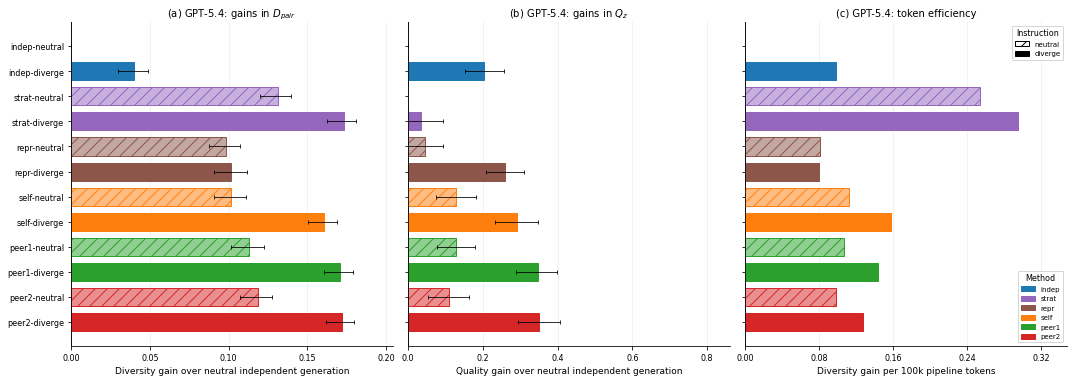

Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure1a_gpt54_dpair_gain_horizontal_ci.pdf
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure1a_gpt54_dpair_gain_horizontal_ci.png


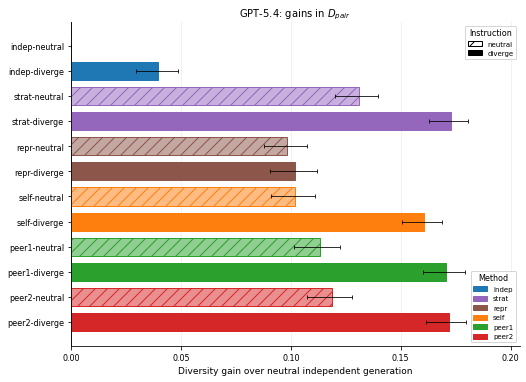

Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure1b_gpt54_quality_gain_horizontal_ci.pdf
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure1b_gpt54_quality_gain_horizontal_ci.png


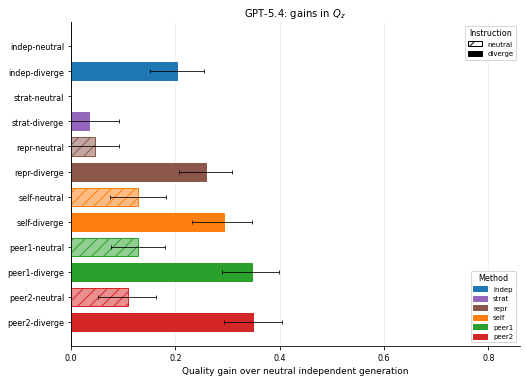

Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure1c_gpt54_token_efficiency_horizontal.pdf
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure1c_gpt54_token_efficiency_horizontal.png


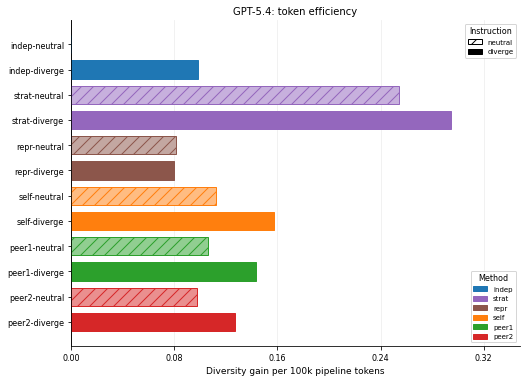

In [50]:
# Cell 45 — Figure 1: GPT-5.4 diversity–quality–efficiency summary

# ================================================================
# Main Figure 1: GPT-5.4 diversity, quality, and token efficiency
# Horizontal bars, method-matched colors, CIs for Dpair/Qz.
# ================================================================

gpt_provider = "openai"

fig1_gpt_fullpool = prepare_provider_fullpool_data(gpt_provider)
fig1_gpt_tokens = prepare_provider_token_eff_data(gpt_provider)

export_figure_data(fig1_gpt_fullpool, "figure1_gpt54_fullpool_data_horizontal_ci")
export_figure_data(fig1_gpt_tokens, "figure1_gpt54_token_efficiency_data_horizontal")

fig, axes = plt.subplots(
    ncols=3,
    figsize=(14.8, 5.2),
    constrained_layout=True,
)

plot_horizontal_bars_with_ci(
    ax=axes[0],
    df=fig1_gpt_fullpool,
    value_col=FIGURE_DPAIR_COL,
    xlabel="Diversity gain over neutral independent generation",
    title="(a) GPT-5.4: gains in $D_{pair}$",
    show_ylabels=True,
    include_ci=True,
    xlim=(0, max(0.19, fig1_gpt_fullpool[FIGURE_DPAIR_COL].max() * 1.18)),
    add_legend=False,
)

plot_horizontal_bars_with_ci(
    ax=axes[1],
    df=fig1_gpt_fullpool,
    value_col=FIGURE_QUALITY_COL,
    xlabel="Quality gain over neutral independent generation",
    title="(b) GPT-5.4: gains in $Q_z$",
    show_ylabels=False,
    include_ci=True,
    xlim=(0, max(0.86, fig1_gpt_fullpool[FIGURE_QUALITY_COL].max() * 1.18)),
    add_legend=False,
)

plot_horizontal_bars_with_ci(
    ax=axes[2],
    df=fig1_gpt_tokens,
    value_col=FIGURE_EFF_COL,
    xlabel="Diversity gain per 100k pipeline tokens",
    title="(c) GPT-5.4: token efficiency",
    show_ylabels=False,
    include_ci=False,
    xlim=(0, max(0.32, fig1_gpt_tokens[FIGURE_EFF_COL].max() * 1.18)),
    add_legend=True,
)

save_figure(fig, "figure1_gpt54_diversity_quality_efficiency_horizontal_ci")
plt.show()

# Panel-specific exports for flexible LaTeX placement.
panel_specs = [
    (
        "figure1a_gpt54_dpair_gain_horizontal_ci",
        fig1_gpt_fullpool,
        FIGURE_DPAIR_COL,
        "GPT-5.4: gains in $D_{pair}$",
        "Diversity gain over neutral independent generation",
        max(0.19, fig1_gpt_fullpool[FIGURE_DPAIR_COL].max() * 1.18),
        True,
    ),
    (
        "figure1b_gpt54_quality_gain_horizontal_ci",
        fig1_gpt_fullpool,
        FIGURE_QUALITY_COL,
        "GPT-5.4: gains in $Q_z$",
        "Quality gain over neutral independent generation",
        max(0.86, fig1_gpt_fullpool[FIGURE_QUALITY_COL].max() * 1.18),
        True,
    ),
    (
        "figure1c_gpt54_token_efficiency_horizontal",
        fig1_gpt_tokens,
        FIGURE_EFF_COL,
        "GPT-5.4: token efficiency",
        "Diversity gain per 100k pipeline tokens",
        max(0.32, fig1_gpt_tokens[FIGURE_EFF_COL].max() * 1.18),
        False,
    ),
]

for stem, data, value_col, title, xlabel, xmax, include_ci in panel_specs:
    fig_panel, ax = plt.subplots(figsize=(7.2, 5.2), constrained_layout=True)

    plot_horizontal_bars_with_ci(
        ax=ax,
        df=data,
        value_col=value_col,
        xlabel=xlabel,
        title=title,
        show_ylabels=True,
        include_ci=include_ci,
        xlim=(0, xmax),
        add_legend=True,
    )

    save_figure(fig_panel, stem)
    plt.show()

Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/rarefaction_design_average_curves_with_ci.csv
Saved figure data: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure_data/figure2_entropy_rarefaction_with_ci_data.csv
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure2_entropy_rarefaction_with_ci.pdf
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure2_entropy_rarefaction_with_ci.png


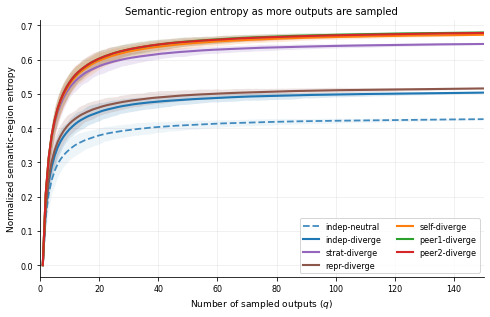

Saved figure data: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure_data/figure2b_dpair_rarefaction_with_ci_data.csv
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure2b_dpair_rarefaction_with_ci.pdf
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure2b_dpair_rarefaction_with_ci.png


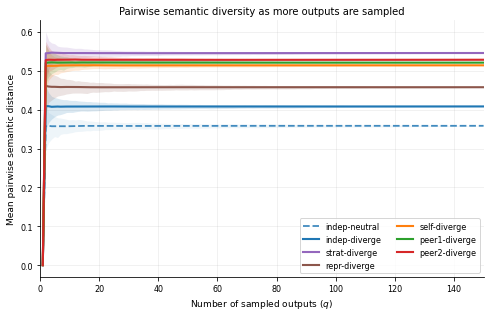

Final q=150 values for rarefaction curves:


,method_key,strategy_key,semantic_pairwise_distance__mean,semantic_pairwise_distance__ci_low,semantic_pairwise_distance__ci_high,region_entropy__mean,region_entropy__ci_low,region_entropy__ci_high
1499,peer1,diverge,0.521013,0.521013,0.521013,0.679631,0.679631,0.679631
1799,peer2,diverge,0.528464,0.528464,0.528464,0.678247,0.678247,0.678247
1199,self,diverge,0.514133,0.514133,0.514133,0.672885,0.672886,0.672886
599,strat,diverge,0.545803,0.545803,0.545803,0.646054,0.646054,0.646054
899,repr,diverge,0.457780,0.457780,0.457780,0.516076,0.516076,0.516076
299,indep,diverge,0.408334,0.408334,0.408334,0.503936,0.503936,0.503936
149,indep,neutral,0.358506,0.358506,0.358506,0.426369,0.426369,0.426369


In [51]:
# Cell 46 — Figure 2: rarefaction curves for entropy and Dpair

# ================================================================
# Main/optional rarefaction figures with method-matched colors and CIs
# ================================================================

rarefaction_design_curve_ci = build_rarefaction_design_curve_ci()

rarefaction_design_curve_ci_path = TABLE_DIR / "rarefaction_design_average_curves_with_ci.csv"
rarefaction_design_curve_ci.to_csv(rarefaction_design_curve_ci_path, index=False)

print("Saved:", rarefaction_design_curve_ci_path)

MAIN_RAREFACTION_CELLS = [
    ("indep", "neutral"),
    ("indep", "diverge"),
    ("strat", "diverge"),
    ("repr", "diverge"),
    ("self", "diverge"),
    ("peer1", "diverge"),
    ("peer2", "diverge"),
]

# Main rarefaction figure currently used in the manuscript: entropy.
plot_rarefaction_curve_with_ci(
    df=rarefaction_design_curve_ci,
    cells=MAIN_RAREFACTION_CELLS,
    metric="region_entropy",
    ylabel="Normalized semantic-region entropy",
    title="Semantic-region entropy as more outputs are sampled",
    stem="figure2_entropy_rarefaction_with_ci",
    figsize=(6.7, 4.3),
    legend_ncol=2,
)

# Companion Dpair rarefaction figure. This is flatter but useful as a diagnostic
# or supplementary figure.
plot_rarefaction_curve_with_ci(
    df=rarefaction_design_curve_ci,
    cells=MAIN_RAREFACTION_CELLS,
    metric="semantic_pairwise_distance",
    ylabel="Mean pairwise semantic distance",
    title="Pairwise semantic diversity as more outputs are sampled",
    stem="figure2b_dpair_rarefaction_with_ci",
    figsize=(6.7, 4.3),
    legend_ncol=2,
)

print("Final q=150 values for rarefaction curves:")
display(
    rarefaction_design_curve_ci[
        rarefaction_design_curve_ci["q"].eq(150)
        & rarefaction_design_curve_ci[["method_key", "strategy_key"]]
        .apply(tuple, axis=1)
        .isin(MAIN_RAREFACTION_CELLS)
    ][
        [
            "method_key",
            "strategy_key",
            "semantic_pairwise_distance__mean",
            "semantic_pairwise_distance__ci_low",
            "semantic_pairwise_distance__ci_high",
            "region_entropy__mean",
            "region_entropy__ci_low",
            "region_entropy__ci_high",
        ]
    ].sort_values("region_entropy__mean", ascending=False)
)

Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/appendix_provider_specific_dpair_quality_gains_horizontal_ci.pdf
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/appendix_provider_specific_dpair_quality_gains_horizontal_ci.png


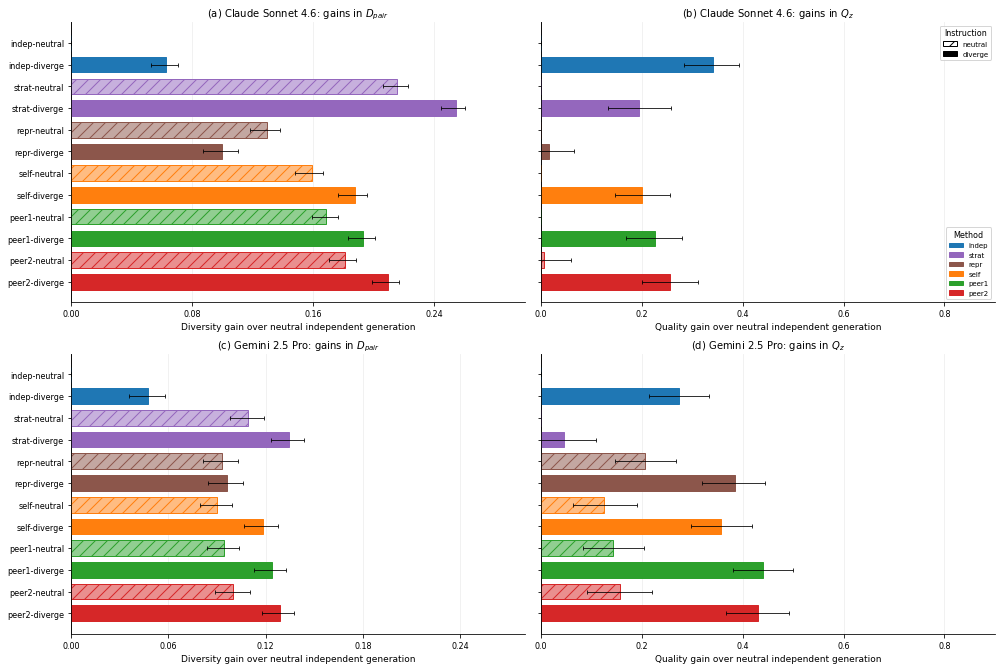

Saved figure data: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure_data/appendix_claude_sonnet46_fullpool_gains_horizontal_ci_data.csv
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/appendix_claude_sonnet46_dpair_gain_horizontal_ci.pdf
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/appendix_claude_sonnet46_dpair_gain_horizontal_ci.png


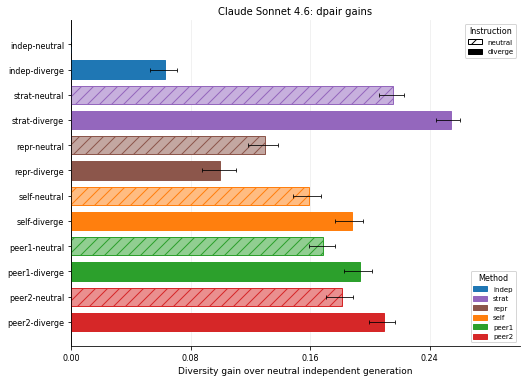

Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/appendix_claude_sonnet46_quality_gain_horizontal_ci.pdf
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/appendix_claude_sonnet46_quality_gain_horizontal_ci.png


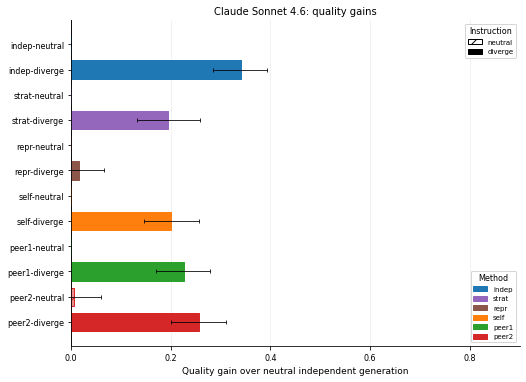

Saved figure data: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure_data/appendix_gemini25pro_fullpool_gains_horizontal_ci_data.csv
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/appendix_gemini25pro_dpair_gain_horizontal_ci.pdf
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/appendix_gemini25pro_dpair_gain_horizontal_ci.png


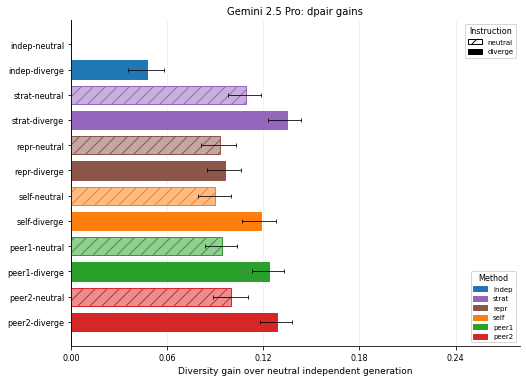

Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/appendix_gemini25pro_quality_gain_horizontal_ci.pdf
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/appendix_gemini25pro_quality_gain_horizontal_ci.png


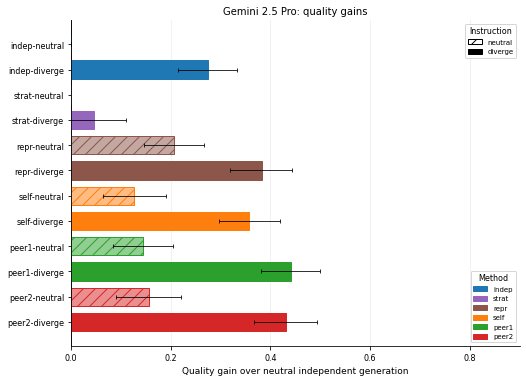

In [52]:
# Cell 47 — Appendix figure: provider-specific Dpair and quality gains

# ================================================================
# Appendix Figure: provider-specific Dpair and quality gains
# Horizontal bars, method-matched colors, CIs.
# ================================================================

appendix_providers = ["anthropic", "gemini"]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(13.8, 9.2),
    constrained_layout=True,
)

for row_idx, provider in enumerate(appendix_providers):
    pdata = prepare_provider_fullpool_data(provider)
    provider_name = PROVIDER_LABEL.get(provider, provider)

    plot_horizontal_bars_with_ci(
        ax=axes[row_idx, 0],
        df=pdata,
        value_col=FIGURE_DPAIR_COL,
        xlabel="Diversity gain over neutral independent generation",
        title=f"({chr(97 + row_idx * 2)}) {provider_name}: gains in $D_{{pair}}$",
        show_ylabels=True,
        include_ci=True,
        xlim=(0, max(0.28, pdata[FIGURE_DPAIR_COL].max() * 1.18)),
        add_legend=False,
    )

    plot_horizontal_bars_with_ci(
        ax=axes[row_idx, 1],
        df=pdata,
        value_col=FIGURE_QUALITY_COL,
        xlabel="Quality gain over neutral independent generation",
        title=f"({chr(98 + row_idx * 2)}) {provider_name}: gains in $Q_z$",
        show_ylabels=False,
        include_ci=True,
        xlim=(0, max(0.90, pdata[FIGURE_QUALITY_COL].max() * 1.18)),
        add_legend=(row_idx == 0),
    )

save_figure(fig, "appendix_provider_specific_dpair_quality_gains_horizontal_ci")
plt.show()

# Individual provider-panel exports.
for provider in appendix_providers:
    pdata = prepare_provider_fullpool_data(provider)
    provider_slug = PROVIDER_TOKEN_FIG_STEM.get(provider, safe_slug(PROVIDER_LABEL.get(provider, provider)))

    export_figure_data(pdata, f"appendix_{provider_slug}_fullpool_gains_horizontal_ci_data")

    for metric_name, value_col, xlabel, xmax_floor in [
        (
            "dpair",
            FIGURE_DPAIR_COL,
            "Diversity gain over neutral independent generation",
            0.28,
        ),
        (
            "quality",
            FIGURE_QUALITY_COL,
            "Quality gain over neutral independent generation",
            0.90,
        ),
    ]:
        fig_panel, ax = plt.subplots(figsize=(7.2, 5.2), constrained_layout=True)

        plot_horizontal_bars_with_ci(
            ax=ax,
            df=pdata,
            value_col=value_col,
            xlabel=xlabel,
            title=f"{PROVIDER_LABEL.get(provider, provider)}: {metric_name} gains",
            show_ylabels=True,
            include_ci=True,
            xlim=(0, max(xmax_floor, pdata[value_col].max() * 1.18)),
            add_legend=True,
        )

        save_figure(fig_panel, f"appendix_{provider_slug}_{metric_name}_gain_horizontal_ci")
        plt.show()

Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/appendix_token_efficiency_all_providers_horizontal.pdf
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/appendix_token_efficiency_all_providers_horizontal.png


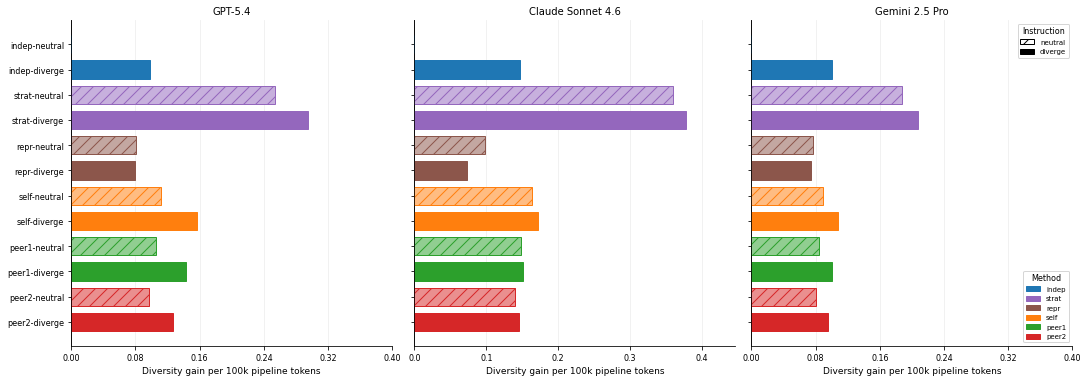

Saved figure data: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure_data/appendix_gpt54_token_efficiency_horizontal_data.csv
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/appendix_gpt54_token_efficiency_horizontal.pdf
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/appendix_gpt54_token_efficiency_horizontal.png


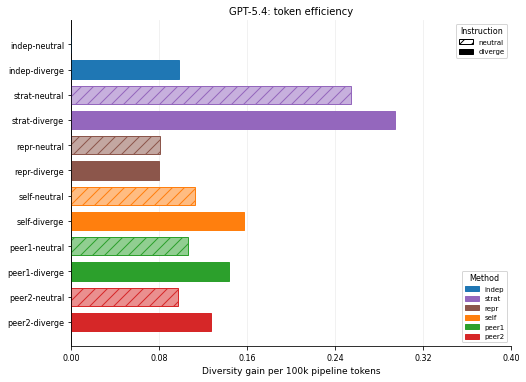

Saved figure data: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure_data/appendix_claude_sonnet46_token_efficiency_horizontal_data.csv
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/appendix_claude_sonnet46_token_efficiency_horizontal.pdf
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/appendix_claude_sonnet46_token_efficiency_horizontal.png


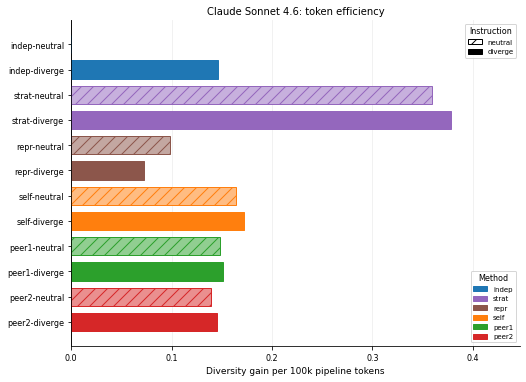

Saved figure data: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure_data/appendix_gemini25pro_token_efficiency_horizontal_data.csv
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/appendix_gemini25pro_token_efficiency_horizontal.pdf
Saved: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/appendix_gemini25pro_token_efficiency_horizontal.png


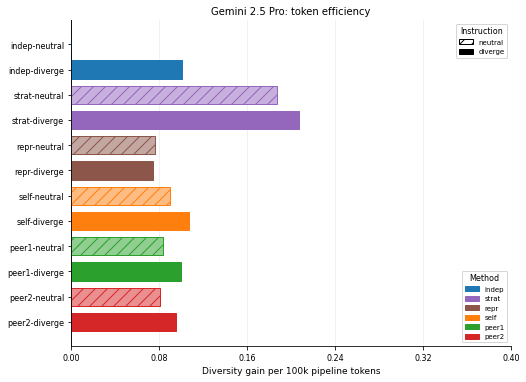

In [53]:
# Cell 48 — Appendix figure: token-efficiency analogues for all providers

# ================================================================
# Appendix Figure: provider-specific token efficiency
# Horizontal bars, method-matched colors.
# ================================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15.0, 5.2),
    constrained_layout=True,
)

for col_idx, provider in enumerate(PROVIDER_ORDER):
    pdata = prepare_provider_token_eff_data(provider)
    provider_name = PROVIDER_LABEL.get(provider, provider)

    plot_horizontal_bars_with_ci(
        ax=axes[col_idx],
        df=pdata,
        value_col=FIGURE_EFF_COL,
        xlabel="Diversity gain per 100k pipeline tokens",
        title=provider_name,
        show_ylabels=(col_idx == 0),
        include_ci=False,
        xlim=(0, max(0.40, pdata[FIGURE_EFF_COL].max() * 1.18)),
        add_legend=(col_idx == 2),
    )

save_figure(fig, "appendix_token_efficiency_all_providers_horizontal")
plt.show()

# Individual token-efficiency panel exports.
for provider in PROVIDER_ORDER:
    pdata = prepare_provider_token_eff_data(provider)
    provider_slug = PROVIDER_TOKEN_FIG_STEM.get(provider, safe_slug(PROVIDER_LABEL.get(provider, provider)))

    export_figure_data(pdata, f"appendix_{provider_slug}_token_efficiency_horizontal_data")

    fig_panel, ax = plt.subplots(figsize=(7.2, 5.2), constrained_layout=True)

    plot_horizontal_bars_with_ci(
        ax=ax,
        df=pdata,
        value_col=FIGURE_EFF_COL,
        xlabel="Diversity gain per 100k pipeline tokens",
        title=f"{PROVIDER_LABEL.get(provider, provider)}: token efficiency",
        show_ylabels=True,
        include_ci=False,
        xlim=(0, max(0.40, pdata[FIGURE_EFF_COL].max() * 1.18)),
        add_legend=True,
    )

    save_figure(fig_panel, f"appendix_{provider_slug}_token_efficiency_horizontal")
    plt.show()

In [54]:
# Cell 49 — Figure manifest

# ================================================================
# Figure manifest
# ================================================================

figure_files = sorted(
    [
        p for p in FIGURE_OUTPUT_DIR.glob("*")
        if p.suffix.lower() in {".pdf", ".png"}
    ]
)

figure_data_files = sorted(FIGURE_DATA_DIR.glob("*.csv"))

figure_manifest = pd.DataFrame(
    [
        {
            "path": str(p),
            "filename": p.name,
            "suffix": p.suffix.lower(),
            "size_kb": p.stat().st_size / 1024,
            "modified_at": dt.datetime.fromtimestamp(p.stat().st_mtime).isoformat(),
        }
        for p in figure_files
    ]
)

figure_data_manifest = pd.DataFrame(
    [
        {
            "path": str(p),
            "filename": p.name,
            "suffix": p.suffix.lower(),
            "size_kb": p.stat().st_size / 1024,
            "modified_at": dt.datetime.fromtimestamp(p.stat().st_mtime).isoformat(),
        }
        for p in figure_data_files
    ]
)

figure_manifest_path = FIGURE_OUTPUT_DIR / "figure_manifest.csv"
figure_data_manifest_path = FIGURE_DATA_DIR / "figure_data_manifest.csv"

figure_manifest.to_csv(figure_manifest_path, index=False)
figure_data_manifest.to_csv(figure_data_manifest_path, index=False)

print("Saved figure manifest:", figure_manifest_path)
print("Saved figure-data manifest:", figure_data_manifest_path)

print("\nFigure files:")
display(figure_manifest)

print("\nFigure data files:")
display(figure_data_manifest)

Saved figure manifest: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure_manifest.csv
Saved figure-data manifest: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/figures/paper_figures/figure_data/figure_data_manifest.csv

Figure files:


,path,filename,suffix,size_kb,modified_at
0,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_claude_sonnet46_dpair_gain_horizontal...,.pdf,16.819336,2026-05-25T10:08:12.012410
1,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_claude_sonnet46_dpair_gain_horizontal...,.png,118.640625,2026-05-25T10:08:12.146724
2,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_claude_sonnet46_quality_gain_horizont...,.pdf,16.957031,2026-05-25T10:08:12.360024
3,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_claude_sonnet46_quality_gain_horizont...,.png,105.096680,2026-05-25T10:08:12.483336
4,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_claude_sonnet46_token_efficiency_hori...,.pdf,16.191406,2026-05-25T10:10:39.875911
5,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_claude_sonnet46_token_efficiency_hori...,.png,111.840820,2026-05-25T10:10:40.002692
6,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_claude_sonnet_4_6_dpair_gain.pdf,.pdf,12.696289,2026-05-25T03:51:02.759011
7,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_claude_sonnet_4_6_dpair_gain.png,.png,115.680664,2026-05-25T03:51:02.858162
8,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_claude_sonnet_4_6_quality_gain.pdf,.pdf,12.916016,2026-05-25T03:51:03.051455
9,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_claude_sonnet_4_6_quality_gain.png,.png,115.566406,2026-05-25T03:51:03.157092



Figure data files:


,path,filename,suffix,size_kb,modified_at
0,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_claude_sonnet46_fullpool_gains_horizo...,.csv,6.317383,2026-05-25T10:08:11.863185
1,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_claude_sonnet46_token_efficiency_hori...,.csv,4.200195,2026-05-25T10:10:39.732637
2,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_claude_sonnet_4_6_fullpool_gains_data...,.csv,6.690430,2026-05-25T03:51:02.628472
3,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_claude_sonnet_4_6_token_efficiency_da...,.csv,3.746094,2026-05-25T03:51:24.174241
4,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_gemini25pro_fullpool_gains_horizontal...,.csv,6.239258,2026-05-25T10:08:12.560349
5,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_gemini25pro_token_efficiency_horizont...,.csv,4.081055,2026-05-25T10:10:40.076985
6,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_gemini_2_5_pro_fullpool_gains_data.csv,.csv,6.611328,2026-05-25T03:51:03.215149
7,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_gemini_2_5_pro_token_efficiency_data.csv,.csv,3.640625,2026-05-25T03:51:24.464004
8,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_gpt54_token_efficiency_horizontal_dat...,.csv,4.026367,2026-05-25T10:10:39.356518
9,/Users/raiyanabdulbaten/Library/CloudStorage/D...,appendix_gpt_5_4_token_efficiency_data.csv,.csv,3.595703,2026-05-25T03:51:23.863683


In [55]:
# Cell 50 — Manuscript table helpers

# ================================================================
# Manuscript table export helpers
# ================================================================

MANUSCRIPT_TABLE_DIR = TABLE_DIR / "manuscript_ready_tables"
MANUSCRIPT_TABLE_DIR.mkdir(parents=True, exist_ok=True)

def latex_escape(x: Any) -> str:
    """
    Minimal LaTeX escaping for table cell text.
    """
    if pd.isna(x):
        return ""

    s = str(x)

    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }

    for old, new in replacements.items():
        s = s.replace(old, new)

    return s


def write_booktabs_table(
    df: pd.DataFrame,
    path: Path,
    caption: Optional[str] = None,
    label: Optional[str] = None,
    column_align: Optional[str] = None,
) -> None:
    """
    Write a simple booktabs LaTeX table.
    """
    path.parent.mkdir(parents=True, exist_ok=True)

    if column_align is None:
        column_align = "l" * len(df.columns)

    lines = []

    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")

    if caption is not None:
        lines.append(rf"\caption{{{caption}}}")

    if label is not None:
        lines.append(rf"\label{{{label}}}")

    lines.append(rf"\begin{{tabular}}{{{column_align}}}")
    lines.append(r"\toprule")

    header = " & ".join(latex_escape(c) for c in df.columns) + r" \\"
    lines.append(header)
    lines.append(r"\midrule")

    for _, row in df.iterrows():
        vals = [latex_escape(row[c]) for c in df.columns]
        lines.append(" & ".join(vals) + r" \\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")

    path.write_text("\n".join(lines), encoding="utf-8")
    print("Saved LaTeX table:", path)


def fmt_ci_cols(
    row: pd.Series,
    base_col: str,
    digits: int = 3,
) -> str:
    return (
        f"{row[base_col]:.{digits}f} "
        f"[{row[f'{base_col}__ci_low']:.{digits}f}, "
        f"{row[f'{base_col}__ci_high']:.{digits}f}]"
    )


def fmt_plain(x: Any, digits: int = 3) -> str:
    if pd.isna(x):
        return ""
    return f"{float(x):.{digits}f}"


def fmt_multiplier(x: Any, digits: int = 1) -> str:
    if pd.isna(x):
        return ""
    return f"{float(x):.{digits}f}"


def add_plot_order_keys(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["_method_key"] = out["method"].map(canonical_method) if "method" in out.columns else ""
    out["_strategy_key"] = out["strategy"].map(canonical_strategy) if "strategy" in out.columns else ""

    method_order = {m: i for i, m in enumerate(METHOD_PLOT_ORDER)}
    strategy_order = {s: i for i, s in enumerate(STRATEGY_PLOT_ORDER)}

    out["_method_order"] = out["_method_key"].map(method_order).fillna(999).astype(int)
    out["_strategy_order"] = out["_strategy_key"].map(strategy_order).fillna(999).astype(int)

    return out


def save_csv_and_tex(
    df: pd.DataFrame,
    stem: str,
    caption: Optional[str] = None,
    label: Optional[str] = None,
    column_align: Optional[str] = None,
) -> tuple[Path, Path]:
    csv_path = MANUSCRIPT_TABLE_DIR / f"{stem}.csv"
    tex_path = MANUSCRIPT_TABLE_DIR / f"{stem}.tex"

    df.to_csv(csv_path, index=False)
    write_booktabs_table(
        df=df,
        path=tex_path,
        caption=caption,
        label=label,
        column_align=column_align,
    )

    print("Saved CSV table:", csv_path)

    return csv_path, tex_path

In [56]:
# Cell 51 — Main full-pool table exports

# ================================================================
# Main-text full-pool tables
# ================================================================

if "lift_by_provider_ci" not in globals():
    lift_by_provider_ci = pd.read_csv(
        TABLE_DIR / "fullpool_divergence_lift_by_provider_with_ci.csv"
    )

if "baseline_by_provider_ci" not in globals():
    baseline_by_provider_ci = pd.read_csv(
        TABLE_DIR / "fullpool_baseline_improvement_by_provider_with_ci.csv"
    )

if "baseline_design_avg_ci" not in globals():
    baseline_design_avg_ci = pd.read_csv(
        TABLE_DIR / "fullpool_baseline_improvement_design_average_with_ci.csv"
    )

if "token_eff_provider_designavg" not in globals():
    token_eff_provider_designavg = pd.read_csv(
        TOKEN_OUTPUT_DIRS["baseline"]
        / "token_efficiency_provider_level_gains_vs_neutral_independent_designavg.csv"
    )

# Table 1-style: effect of diverge under independent generation.
table1_base = (
    lift_by_provider_ci[
        lift_by_provider_ci["method"].eq("one_shot")
    ]
    .copy()
)

table1_tokens = (
    token_eff_provider_designavg[
        token_eff_provider_designavg["method"].eq("one_shot")
        & token_eff_provider_designavg["strategy"].eq("diverge")
    ][
        [
            "provider",
            "token_multiplier_vs_baseline_ratio_of_means",
        ]
    ]
    .copy()
)

table1 = table1_base.merge(
    table1_tokens,
    on="provider",
    how="left",
    validate="one_to_one",
)

table1["Model"] = table1["provider_label"]
table1["Dpair lift"] = table1.apply(
    lambda r: fmt_ci_cols(r, "divergence_lift__semantic_pairwise_distance", digits=3),
    axis=1,
)
table1["Qz lift"] = table1.apply(
    lambda r: fmt_ci_cols(r, "divergence_lift__quality_mean", digits=3),
    axis=1,
)
table1["Rtok"] = table1["token_multiplier_vs_baseline_ratio_of_means"].map(
    lambda x: fmt_multiplier(x, digits=1)
)

table1_out = (
    table1[
        [
            "provider",
            "Model",
            "Dpair lift",
            "Qz lift",
            "Rtok",
        ]
    ]
    .sort_values("provider")
    .drop(columns=["provider"])
    .reset_index(drop=True)
)

save_csv_and_tex(
    df=table1_out,
    stem="main_table_indep_diverge_by_provider",
    caption="Effect of divergent instruction under independent generation.",
    label="tab:indep-diverge",
    column_align="lccc",
)

# Design-average method ranking.
design_rank = add_plot_order_keys(baseline_design_avg_ci).copy()

design_rank = (
    design_rank
    .sort_values("delta_vs_baseline__semantic_pairwise_distance", ascending=False)
    .reset_index(drop=True)
)

design_rank["Method"] = design_rank["_method_key"]
design_rank["Inst."] = design_rank["_strategy_key"].map({"neutral": "N", "diverge": "D"})
design_rank["Dpair gain"] = design_rank.apply(
    lambda r: fmt_ci_cols(r, "delta_vs_baseline__semantic_pairwise_distance", digits=3),
    axis=1,
)
design_rank["Qz gain"] = design_rank.apply(
    lambda r: fmt_ci_cols(r, "delta_vs_baseline__quality_mean", digits=3),
    axis=1,
)
design_rank["Dent gain"] = design_rank.apply(
    lambda r: fmt_ci_cols(r, "delta_vs_baseline__region_entropy", digits=3),
    axis=1,
)

design_rank_out = design_rank[
    [
        "Method",
        "Inst.",
        "Dpair gain",
        "Qz gain",
        "Dent gain",
    ]
].copy()

save_csv_and_tex(
    df=design_rank_out,
    stem="main_table_design_average_method_ranking",
    caption="Design-average gains relative to neutral independent generation.",
    label="tab:design-average-ranking",
    column_align="llccc",
)

display(table1_out)
display(design_rank_out)

Saved LaTeX table: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/manuscript_ready_tables/main_table_indep_diverge_by_provider.tex
Saved CSV table: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/manuscript_ready_tables/main_table_indep_diverge_by_provider.csv
Saved LaTeX table: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/manuscript_ready_tables/main_table_design_average_method_ranking.tex
Saved CSV table: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/manuscript_ready_tables/main_table_design_average_method_ranking.csv


,Model,Dpair lift,Qz lift,Rtok
0,Claude Sonnet 4.6,"0.063 [0.053, 0.071]","0.340 [0.284, 0.392]",1.1
1,Gemini 2.5 Pro,"0.047 [0.036, 0.058]","0.274 [0.215, 0.334]",1.1
2,GPT-5.4,"0.040 [0.030, 0.049]","0.204 [0.151, 0.255]",1.1


,Method,Inst.,Dpair gain,Qz gain,Dent gain
0,strat,D,"0.187 [0.180, 0.191]","0.091 [0.054, 0.126]","0.220 [0.204, 0.229]"
1,peer2,D,"0.170 [0.163, 0.174]","0.346 [0.312, 0.379]","0.252 [0.235, 0.261]"
2,peer1,D,"0.163 [0.156, 0.167]","0.338 [0.306, 0.371]","0.253 [0.236, 0.262]"
3,self,D,"0.156 [0.149, 0.160]","0.284 [0.249, 0.316]","0.247 [0.230, 0.255]"
4,strat,N,"0.152 [0.146, 0.156]","-0.173 [-0.208, -0.138]","0.179 [0.165, 0.190]"
5,peer2,N,"0.133 [0.126, 0.138]","0.090 [0.058, 0.124]","0.251 [0.234, 0.261]"
6,peer1,N,"0.125 [0.119, 0.130]","0.069 [0.037, 0.102]","0.242 [0.225, 0.251]"
7,self,N,"0.117 [0.110, 0.122]","0.060 [0.027, 0.091]","0.231 [0.214, 0.240]"
8,repr,N,"0.107 [0.101, 0.112]","0.051 [0.017, 0.081]","0.120 [0.106, 0.132]"
9,repr,D,"0.099 [0.092, 0.105]","0.219 [0.188, 0.249]","0.090 [0.075, 0.102]"


In [57]:
# Cell 52 — Rarefaction table exports

# ================================================================
# Manuscript-ready rarefaction AUC and first-hit tables
# ================================================================

if "rarefaction_auc_summary" not in globals():
    rarefaction_auc_summary = pd.read_csv(
        TABLE_DIR / "rarefaction_auc_summary_provider_family_distribution.csv"
    )

if "rarefaction_first_hit_summary" not in globals():
    rarefaction_first_hit_summary = pd.read_csv(
        TABLE_DIR / "rarefaction_first_hit_summary_provider_family_distribution.csv"
    )

raref_auc = add_plot_order_keys(rarefaction_auc_summary).copy()
raref_auc = raref_auc.sort_values(["_method_order", "_strategy_order"]).reset_index(drop=True)

raref_auc["Method"] = raref_auc["_method_key"]
raref_auc["Inst."] = raref_auc["_strategy_key"].map({"neutral": "N", "diverge": "D"})
raref_auc["Dpair AUC"] = raref_auc.apply(
    lambda r: (
        f"{r['semantic_pairwise_distance_auc__mean']:.2f} "
        f"[{r['semantic_pairwise_distance_auc__ci_low']:.2f}, "
        f"{r['semantic_pairwise_distance_auc__ci_high']:.2f}]"
    ),
    axis=1,
)
raref_auc["Dent AUC"] = raref_auc.apply(
    lambda r: (
        f"{r['region_entropy_auc__mean']:.2f} "
        f"[{r['region_entropy_auc__ci_low']:.2f}, "
        f"{r['region_entropy_auc__ci_high']:.2f}]"
    ),
    axis=1,
)

raref_auc_out = raref_auc[
    [
        "Method",
        "Inst.",
        "Dpair AUC",
        "Dent AUC",
    ]
].copy()

save_csv_and_tex(
    df=raref_auc_out,
    stem="appendix_table_rarefaction_auc",
    caption="Rarefaction AUC summary.",
    label="tab:rarefaction-auc",
    column_align="llcc",
)

raref_hit = add_plot_order_keys(rarefaction_first_hit_summary).copy()
raref_hit = raref_hit.sort_values(["_method_order", "_strategy_order"]).reset_index(drop=True)

raref_hit["Method"] = raref_hit["_method_key"]
raref_hit["Inst."] = raref_hit["_strategy_key"].map({"neutral": "N", "diverge": "D"})
raref_hit["Dpair target"] = raref_hit.apply(
    lambda r: (
        f"{r['semantic_pairwise_distance_first_hit__mean']:.1f} "
        f"[{r['semantic_pairwise_distance_first_hit__ci_low']:.1f}, "
        f"{r['semantic_pairwise_distance_first_hit__ci_high']:.1f}]"
    ),
    axis=1,
)
raref_hit["Dent target"] = raref_hit.apply(
    lambda r: (
        f"{r['region_entropy_first_hit__mean']:.1f} "
        f"[{r['region_entropy_first_hit__ci_low']:.1f}, "
        f"{r['region_entropy_first_hit__ci_high']:.1f}]"
    ),
    axis=1,
)

raref_hit["Dent missing"] = raref_hit["region_entropy_first_hit__n_missing"].astype(int)

raref_hit_out = raref_hit[
    [
        "Method",
        "Inst.",
        "Dpair target",
        "Dent target",
        "Dent missing",
    ]
].copy()

save_csv_and_tex(
    df=raref_hit_out,
    stem="appendix_table_rarefaction_first_hit",
    caption="First-hit rarefaction summary.",
    label="tab:rarefaction-first-hit",
    column_align="llccc",
)

display(raref_auc_out)
display(raref_hit_out)

Saved LaTeX table: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/manuscript_ready_tables/appendix_table_rarefaction_auc.tex
Saved CSV table: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/manuscript_ready_tables/appendix_table_rarefaction_auc.csv
Saved LaTeX table: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/manuscript_ready_tables/appendix_table_rarefaction_first_hit.tex
Saved CSV table: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/manuscript_ready_tables/appendix_table_rarefaction_first_hit.csv


,Method,Inst.,Dpair AUC,Dent AUC
0,indep,N,"0.36 [0.22, 0.54]","0.40 [0.23, 0.58]"
1,indep,D,"0.41 [0.23, 0.59]","0.47 [0.19, 0.65]"
2,strat,N,"0.51 [0.31, 0.68]","0.57 [0.44, 0.69]"
3,strat,D,"0.54 [0.33, 0.71]","0.61 [0.54, 0.68]"
4,repr,N,"0.46 [0.30, 0.62]","0.52 [0.42, 0.68]"
5,repr,D,"0.45 [0.31, 0.62]","0.49 [0.34, 0.66]"
6,self,N,"0.47 [0.30, 0.63]","0.62 [0.52, 0.73]"
7,self,D,"0.51 [0.32, 0.66]","0.63 [0.50, 0.74]"
8,peer1,N,"0.48 [0.31, 0.64]","0.63 [0.53, 0.73]"
9,peer1,D,"0.52 [0.32, 0.67]","0.64 [0.47, 0.74]"


,Method,Inst.,Dpair target,Dent target,Dent missing
0,indep,N,"11.4 [2.0, 109.0]","73.6 [5.0, 150.0]",0
1,indep,D,"3.6 [2.0, 17.0]","18.0 [3.0, 66.0]",513
2,strat,N,"2.1 [2.0, 3.0]","8.5 [3.0, 24.0]",0
3,strat,D,"2.0 [2.0, 3.0]","7.5 [3.0, 22.0]",0
4,repr,N,"2.4 [2.0, 5.0]","20.0 [3.0, 123.0]",0
5,repr,D,"2.4 [2.0, 5.0]","24.0 [3.0, 111.0]",0
6,self,N,"2.1 [2.0, 3.0]","7.2 [3.0, 18.0]",0
7,self,D,"2.1 [2.0, 3.0]","6.7 [3.0, 15.0]",0
8,peer1,N,"2.1 [2.0, 3.0]","7.1 [3.0, 18.0]",0
9,peer1,D,"2.1 [2.0, 3.0]","6.9 [3.0, 16.0]",0


In [58]:
# Cell 53 — Token table exports

# ================================================================
# Manuscript-ready token-accounting tables
# ================================================================

if "pipeline_cost" not in globals():
    pipeline_cost = pd.read_csv(
        TOKEN_OUTPUT_DIRS["pipeline"]
        / "pipeline_token_cost_by_provider_task_method_strategy.csv"
    )

if "token_eff_provider_designavg" not in globals():
    token_eff_provider_designavg = pd.read_csv(
        TOKEN_OUTPUT_DIRS["baseline"]
        / "token_efficiency_provider_level_gains_vs_neutral_independent_designavg.csv"
    )

# Compact GPT-5.4 token-efficiency table.
gpt_eff = token_eff_provider_designavg[
    token_eff_provider_designavg["provider"].eq("openai")
].copy()

gpt_eff = force_manuscript_order(gpt_eff)

gpt_eff["Method"] = gpt_eff["_method_key"]
gpt_eff["Inst."] = gpt_eff["_strategy_key"].map({"neutral": "N", "diverge": "D"})
gpt_eff["Dpair gain"] = gpt_eff["diversity_gain"].map(lambda x: fmt_plain(x, digits=3))
gpt_eff["Qz gain"] = gpt_eff["quality_gain"].map(lambda x: fmt_plain(x, digits=3))
gpt_eff["Tokens/pool"] = gpt_eff["mean_pipeline_tokens"].map(lambda x: f"{float(x):,.0f}")
gpt_eff["Rtok"] = gpt_eff["token_multiplier_vs_baseline_ratio_of_means"].map(
    lambda x: f"{float(x):.2f}"
)
gpt_eff["Dpair/100k"] = gpt_eff["diversity_gain_per_100k_tokens_ratio_of_means"].map(
    lambda x: fmt_plain(x, digits=3)
)
gpt_eff["Qz/100k"] = gpt_eff["quality_gain_per_100k_tokens_ratio_of_means"].map(
    lambda x: fmt_plain(x, digits=3)
)

gpt_eff_out = gpt_eff[
    [
        "Method",
        "Inst.",
        "Dpair gain",
        "Qz gain",
        "Tokens/pool",
        "Rtok",
        "Dpair/100k",
        "Qz/100k",
    ]
].copy()

save_csv_and_tex(
    df=gpt_eff_out,
    stem="main_table_gpt54_token_efficiency",
    caption="GPT-5.4 full-pipeline token efficiency.",
    label="tab:gpt54-token-efficiency",
    column_align="llcccccc",
)

# Provider-level token-efficiency winners.
winner_rows = []

for provider, g in token_eff_provider_designavg.groupby("provider", observed=True):
    h = g[g["method"].ne("one_shot") | g["strategy"].ne("vanilla")].copy()

    best_div_eff = h.sort_values(
        "diversity_gain_per_100k_tokens_ratio_of_means",
        ascending=False,
    ).iloc[0]

    best_quality_eff = h.sort_values(
        "quality_gain_per_100k_tokens_ratio_of_means",
        ascending=False,
    ).iloc[0]

    winner_rows.append(
        {
            "Model": PROVIDER_LABEL.get(provider, provider),
            "Best Dpair/100k": (
                f"{canonical_method(best_div_eff['method'])}-"
                f"{canonical_strategy(best_div_eff['strategy'])}"
            ),
            "Dpair/100k": fmt_plain(
                best_div_eff["diversity_gain_per_100k_tokens_ratio_of_means"],
                digits=3,
            ),
            "Best Qz/100k": (
                f"{canonical_method(best_quality_eff['method'])}-"
                f"{canonical_strategy(best_quality_eff['strategy'])}"
            ),
            "Qz/100k": fmt_plain(
                best_quality_eff["quality_gain_per_100k_tokens_ratio_of_means"],
                digits=3,
            ),
        }
    )

token_winners_out = pd.DataFrame(winner_rows)

save_csv_and_tex(
    df=token_winners_out,
    stem="appendix_table_token_efficiency_winners_by_provider",
    caption="Most token-efficient configurations by provider.",
    label="tab:token-efficiency-winners",
    column_align="lcccc",
)

display(gpt_eff_out)
display(token_winners_out)

Saved LaTeX table: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/manuscript_ready_tables/main_table_gpt54_token_efficiency.tex
Saved CSV table: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/manuscript_ready_tables/main_table_gpt54_token_efficiency.csv
Saved LaTeX table: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/manuscript_ready_tables/appendix_table_token_efficiency_winners_by_provider.tex
Saved CSV table: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/manuscript_ready_tables/appendix_table_token_efficiency_winners_by_provider.csv


,Method,Inst.,Dpair gain,Qz gain,Tokens/pool,Rtok,Dpair/100k,Qz/100k
0,indep,N,0.000,0.000,"36,517",1.00,0.000,0.000
1,indep,D,0.040,0.204,"40,358",1.11,0.098,0.504
2,strat,N,0.131,-0.258,"51,529",1.41,0.254,-0.501
3,strat,D,0.173,0.035,"58,687",1.61,0.295,0.060
4,repr,N,0.098,0.045,"121,180",3.32,0.081,0.037
5,repr,D,0.102,0.258,"127,780",3.50,0.080,0.202
6,self,N,0.102,0.129,"90,716",2.48,0.112,0.142
7,self,D,0.161,0.292,"102,272",2.80,0.157,0.286
8,peer1,N,0.113,0.128,"106,440",2.91,0.106,0.120
9,peer1,D,0.171,0.346,"119,222",3.26,0.143,0.291


,Model,Best Dpair/100k,Dpair/100k,Best Qz/100k,Qz/100k
0,Claude Sonnet 4.6,strat-diverge,0.379,indep-diverge,0.795
1,Gemini 2.5 Pro,strat-diverge,0.207,indep-diverge,0.586
2,GPT-5.4,strat-diverge,0.295,indep-diverge,0.504


In [59]:
# Cell 54 — Robustness and diagnostic table exports

# ================================================================
# Robustness and diagnostic tables
# ================================================================

if "observed_baseline_design_avg" not in globals():
    observed_baseline_design_avg = pd.read_csv(
        TABLE_DIR / "observed_baseline_improvement_design_average.csv"
    )

robust = add_plot_order_keys(observed_baseline_design_avg).copy()
robust = robust.sort_values(["_method_order", "_strategy_order"]).reset_index(drop=True)

robust["Method"] = robust["_method_key"]
robust["Inst."] = robust["_strategy_key"].map({"neutral": "N", "diverge": "D"})

metric_cols = {
    "Dpair": "delta_vs_baseline__semantic_pairwise_distance",
    "Dnn": "delta_vs_baseline__nearest_neighbor_distance",
    "Dmed": "delta_vs_baseline__medoid_sparseness",
    "Dmst": "delta_vs_baseline__mst_dispersion",
    "Dent": "delta_vs_baseline__region_entropy",
    "Qz": "delta_vs_baseline__quality_mean",
}

for display_col, source_col in metric_cols.items():
    robust[display_col] = robust[source_col].map(lambda x: fmt_plain(x, digits=3))

robust_out = robust[
    [
        "Method",
        "Inst.",
        "Dpair",
        "Dnn",
        "Dmed",
        "Dmst",
        "Dent",
        "Qz",
    ]
].copy()

save_csv_and_tex(
    df=robust_out,
    stem="appendix_table_fullpool_robustness_observed",
    caption="Observed design-average gains across full-pool robustness metrics.",
    label="tab:fullpool-robustness",
    column_align="llcccccc",
)

# Best method per observed robustness metric.
best_metric_rows = []

for display_col, source_col in metric_cols.items():
    h = robust.sort_values(source_col, ascending=False).iloc[0]

    best_metric_rows.append(
        {
            "Metric": display_col,
            "Best configuration": f"{h['_method_key']}-{h['_strategy_key']}",
            "Gain": fmt_plain(h[source_col], digits=3),
        }
    )

best_metric_out = pd.DataFrame(best_metric_rows)

save_csv_and_tex(
    df=best_metric_out,
    stem="appendix_table_best_configuration_by_metric_observed",
    caption="Best observed configuration by full-pool metric.",
    label="tab:best-config-by-metric",
    column_align="lcc",
)

display(robust_out)
display(best_metric_out)

Saved LaTeX table: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/manuscript_ready_tables/appendix_table_fullpool_robustness_observed.tex
Saved CSV table: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/manuscript_ready_tables/appendix_table_fullpool_robustness_observed.csv
Saved LaTeX table: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/manuscript_ready_tables/appendix_table_best_configuration_by_metric_observed.tex
Saved CSV table: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/tables/manuscript_ready_tables/appendix_table_best_configuration_by_metric_observed.csv


,Method,Inst.,Dpair,Dnn,Dmed,Dmst,Dent,Qz
0,indep,N,0.000,0.000,0.000,0.000,0.000,0.000
1,indep,D,0.050,0.024,0.047,0.021,0.078,0.273
2,strat,N,0.152,0.028,0.145,0.035,0.179,-0.173
3,strat,D,0.187,0.058,0.173,0.064,0.220,0.091
4,repr,N,0.107,0.029,0.095,0.045,0.120,0.051
5,repr,D,0.099,0.041,0.083,0.049,0.090,0.219
6,self,N,0.117,0.053,0.106,0.052,0.231,0.060
7,self,D,0.156,0.076,0.146,0.073,0.247,0.284
8,peer1,N,0.125,0.066,0.113,0.064,0.242,0.069
9,peer1,D,0.163,0.084,0.152,0.080,0.253,0.338


,Metric,Best configuration,Gain
0,Dpair,strat-diverge,0.187
1,Dnn,peer2-diverge,0.093
2,Dmed,strat-diverge,0.173
3,Dmst,peer2-diverge,0.087
4,Dent,peer1-diverge,0.253
5,Qz,peer2-diverge,0.346


In [60]:
# Cell 55 — Final reproducibility manifest and audit

# ================================================================
# Final reproducibility audit and artifact manifest
# ================================================================

def file_record(path: Path) -> dict:
    return {
        "path": str(path),
        "exists": path.exists(),
        "size_kb": path.stat().st_size / 1024 if path.exists() else np.nan,
        "modified_at": dt.datetime.fromtimestamp(path.stat().st_mtime).isoformat()
        if path.exists()
        else None,
    }


key_artifacts = {
    "prepared_analysis_rows": TABLE_DIR / "prepared_analysis_rows_outputs_only.pkl",
    "prepared_analysis_rows_with_regions": TABLE_DIR / "prepared_analysis_rows_with_regions.pkl",
    "prepared_quality_rows": TABLE_DIR / "prepared_quality_rows.csv",
    "prepared_quality_cell_values": TABLE_DIR / "prepared_quality_cell_values.csv",
    "observed_cell_metrics": TABLE_DIR / "observed_cell_metrics_diversity_quality.csv",
    "fullpool_baseline_ci": TABLE_DIR / "fullpool_baseline_improvement_design_average_with_ci.csv",
    "fullpool_divergence_ci": TABLE_DIR / "fullpool_divergence_lift_design_average_with_ci.csv",
    "rarefaction_auc": TABLE_DIR / "rarefaction_auc_summary_provider_family_distribution.csv",
    "rarefaction_first_hit": TABLE_DIR / "rarefaction_first_hit_summary_provider_family_distribution.csv",
    "pipeline_tokens": TOKEN_OUTPUT_DIRS["pipeline"] / "pipeline_token_cost_by_provider_task_method_strategy.csv",
    "token_efficiency_provider": TOKEN_OUTPUT_DIRS["baseline"] / "token_efficiency_provider_level_gains_vs_neutral_independent_designavg.csv",
    "figure_manifest": FIGURE_OUTPUT_DIR / "figure_manifest.csv",
    "figure_data_manifest": FIGURE_DATA_DIR / "figure_data_manifest.csv",
}

artifact_manifest = pd.DataFrame(
    [
        {
            "artifact": name,
            **file_record(path),
        }
        for name, path in key_artifacts.items()
    ]
)

missing_artifacts = artifact_manifest[~artifact_manifest["exists"]].copy()

artifact_manifest_path = MANIFEST_DIR / "final_key_artifacts_manifest.csv"
artifact_manifest.to_csv(artifact_manifest_path, index=False)

print("Saved artifact manifest:", artifact_manifest_path)
display(artifact_manifest)

if not missing_artifacts.empty:
    display(missing_artifacts)
    raise RuntimeError("Some key artifacts are missing.")

final_audit = {
    "created_at_utc": now_iso(),
    "random_seed": RANDOM_SEED,
    "n_output_rows": int(len(analysis_rows)) if "analysis_rows" in globals() else None,
    "n_quality_rows": int(len(quality_rows)) if "quality_rows" in globals() else None,
    "n_cell_metrics": int(len(cell_metrics)) if "cell_metrics" in globals() else None,
    "n_fullpool_bootstrap_rows": int(len(bootstrap_cell_metrics)) if "bootstrap_cell_metrics" in globals() else None,
    "n_rarefaction_boot": int(N_RAREFACTION_BOOT) if "N_RAREFACTION_BOOT" in globals() else None,
    "n_fullpool_boot": int(N_BOOT_FULLPOOL) if "N_BOOT_FULLPOOL" in globals() else None,
    "embedding_model": EMBEDDING_MODEL_NAME,
    "primary_diversity_metric": PRIMARY_DIVERSITY_METRIC,
    "primary_quality_metric": PRIMARY_QUALITY_METRIC,
    "quality_note": (
        "Downstream analyses consume quality_mean from prepared_quality_cell_values. "
        "To replace the automatic proxy with LLM-as-a-judge scores, edit build_quality_rows() "
        "to return the same standardized quality_rows schema, then rerun cells from quality aggregation onward."
    ),
    "key_artifacts_manifest": artifact_manifest_path,
    "manuscript_table_dir": MANUSCRIPT_TABLE_DIR,
    "figure_output_dir": FIGURE_OUTPUT_DIR,
}

final_audit_path = MANIFEST_DIR / "final_reproducibility_audit.json"
save_json(final_audit_path, final_audit)

print("Saved final audit:", final_audit_path)
print("Notebook pipeline complete.")

Saved artifact manifest: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/manifests/final_key_artifacts_manifest.csv


,artifact,path,exists,size_kb,modified_at
0,prepared_analysis_rows,/Users/raiyanabdulbaten/Library/CloudStorage/D...,True,137359.873047,2026-05-25T09:26:31.284923
1,prepared_analysis_rows_with_regions,/Users/raiyanabdulbaten/Library/CloudStorage/D...,True,138878.790039,2026-05-25T09:48:08.777538
2,prepared_quality_rows,/Users/raiyanabdulbaten/Library/CloudStorage/D...,True,12842.356445,2026-05-25T09:41:47.872221
3,prepared_quality_cell_values,/Users/raiyanabdulbaten/Library/CloudStorage/D...,True,100.226562,2026-05-25T09:41:47.880555
4,observed_cell_metrics,/Users/raiyanabdulbaten/Library/CloudStorage/D...,True,144.303711,2026-05-25T09:48:27.945422
5,fullpool_baseline_ci,/Users/raiyanabdulbaten/Library/CloudStorage/D...,True,5.593750,2026-05-25T09:52:57.784271
6,fullpool_divergence_ci,/Users/raiyanabdulbaten/Library/CloudStorage/D...,True,3.225586,2026-05-25T09:52:57.787534
7,rarefaction_auc,/Users/raiyanabdulbaten/Library/CloudStorage/D...,True,3.070312,2026-05-25T09:53:55.800578
8,rarefaction_first_hit,/Users/raiyanabdulbaten/Library/CloudStorage/D...,True,2.476562,2026-05-25T09:55:51.472160
9,pipeline_tokens,/Users/raiyanabdulbaten/Library/CloudStorage/D...,True,164.665039,2026-05-25T09:58:18.932729


Saved final audit: /Users/raiyanabdulbaten/Library/CloudStorage/Dropbox/py_virtual_env_dec20/Fares_diverge_llm/final_analysis_clean/manifests/final_reproducibility_audit.json
Notebook pipeline complete.
